**Install and Import CTGAN**

In [103]:
# ============================================================
# CELL 1 — IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.linear_model import (
    LinearRegression,
    LogisticRegression
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    accuracy_score,
    classification_report,
    confusion_matrix
)

from ctgan import CTGAN

# Reproducibility
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [104]:
# ============================================================
# CELL 2 — LOAD FINAL_DS
# ============================================================

FINAL_DS_FILE = "Final_DS.csv"

macro_df = pd.read_csv(
    FINAL_DS_FILE
)

print("Final_DS loaded successfully.")

Final_DS loaded successfully.


In [105]:
# ============================================================
# CELL 3 — INSPECT FINAL_DS COLUMNS
# ============================================================

print("Final_DS columns:")
print("=" * 60)

for i, column in enumerate(macro_df.columns):
    print(f"{i}: {column}")

Final_DS columns:
0: Date
1: Year
2: Month
3: Bank_Rate
4: CPI
5: Unemployment_Rate
6: House_Price_Index
7: GDP_Growth
8: Current_Accounts
9: Savings_Accounts
10: Mortgage_Approvals
11: Consumer_Credit
12: Credit_Card_Lending


In [106]:
# ============================================================
# CELL 4 — INSPECT TIME COLUMNS
# ============================================================

print("Date column:")
print(macro_df["Date"].head(10))

print("\nYear column:")
print(macro_df["Year"].head(10))

print("\nMonth column:")
print(macro_df["Month"].head(10))

Date column:
0    2008-01
1    2008-02
2    2008-03
3    2008-04
4    2008-05
5    2008-06
6    2008-07
7    2008-08
8    2008-09
9    2008-10
Name: Date, dtype: object

Year column:
0    2008
1    2008
2    2008
3    2008
4    2008
5    2008
6    2008
7    2008
8    2008
9    2008
Name: Year, dtype: int64

Month column:
0      January
1     February
2        March
3        April
4          May
5         June
6         July
7       August
8    September
9      October
Name: Month, dtype: object


In [107]:
# ============================================================
# CELL 5 — STANDARDISE MONTHLY DATE
# ============================================================

macro_df["Date"] = pd.to_datetime(
    macro_df["Date"],
    errors="coerce"
)

macro_df["Date"] = (
    macro_df["Date"]
    .dt.to_period("M")
    .dt.to_timestamp("M")
)

print("Date converted to month-end successfully.")

print(
    "Start:",
    macro_df["Date"].min()
)

print(
    "End:",
    macro_df["Date"].max()
)

Date converted to month-end successfully.
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00


In [108]:
# ============================================================
# CELL 6 — VERIFY DATE RANGE
# ============================================================

print(
    f"Start date: {macro_df['Date'].min():%Y-%m}"
)

print(
    f"End date: {macro_df['Date'].max():%Y-%m}"
)

Start date: 2008-01
End date: 2025-12


In [109]:
# ============================================================
# CELL 7 — CHECK DUPLICATE MONTHS
# ============================================================

duplicate_dates = macro_df["Date"].duplicated().sum()

print(
    f"Duplicate monthly dates: {duplicate_dates}"
)

Duplicate monthly dates: 0


In [110]:
# ============================================================
# CELL 8 — SELECT PROJECT VARIABLES
# KEEP ALL VARIABLES REQUIRED BY SYNTHETIC BANK
# ============================================================

project_columns = [
    "Date",
    "Year",
    "Month",

    # Macroeconomic variables
    "Bank_Rate",
    "CPI",
    "Unemployment_Rate",
    "House_Price_Index",
    "GDP_Growth",

    # Banking volume variables
    "Current_Accounts",
    "Savings_Accounts",
    "Mortgage_Approvals",
    "Consumer_Credit",
    "Credit_Card_Lending"
]

missing_columns = [
    col
    for col in project_columns
    if col not in macro_df.columns
]

if missing_columns:
    raise ValueError(
        f"Final_DS is missing: {missing_columns}"
    )

macro_df = macro_df[
    project_columns
].copy()

print("=" * 70)
print("PROJECT VARIABLES SELECTED")
print("=" * 70)

print(
    macro_df.columns.tolist()
)

print(
    "Shape:",
    macro_df.shape
)

PROJECT VARIABLES SELECTED
['Date', 'Year', 'Month', 'Bank_Rate', 'CPI', 'Unemployment_Rate', 'House_Price_Index', 'GDP_Growth', 'Current_Accounts', 'Savings_Accounts', 'Mortgage_Approvals', 'Consumer_Credit', 'Credit_Card_Lending']
Shape: (216, 13)


In [111]:
# ============================================================
# CELL 10 — CHECK DATA TYPES
# ============================================================

print("Data types of selected variables:")
print("=" * 60)

display(
    macro_df.dtypes.to_frame(
        name="Data_Type"
    )
)

Data types of selected variables:


,Data_Type
Date,datetime64[ns]
Year,int64
Month,object
Bank_Rate,float64
CPI,float64
Unemployment_Rate,float64
House_Price_Index,float64
GDP_Growth,float64
Current_Accounts,int64
Savings_Accounts,int64


In [112]:
# ============================================================
# CELL 11 — LOAD ONS AWE DATASET
# ============================================================

ONS_FILE = "emp.csv"

awe_df = pd.read_csv(
    ONS_FILE,
    encoding="cp1252"
)

print("AWE dataset loaded successfully.")
print("Shape:", awe_df.shape)

AWE dataset loaded successfully.
Shape: (216, 2)


In [113]:
# ============================================================
# CELL 12 — INSPECT ONS AWE COLUMNS
# ============================================================

print("ONS AWE columns:")
print("=" * 60)

for i, column in enumerate(awe_df.columns):
    print(f"{i}: {column}")

ONS AWE columns:
0: Title
1: AWE: Whole Economy Level (£): Seasonally Adjusted Regular Pay Excluding Arrears


In [114]:
# ============================================================
# CELL 13 — IDENTIFY ONS SALARY SERIES
# ============================================================

ONS_SALARY_COLUMN = (
    "AWE: Whole Economy Level (£): "
    "Seasonally Adjusted Regular Pay Excluding Arrears"
)

print("ONS salary series:")

print(ONS_SALARY_COLUMN)

ONS salary series:
AWE: Whole Economy Level (£): Seasonally Adjusted Regular Pay Excluding Arrears


In [115]:
# ============================================================
# CELL 14 — INSPECT ONS SALARY DATA
# ============================================================

print("ONS Title and salary values:")
print("=" * 70)

display(
    awe_df[
        [
            "Title",
            ONS_SALARY_COLUMN
        ]
    ].head(20)
)

ONS Title and salary values:


,Title,AWE: Whole Economy Level (£): Seasonally Adjusted Regular Pay Excluding Arrears
0,2008 JAN,398
1,2008 FEB,400
2,2008 MAR,402
3,2008 APR,404
4,2008 MAY,403
5,2008 JUN,404
6,2008 JUL,405
7,2008 AUG,406
8,2008 SEP,407
9,2008 OCT,409


In [116]:
# ============================================================
# CELL 15 — EXTRACT MONTHLY ONS AWE
# ============================================================

START_YEAR = 2008
END_YEAR = 2025

salary_history = awe_df[
    [
        "Title",
        ONS_SALARY_COLUMN
    ]
].copy()


# ------------------------------------------------------------
# EXTRACT YEAR
# ------------------------------------------------------------

salary_history["Year"] = (
    salary_history["Title"]
    .str.extract(r"^(\d{4})", expand=False)
    .astype(int)
)


# ------------------------------------------------------------
# EXTRACT MONTH
# ------------------------------------------------------------

salary_history["Month_Name"] = (
    salary_history["Title"]
    .str.extract(
        r"^\d{4}\s+([A-Za-z]{3})",
        expand=False
    )
)


# ------------------------------------------------------------
# CONVERT AWE TO NUMBER
# ------------------------------------------------------------

salary_history["ONS_AWE"] = pd.to_numeric(
    salary_history[ONS_SALARY_COLUMN],
    errors="coerce"
)


# ------------------------------------------------------------
# KEEP 2008–2025
# ------------------------------------------------------------

salary_history = salary_history[
    salary_history["Year"].between(
        START_YEAR,
        END_YEAR
    )
].copy()


# ------------------------------------------------------------
# MONTH NUMBER
# ------------------------------------------------------------

month_map = {
    "JAN": 1,
    "FEB": 2,
    "MAR": 3,
    "APR": 4,
    "MAY": 5,
    "JUN": 6,
    "JUL": 7,
    "AUG": 8,
    "SEP": 9,
    "OCT": 10,
    "NOV": 11,
    "DEC": 12
}

salary_history["Month"] = (
    salary_history["Month_Name"]
    .str.upper()
    .map(month_map)
)


# ------------------------------------------------------------
# CREATE DATE
# ------------------------------------------------------------

salary_history["Date"] = pd.to_datetime(
    dict(
        year=salary_history["Year"],
        month=salary_history["Month"],
        day=1
    )
)


# ------------------------------------------------------------
# CALCULATE MONTHLY AWE GROWTH
# ------------------------------------------------------------

salary_history["AWE_Growth"] = (
    salary_history["ONS_AWE"].pct_change()
)


# ------------------------------------------------------------
# CALCULATE YEAR-ON-YEAR AWE GROWTH
# ------------------------------------------------------------

salary_history["AWE_YoY_Growth"] = (
    salary_history["ONS_AWE"]
    .pct_change(periods=12)
)


# ------------------------------------------------------------
# KEEP REQUIRED COLUMNS
# ------------------------------------------------------------

salary_history = salary_history[
    [
        "Date",
        "Year",
        "Month",
        "ONS_AWE",
        "AWE_Growth",
        "AWE_YoY_Growth"
    ]
].sort_values(
    "Date"
).reset_index(drop=True)


print("Monthly ONS AWE extracted successfully.")

print("\nShape:")
print(salary_history.shape)

print("\nFirst 5 rows:")
print(salary_history.head())

print("\nLast 5 rows:")
print(salary_history.tail())

Monthly ONS AWE extracted successfully.

Shape:
(216, 6)

First 5 rows:
        Date  Year  Month  ONS_AWE  AWE_Growth  AWE_YoY_Growth
0 2008-01-01  2008      1      398         NaN             NaN
1 2008-02-01  2008      2      400    0.005025             NaN
2 2008-03-01  2008      3      402    0.005000             NaN
3 2008-04-01  2008      4      404    0.004975             NaN
4 2008-05-01  2008      5      403   -0.002475             NaN

Last 5 rows:
          Date  Year  Month  ONS_AWE  AWE_Growth  AWE_YoY_Growth
211 2025-08-01  2025      8      682    0.002941        0.046012
212 2025-09-01  2025      9      685    0.004399        0.045802
213 2025-10-01  2025     10      687    0.002920        0.044073
214 2025-11-01  2025     11      688    0.001456        0.040847
215 2025-12-01  2025     12      690    0.002907        0.037594


In [117]:
# ============================================================
# CELL 16 — VALIDATE ONS AWE PERIOD
# ============================================================

print(
    f"ONS AWE start date: {salary_history['Date'].min():%Y-%m}"
)

print(
    f"ONS AWE end date: {salary_history['Date'].max():%Y-%m}"
)

print(
    f"ONS AWE observations: {len(salary_history)}"
)

ONS AWE start date: 2008-01
ONS AWE end date: 2025-12
ONS AWE observations: 216


In [118]:
# ============================================================
# CELL 17 — CHECK MISSING ONS AWE VALUES
# ============================================================

missing_awe = salary_history["ONS_AWE"].isna().sum()

print(
    f"Missing ONS AWE values: {missing_awe}"
)

Missing ONS AWE values: 0


In [119]:
# ============================================================
# CELL 18 — CHECK DUPLICATE ONS MONTHLY DATES
# ============================================================

duplicate_awe_dates = (
    salary_history["Date"]
    .duplicated()
    .sum()
)

print(
    f"Duplicate ONS monthly dates: {duplicate_awe_dates}"
)

Duplicate ONS monthly dates: 0


In [120]:
# ============================================================
# CELL 19 — LOAD BANK OF ENGLAND DATA
# ============================================================

BOE_FILE = "Bank_of_England_volumes.csv"

boe_df = pd.read_csv(
    BOE_FILE
)

print("Bank of England dataset loaded successfully.")

Bank of England dataset loaded successfully.


In [121]:
# ============================================================
# CELL 20 — INSPECT BANK OF ENGLAND COLUMNS
# ============================================================

print("Bank of England columns:")
print("=" * 60)

for i, column in enumerate(boe_df.columns):
    print(f"{i}: {column}")

Bank of England columns:
0: Date
1: Month_year
2: YEAR
3: Monthly amounts outstanding of monetary financial institutions' sterling net lending  to household sector (in sterling millions) seasonally adjusted  LPMBC44
4: Monthly amounts outstanding of monetary financial institutions' sterling consumer credit lending excluding securitisations to individuals (in sterling millions) seasonally adjusted LPMBC46
5: Monthly amounts outstanding of monetary financial institutions' sterling net credit card lending to individuals (in sterling millions) seasonally adjusted  LPMBC53
6: Monthly amounts outstanding of monetary financial institutions' sterling consumer credit (excluding credit card) excluding securitisations to individuals (in sterling millions) seasonally adjusted  LPMBC54
7: Monthly amounts outstanding of monetary financial institutions' sterling net secured lending to individuals (in sterling millions) seasonally adjusted  LPMBC55
8: Monthly amounts outstanding of monetary financial 

In [122]:
# ============================================================
# CELL 21 — INSPECT BOE DATE VALUES
# ============================================================

print("BoE Date values:")
print("=" * 60)

display(
    boe_df[
        [
            "Date",
            "Month_year",
            "YEAR"
        ]
    ].head(10)
)

BoE Date values:


,Date,Month_year,YEAR
0,31-Dec-08,Dec-08,8
1,30-Nov-08,Nov-08,8
2,31-Oct-08,Oct-08,8
3,30-Sep-08,Sep-08,8
4,31-Aug-08,Aug-08,8
5,31-Jul-08,Jul-08,8
6,30-Jun-08,Jun-08,8
7,31-May-08,May-08,8
8,30-Apr-08,Apr-08,8
9,31-Mar-08,Mar-08,8


In [123]:
# ============================================================
# CELL 22 — CONVERT BOE DATE
# ============================================================

boe_df["Date"] = pd.to_datetime(
    boe_df["Date"],
    format="%d-%b-%y"
)

print("BoE Date converted to datetime successfully.")

BoE Date converted to datetime successfully.


In [124]:
# ============================================================
# CELL 23 — VERIFY BOE DATE RANGE
# ============================================================

print(
    f"BoE start date: {boe_df['Date'].min():%Y-%m}"
)

print(
    f"BoE end date: {boe_df['Date'].max():%Y-%m}"
)

BoE start date: 2008-01
BoE end date: 2025-12


In [125]:
# ============================================================
# CELL 24 — CHECK DUPLICATE BOE MONTHLY DATES
# ============================================================

duplicate_boe_dates = (
    boe_df["Date"]
    .duplicated()
    .sum()
)

print(
    f"Duplicate BoE monthly dates: {duplicate_boe_dates}"
)

Duplicate BoE monthly dates: 0


In [126]:
# ============================================================
# CELL 25 — IDENTIFY BOE SERIES COLUMNS
# ============================================================

boe_codes = [
    "LPMBC44",
    "LPMBC46",
    "LPMBC53",
    "LPMBC54",
    "LPMBC55",
    "LPMZ5G7"
]


for code in boe_codes:

    matching_columns = [
        column
        for column in boe_df.columns
        if code in str(column)
    ]

    print(f"\n{code}:")

    for column in matching_columns:
        print(column)


LPMBC44:
Monthly amounts outstanding of monetary financial institutions' sterling net lending  to household sector (in sterling millions) seasonally adjusted  LPMBC44

LPMBC46:
Monthly amounts outstanding of monetary financial institutions' sterling consumer credit lending excluding securitisations to individuals (in sterling millions) seasonally adjusted LPMBC46

LPMBC53:
Monthly amounts outstanding of monetary financial institutions' sterling net credit card lending to individuals (in sterling millions) seasonally adjusted  LPMBC53

LPMBC54:
Monthly amounts outstanding of monetary financial institutions' sterling consumer credit (excluding credit card) excluding securitisations to individuals (in sterling millions) seasonally adjusted  LPMBC54

LPMBC55:
Monthly amounts outstanding of monetary financial institutions' sterling net secured lending to individuals (in sterling millions) seasonally adjusted  LPMBC55

LPMZ5G7:
Monthly amounts outstanding of monetary financial institutions'

In [127]:
# ============================================================
# CELL 26 — CREATE CLEAN BOE VARIABLE NAMES
# ============================================================

boe_retail_df = boe_df.rename(
    columns={
        next(
            col for col in boe_df.columns
            if "LPMBC44" in str(col)
        ): "Household_Net_Lending",

        next(
            col for col in boe_df.columns
            if "LPMBC46" in str(col)
        ): "Consumer_Credit",

        next(
            col for col in boe_df.columns
            if "LPMBC53" in str(col)
        ): "Credit_Card_Lending",

        next(
            col for col in boe_df.columns
            if "LPMBC54" in str(col)
        ): "Consumer_Credit_Excl_Cards",

        next(
            col for col in boe_df.columns
            if "LPMBC55" in str(col)
        ): "Secured_Lending",

        next(
            col for col in boe_df.columns
            if "LPMZ5G7" in str(col)
        ): "Consumer_Loans_Excl_Cards_Overdrafts"
    }
)

print("BoE variables renamed for analysis.")

BoE variables renamed for analysis.


In [128]:
# ============================================================
# CELL 27 — SELECT CLEAN BOE VARIABLES
# ============================================================

boe_retail_df = boe_retail_df[
    [
        "Date",
        "Household_Net_Lending",
        "Consumer_Credit",
        "Credit_Card_Lending",
        "Consumer_Credit_Excl_Cards",
        "Secured_Lending",
        "Consumer_Loans_Excl_Cards_Overdrafts"
    ]
].copy()

print("Required BoE variables selected successfully.")

Required BoE variables selected successfully.


In [129]:
# ============================================================
# CELL 29 — CHECK BOE DATA TYPES
# ============================================================

print("BoE variable data types:")
print("=" * 60)

display(
    boe_retail_df.dtypes.to_frame(
        name="Data_Type"
    )
)

BoE variable data types:


,Data_Type
Date,datetime64[ns]
Household_Net_Lending,int64
Consumer_Credit,int64
Credit_Card_Lending,int64
Consumer_Credit_Excl_Cards,int64
Secured_Lending,int64
Consumer_Loans_Excl_Cards_Overdrafts,int64


In [130]:
# ============================================================
# CELL 30 — VERIFY BOE DATE RANGE
# ============================================================

print(
    f"BoE start date: {boe_retail_df['Date'].min():%Y-%m}"
)

print(
    f"BoE end date: {boe_retail_df['Date'].max():%Y-%m}"
)

print(
    f"BoE observations: {len(boe_retail_df)}"
)

BoE start date: 2008-01
BoE end date: 2025-12
BoE observations: 216


In [131]:
# ============================================================
# CELL 31 — COMPARE FINAL_DS AND BOE PERIODS
# ============================================================

print("Final_DS period:")
print(
    f"{macro_df['Date'].min():%Y-%m} to "
    f"{macro_df['Date'].max():%Y-%m}"
)

print("\nBoE period:")
print(
    f"{boe_retail_df['Date'].min():%Y-%m} to "
    f"{boe_retail_df['Date'].max():%Y-%m}"
)

Final_DS period:
2008-01 to 2025-12

BoE period:
2008-01 to 2025-12


In [132]:
# ============================================================
# CELL 32 — LOAD FCA SOURCE WORKBOOK
# ============================================================

FCA_FILE = "FCA_DATA.xlsx"

fca_excel = pd.ExcelFile(
    FCA_FILE
)

print("FCA source workbook loaded successfully.")

FCA source workbook loaded successfully.


In [133]:
# ============================================================
# CELL 33 — IDENTIFY FCA WORKBOOK SHEETS
# ============================================================

print("FCA workbook sheets:")
print("=" * 60)

for sheet in fca_excel.sheet_names:
    print("-", sheet)

FCA workbook sheets:
- Intro
- How to read the tables
- Table of contents
- Demographics


In [134]:
# ============================================================
# CELL 34 — LOAD FCA DEMOGRAPHICS
# ============================================================

fca_demographics = pd.read_excel(
    FCA_FILE,
    sheet_name="Demographics",
    header=None
)

print("FCA Demographics sheet loaded successfully.")

FCA Demographics sheet loaded successfully.


In [135]:
# ============================================================
# CELL 35 — INSPECT FCA DEMOGRAPHICS STRUCTURE
# ============================================================

display(
    fca_demographics.iloc[:30, :12]
)

,0,1,2,3,4,5,6,7,8,9,10,11
0,Table 1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,D1. What is your sex? A question about gender ...,NaN,Total,Sex,NaN,Age,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,Male,Female,18-24,25-34,35-44,45-54,55-64,65-74,75+
3,"A rebased version of this table follows, rebas...",NaN,NaN,A1,B1,C1,D1,E1,F1,G1,H1,I1
4,Total,NaN,17950,8828,8826,1173,3173,3038,2842,3046,2912,1766
5,NaN,NaN,17950,8527,9104,1867,3031,3010,2853,2923,2538,1728
6,NaN,NaN,1,1,1,1,1,1,1,1,1,1
7,NaN,NaN,1,0.48,0.52,0.1,0.17,0.17,0.16,0.16,0.14,0.1
8,Male,Unweighted,8828,8828,-,470,1282,1328,1347,1578,1672,1151
9,NaN,Weighted,8527,8527,-,902,1449,1432,1378,1417,1117,833


In [136]:
# ============================================================
# CELL 36 — EXTRACT FCA AGE DISTRIBUTION
# ============================================================

# ------------------------------------------------------------
# AGE GROUPS
# ------------------------------------------------------------

age_categories = (
    fca_demographics.iloc[2, 6:12]
    .tolist()
)


# ------------------------------------------------------------
# FCA COLUMN PERCENTAGES
# ------------------------------------------------------------

age_percentages = (
    fca_demographics.iloc[7, 6:12]
    .astype(float)
    .tolist()
)


# ------------------------------------------------------------
# CREATE AGE DISTRIBUTION
# ------------------------------------------------------------

fca_age_distribution = pd.DataFrame({
    "Age_Group": age_categories,
    "FCA_Proportion": age_percentages
})


print("FCA age distribution extracted successfully.")

FCA age distribution extracted successfully.


In [137]:
# ============================================================
# CELL 37 — VERIFY FCA AGE DISTRIBUTION
# ============================================================

print(
    fca_age_distribution
)

  Age_Group  FCA_Proportion
0     25-34            0.17
1     35-44            0.17
2     45-54            0.16
3     55-64            0.16
4     65-74            0.14
5       75+            0.10


In [138]:
# ============================================================
# CELL 39 — DEFINE FCA AGE BASELINE
# ============================================================

fca_age_baseline = fca_age_distribution.copy()

fca_age_baseline["Source_Year"] = 2024

fca_age_baseline["Source"] = (
    "FCA Financial Lives Survey 2024"
)

print("FCA 2024 age baseline created.")

FCA 2024 age baseline created.


In [139]:
# ============================================================
# CELL 40 — INSPECT FCA PERSONAL INCOME TABLE
# ============================================================

# Table 127 = Total annual personal income
table_127_row = fca_demographics[
    fca_demographics.iloc[:, 0]
    .astype(str)
    .str.strip()
    .eq("Table 127")
].index[0]

print("FCA Table 127 located at row:", table_127_row)

display(
    fca_demographics.iloc[
        table_127_row : table_127_row + 20,
        :15
    ]
)

FCA Table 127 located at row: 6347


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
6347,Table 127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6348,D39_1. What is your total annual personal inco...,NaN,Total,Sex,NaN,Age,NaN,NaN,NaN,NaN,NaN,NaN,Ethnicity,NaN,NaN
6349,NaN,NaN,NaN,Male,Female,18-24,25-34,35-44,45-54,55-64,65-74,75+,White,Black & Black British,Asian & Asian British
6350,"A rebased version of this table follows, rebas...",NaN,NaN,A1,B1,C1,D1,E1,F1,G1,H1,I1,J1,K1,L1
6351,Total,NaN,17950,8828,8826,1173,3173,3038,2842,3046,2912,1766,15644,316,957
6352,NaN,NaN,17950,8527,9104,1867,3031,3010,2853,2923,2538,1728,14721,647,1342
6353,NaN,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1
6354,NaN,NaN,1,0.48,0.52,0.1,0.17,0.17,0.16,0.16,0.14,0.1,0.85,0.04,0.08
6355,"Less than £5,000",Unweighted,790,307,461,234,143,113,102,144,34,20,638,21,66
6356,NaN,Weighted,897,381,490,303,155,114,107,147,44,26,673,43,85


In [140]:
# ============================================================
# CELL 41 — INSPECT FCA PERSONAL INCOME TABLE
# ============================================================

display(
    fca_demographics.iloc[
        table_127_row : table_127_row + 20,
        :15
    ]
)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
6347,Table 127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6348,D39_1. What is your total annual personal inco...,NaN,Total,Sex,NaN,Age,NaN,NaN,NaN,NaN,NaN,NaN,Ethnicity,NaN,NaN
6349,NaN,NaN,NaN,Male,Female,18-24,25-34,35-44,45-54,55-64,65-74,75+,White,Black & Black British,Asian & Asian British
6350,"A rebased version of this table follows, rebas...",NaN,NaN,A1,B1,C1,D1,E1,F1,G1,H1,I1,J1,K1,L1
6351,Total,NaN,17950,8828,8826,1173,3173,3038,2842,3046,2912,1766,15644,316,957
6352,NaN,NaN,17950,8527,9104,1867,3031,3010,2853,2923,2538,1728,14721,647,1342
6353,NaN,NaN,1,1,1,1,1,1,1,1,1,1,1,1,1
6354,NaN,NaN,1,0.48,0.52,0.1,0.17,0.17,0.16,0.16,0.14,0.1,0.85,0.04,0.08
6355,"Less than £5,000",Unweighted,790,307,461,234,143,113,102,144,34,20,638,21,66
6356,NaN,Weighted,897,381,490,303,155,114,107,147,44,26,673,43,85


In [141]:
# ============================================================
# CELL 42 — INSPECT FCA INCOME TABLE
# ============================================================

income_section = fca_demographics.iloc[
    table_127_row : table_127_row + 80,
    0:4
].copy()

display(
    income_section
)


,0,1,2,3
6347,Table 127,NaN,NaN,NaN
6348,D39_1. What is your total annual personal inco...,NaN,Total,Sex
6349,NaN,NaN,NaN,Male
6350,"A rebased version of this table follows, rebas...",NaN,NaN,A1
6351,Total,NaN,17950,8828
...,...,...,...,...
6422,NaN,Col %,0,0
6423,NaN,Row %,1,0.8
6424,NaN,Sigtest,B1 X1 D2 G2 H2 M2 N2,B1
6425,Don't know,Unweighted,516,220


In [142]:
# ============================================================
# CELL 43 — EXTRACT FCA INCOME BANDS
# ============================================================

income_rows = income_section[
    income_section.iloc[:, 1]
    .notna()
].copy()

print("FCA income categories identified:")

display(
    income_rows.iloc[:, :4]
)

FCA income categories identified:


,0,1,2,3
6355,"Less than £5,000",Unweighted,790,307
6356,NaN,Weighted,897,381
6357,NaN,Col %,0.05,0.04
6358,NaN,Row %,1,0.44
6359,NaN,Sigtest,C1 E1 F1 H1 I1 M1 N1 O1 P1 R1 S1 T1 U1 W1 X1 Y...,B1
...,...,...,...,...
6422,NaN,Col %,0,0
6423,NaN,Row %,1,0.8
6424,NaN,Sigtest,B1 X1 D2 G2 H2 M2 N2,B1
6425,Don't know,Unweighted,516,220


In [143]:
# ============================================================
# CELL 44 — EXTRACT FCA INCOME DISTRIBUTION
# ============================================================

# Identify rows containing an income category.
# The following row is "Unweighted", followed by "Weighted"
# and then "Col %".

income_distribution = []

for i in range(len(income_section) - 3):

    category = income_section.iloc[i, 1]
    row_type = income_section.iloc[i, 2]

    if (
        pd.notna(category)
        and row_type == "Unweighted"
    ):

        col_percent_row = income_section.iloc[
            i + 2
        ]

        income_distribution.append({
            "Income_Band": str(category).strip(),
            "FCA_Proportion": pd.to_numeric(
                col_percent_row.iloc[3],
                errors="coerce"
            )
        })


fca_income_distribution = pd.DataFrame(
    income_distribution
)

print("FCA income distribution extracted.")

display(
    fca_income_distribution
)

FCA income distribution extracted.


""


In [144]:
# ============================================================
# CELL 44A — LOCATE FCA INCOME TABLE DIRECTLY
# ============================================================

income_table_matches = fca_demographics[
    fca_demographics.apply(
        lambda row: row.astype(str)
        .str.contains(
            "Less than £5,000",
            case=False,
            na=False
        )
        .any(),
        axis=1
    )
]

print("Rows containing 'Less than £5,000':")
print("=" * 70)

display(
    income_table_matches.iloc[:, :6]
)

Rows containing 'Less than £5,000':


,0,1,2,3,4,5
6355,"Less than £5,000",Unweighted,790,307,461,234
6471,"Less than £5,000",Unweighted,790,307,461,234
6577,"Less than £5,000",Unweighted,377,172,193,93
6693,"Less than £5,000",Unweighted,377,172,193,93


In [145]:
# ============================================================
# CELL 44B — LOCATE TABLE 127 EXACTLY
# ============================================================

table_127_matches = fca_demographics[
    fca_demographics.iloc[:, 0]
    .astype(str)
    .str.strip()
    .eq("Table 127")
]

print("Table 127 row:")
print("=" * 60)

display(
    table_127_matches
)

Table 127 row:


,0,1,2,3,4,5,6,7,8,9,...,98,99,100,101,102,103,104,105,106,107
6347,Table 127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [146]:
# ============================================================
# CELL 45 — INSPECT FCA TABLE 127
# ============================================================

table_127_row = 6347

display(
    fca_demographics.iloc[
        table_127_row : table_127_row + 80,
        :15
    ]
)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
6347,Table 127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6348,D39_1. What is your total annual personal inco...,NaN,Total,Sex,NaN,Age,NaN,NaN,NaN,NaN,NaN,NaN,Ethnicity,NaN,NaN
6349,NaN,NaN,NaN,Male,Female,18-24,25-34,35-44,45-54,55-64,65-74,75+,White,Black & Black British,Asian & Asian British
6350,"A rebased version of this table follows, rebas...",NaN,NaN,A1,B1,C1,D1,E1,F1,G1,H1,I1,J1,K1,L1
6351,Total,NaN,17950,8828,8826,1173,3173,3038,2842,3046,2912,1766,15644,316,957
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6422,NaN,Col %,0,0,0,-,0,0,0,0,0,-,0,-,0
6423,NaN,Row %,1,0.8,0.2,-,0.23,0.13,0.28,0.16,0.19,-,0.96,-,0.04
6424,NaN,Sigtest,B1 X1 D2 G2 H2 M2 N2,B1,A1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6425,Don't know,Unweighted,516,220,282,136,120,64,67,58,25,46,382,23,52


In [147]:
# ============================================================
# CELL 46 — IDENTIFY FCA TABLE 127 INCOME BANDS
# ============================================================

# First Table 127 income block
income_block = fca_demographics.iloc[
    6351:6427,
    0:4
].copy()

income_band_rows = income_block[
    (
        income_block.iloc[:, 1]
        .astype(str)
        .str.strip()
        .eq("Unweighted")
    )
]

print("FCA Table 127 income-band rows:")
print("=" * 60)

display(
    income_band_rows.iloc[:, :4]
)

FCA Table 127 income-band rows:


,0,1,2,3
6355,"Less than £5,000",Unweighted,790,307
6360,"£5,000 to £9,999",Unweighted,926,318
6365,"£10,000 to £14,999",Unweighted,1427,497
6370,"£15,000 to £19,999",Unweighted,1593,640
6375,"£20,000 to £29,999",Unweighted,3008,1406
6380,"£30,000 to £39,999",Unweighted,2098,1132
6385,"£40,000 to £49,999",Unweighted,1395,836
6390,"£50,000 to £59,999",Unweighted,836,523
6395,"£60,000 to £69,999",Unweighted,512,319
6400,"£70,000 to £99,999",Unweighted,752,537


In [148]:
# ============================================================
# CELL 47 — EXTRACT FCA WEIGHTED INCOME DISTRIBUTION
# ============================================================

income_rows = []

for row in income_band_rows.index:

    income_band = fca_demographics.loc[row, 0]

    # Weighted row is 1 row below Unweighted
    weighted_value = pd.to_numeric(
        fca_demographics.loc[row + 1, 3],
        errors="coerce"
    )

    # Col % row is 2 rows below Unweighted
    col_percentage = pd.to_numeric(
        fca_demographics.loc[row + 2, 3],
        errors="coerce"
    )

    if income_band != "Don't know":

        income_rows.append({
            "Income_Band": income_band,
            "FCA_Weighted": weighted_value,
            "FCA_Proportion": col_percentage
        })


fca_income_distribution = pd.DataFrame(
    income_rows
)

print("FCA income distribution extracted successfully.")

display(
    fca_income_distribution
)

FCA income distribution extracted successfully.


,Income_Band,FCA_Weighted,FCA_Proportion
0,"Less than £5,000",381,0.04
1,"£5,000 to £9,999",384,0.05
2,"£10,000 to £14,999",485,0.06
3,"£15,000 to £19,999",684,0.08
4,"£20,000 to £29,999",1421,0.17
5,"£30,000 to £39,999",1040,0.12
6,"£40,000 to £49,999",719,0.08
7,"£50,000 to £59,999",445,0.05
8,"£60,000 to £69,999",263,0.03
9,"£70,000 to £99,999",447,0.05


In [149]:
# ============================================================
# CELL 48 — NORMALIZE FCA INCOME DISTRIBUTION
# ============================================================

income_total = (
    fca_income_distribution["FCA_Proportion"].sum()
)

fca_income_distribution["Sampling_Probability"] = (
    fca_income_distribution["FCA_Proportion"]
    / income_total
)

print(
    "Original proportion total:",
    round(income_total, 4)
)

print(
    "Normalized probability total:",
    round(
        fca_income_distribution[
            "Sampling_Probability"
        ].sum(),
        4
    )
)

display(
    fca_income_distribution
)

Original proportion total: 0.8
Normalized probability total: 1.0


,Income_Band,FCA_Weighted,FCA_Proportion,Sampling_Probability
0,"Less than £5,000",381,0.04,0.0500
1,"£5,000 to £9,999",384,0.05,0.0625
2,"£10,000 to £14,999",485,0.06,0.0750
3,"£15,000 to £19,999",684,0.08,0.1000
4,"£20,000 to £29,999",1421,0.17,0.2125
5,"£30,000 to £39,999",1040,0.12,0.1500
6,"£40,000 to £49,999",719,0.08,0.1000
7,"£50,000 to £59,999",445,0.05,0.0625
8,"£60,000 to £69,999",263,0.03,0.0375
9,"£70,000 to £99,999",447,0.05,0.0625


In [150]:
# ============================================================
# CELL 49 — CHECK FCA INCOME DISTRIBUTION
# ============================================================

print("Number of income bands:", len(fca_income_distribution))

print(
    "Duplicate income bands:",
    fca_income_distribution["Income_Band"].duplicated().sum()
)

print(
    "Sampling probability total:",
    round(
        fca_income_distribution["Sampling_Probability"].sum(),
        4
    )
)

Number of income bands: 14
Duplicate income bands: 0
Sampling probability total: 1.0


In [151]:
# ============================================================
# CELL 50 — CREATE FCA INCOME BASELINE
# ============================================================

fca_income_baseline = fca_income_distribution[
    [
        "Income_Band",
        "FCA_Weighted",
        "FCA_Proportion",
        "Sampling_Probability"
    ]
].copy()

fca_income_baseline["Source_Year"] = 2024

fca_income_baseline["Source"] = (
    "FCA Financial Lives Survey 2024"
)

print("FCA income baseline created successfully.")

display(
    fca_income_baseline
)

FCA income baseline created successfully.


,Income_Band,FCA_Weighted,FCA_Proportion,Sampling_Probability,Source_Year,Source
0,"Less than £5,000",381,0.04,0.0500,2024,FCA Financial Lives Survey 2024
1,"£5,000 to £9,999",384,0.05,0.0625,2024,FCA Financial Lives Survey 2024
2,"£10,000 to £14,999",485,0.06,0.0750,2024,FCA Financial Lives Survey 2024
3,"£15,000 to £19,999",684,0.08,0.1000,2024,FCA Financial Lives Survey 2024
4,"£20,000 to £29,999",1421,0.17,0.2125,2024,FCA Financial Lives Survey 2024
5,"£30,000 to £39,999",1040,0.12,0.1500,2024,FCA Financial Lives Survey 2024
6,"£40,000 to £49,999",719,0.08,0.1000,2024,FCA Financial Lives Survey 2024
7,"£50,000 to £59,999",445,0.05,0.0625,2024,FCA Financial Lives Survey 2024
8,"£60,000 to £69,999",263,0.03,0.0375,2024,FCA Financial Lives Survey 2024
9,"£70,000 to £99,999",447,0.05,0.0625,2024,FCA Financial Lives Survey 2024


In [152]:
# ============================================================
# CELL 52 — CALCULATE ONS AWE ADJUSTMENT FACTOR
# ============================================================

awe_df["AWE_Adjustment_Factor"] = (
    awe_df[ONS_SALARY_COLUMN]
    / awe_df[ONS_SALARY_COLUMN].iloc[-1]
)

print("AWE adjustment factor calculated.")

display(
    awe_df[
        [
            "Title",
            ONS_SALARY_COLUMN,
            "AWE_Adjustment_Factor"
        ]
    ].head(12)
)

AWE adjustment factor calculated.


,Title,AWE: Whole Economy Level (£): Seasonally Adjusted Regular Pay Excluding Arrears,AWE_Adjustment_Factor
0,2008 JAN,398,0.576812
1,2008 FEB,400,0.579710
2,2008 MAR,402,0.582609
3,2008 APR,404,0.585507
4,2008 MAY,403,0.584058
5,2008 JUN,404,0.585507
6,2008 JUL,405,0.586957
7,2008 AUG,406,0.588406
8,2008 SEP,407,0.589855
9,2008 OCT,409,0.592754


In [153]:
# ============================================================
# CELL 53 — PREPARE HISTORICAL AWE ADJUSTMENT
# ============================================================

awe_income_adjustment = awe_df[
    [
        "Title",
        "AWE_Adjustment_Factor"
    ]
].copy()

print("Historical AWE adjustment prepared.")

display(
    awe_income_adjustment.head(12)
)

Historical AWE adjustment prepared.


,Title,AWE_Adjustment_Factor
0,2008 JAN,0.576812
1,2008 FEB,0.579710
2,2008 MAR,0.582609
3,2008 APR,0.585507
4,2008 MAY,0.584058
5,2008 JUN,0.585507
6,2008 JUL,0.586957
7,2008 AUG,0.588406
8,2008 SEP,0.589855
9,2008 OCT,0.592754


In [154]:
# ============================================================
# CELL 54 — CREATE REPRESENTATIVE FCA INCOME
# ============================================================

def income_band_to_value(band):

    band = str(band).strip()

    if band == "Less than £5,000":
        return 2500

    elif band == "£1,000,000 or more":
        return 1000000

    else:
        # Remove £ and commas
        values = (
            band.replace("£", "")
                .replace(",", "")
        )

        # Split the range
        lower, upper = values.split(" to ")

        lower = float(lower)
        upper = float(upper)

        return (lower + upper) / 2


fca_income_baseline["Representative_Income"] = (
    fca_income_baseline["Income_Band"]
    .apply(income_band_to_value)
)



In [155]:
# ============================================================
# CELL 55 — PREPARE FCA INCOME FOR SYNTHETIC GENERATION
# ============================================================

synthetic_income_distribution = fca_income_baseline[
    [
        "Income_Band",
        "Representative_Income",
        "Sampling_Probability"
    ]
].copy()

print("Synthetic income distribution prepared.")

display(
    synthetic_income_distribution
)

Synthetic income distribution prepared.


,Income_Band,Representative_Income,Sampling_Probability
0,"Less than £5,000",2500.0,0.0500
1,"£5,000 to £9,999",7499.5,0.0625
2,"£10,000 to £14,999",12499.5,0.0750
3,"£15,000 to £19,999",17499.5,0.1000
4,"£20,000 to £29,999",24999.5,0.2125
5,"£30,000 to £39,999",34999.5,0.1500
6,"£40,000 to £49,999",44999.5,0.1000
7,"£50,000 to £59,999",54999.5,0.0625
8,"£60,000 to £69,999",64999.5,0.0375
9,"£70,000 to £99,999",84999.5,0.0625


In [156]:
# ============================================================
# CELL 56 — GENERATE 10,000 BASELINE CUSTOMERS
# ============================================================

N_CUSTOMERS = 10_000
np.random.seed(42)

bands = synthetic_income_distribution.copy()

# Convert FCA income band text into numeric bounds.
def income_bounds(band):
    band = str(band).strip()
    if band == "Less than £5,000":
        return 500, 5000
    if band == "£1,000,000 or more":
        return 1_000_000, 1_500_000
    text = band.replace("£", "").replace(",", "")
    if " to " in text:
        low, high = text.split(" to ")
        return float(low), float(high)
    return np.nan, np.nan

bounds = bands["Income_Band"].apply(income_bounds)
bands["Low"] = [x[0] for x in bounds]
bands["High"] = [x[1] for x in bounds]

selected = np.random.choice(
    bands["Income_Band"],
    size=N_CUSTOMERS,
    p=bands["Sampling_Probability"]
)

lookup = bands.set_index("Income_Band")

incomes = []
for band in selected:
    low = lookup.loc[band, "Low"]
    high = lookup.loc[band, "High"]
    # Continuous draw inside the FCA band; not a band midpoint.
    if low <= 0:
        low = 500
    incomes.append(
        np.exp(np.random.uniform(np.log(low), np.log(high)))
    )

synthetic_income = pd.DataFrame({
    "Customer_ID": np.arange(1, N_CUSTOMERS + 1),
    "Income_Band": selected,
    "Annual_Income_2024": np.round(incomes, 2)
})

print("Customers:", len(synthetic_income))
display(synthetic_income.head())

Customers: 10000


,Customer_ID,Income_Band,Annual_Income_2024
0,1,"£20,000 to £29,999",23271.24
1,2,"£150,000 to £249,999",177806.16
2,3,"£40,000 to £49,999",41603.47
3,4,"£30,000 to £39,999",35726.12
4,5,"£10,000 to £14,999",12131.53


In [157]:
# ============================================================
# CELL 57 — VALIDATE SYNTHETIC INCOME DISTRIBUTION
# ============================================================

synthetic_income_check = (
    synthetic_income["Income_Band"]
    .value_counts(normalize=True)
    .rename("Synthetic_Proportion")
    .reset_index()
)

synthetic_income_check.columns = [
    "Income_Band",
    "Synthetic_Proportion"
]

# Add FCA target probabilities
synthetic_income_check = synthetic_income_check.merge(
    synthetic_income_distribution[
        [
            "Income_Band",
            "Sampling_Probability"
        ]
    ],
    on="Income_Band",
    how="right"
)

synthetic_income_check = synthetic_income_check.fillna(
    {"Synthetic_Proportion": 0}
)

display(
    synthetic_income_check.sort_values(
        "Income_Band"
    )
)

,Income_Band,Synthetic_Proportion,Sampling_Probability
0,"Less than £5,000",0.0493,0.0500
13,"£1,000,000 or more",0.0000,0.0000
2,"£10,000 to £14,999",0.0765,0.0750
10,"£100,000 to £149,999",0.0371,0.0375
3,"£15,000 to £19,999",0.1022,0.1000
11,"£150,000 to £249,999",0.0249,0.0250
4,"£20,000 to £29,999",0.2137,0.2125
12,"£250,000 to £999,999",0.0225,0.0250
5,"£30,000 to £39,999",0.1527,0.1500
6,"£40,000 to £49,999",0.0984,0.1000


In [158]:
# ============================================================
# CELL 58 — SYNTHETIC INCOME SUMMARY
# ============================================================

income_summary = synthetic_income[
    "Annual_Income_2024"
].describe()

print("Synthetic customer income summary:")
print("=" * 60)

display(income_summary)

Synthetic customer income summary:


count     10000.000000
mean      51098.472606
std       91540.359995
min         506.480000
25%       17603.740000
50%       29596.035000
75%       49107.387500
max      991712.630000
Name: Annual_Income_2024, dtype: float64

In [159]:
# ============================================================
# CELL 60 — GENERATE AGE FROM THE ACTUAL FCA DISTRIBUTION
# ============================================================

np.random.seed(42)

age_table = fca_age_distribution.copy()
age_table["FCA_Proportion"] = pd.to_numeric(
    age_table["FCA_Proportion"], errors="coerce"
)
age_table = age_table.dropna(subset=["FCA_Proportion"]).copy()
age_table["Probability"] = (
    age_table["FCA_Proportion"] /
    age_table["FCA_Proportion"].sum()
)

selected_age_band = np.random.choice(
    age_table["Age_Group"],
    size=N_CUSTOMERS,
    p=age_table["Probability"]
)

def generate_age(band):
    band = str(band).strip()
    if "-" in band:
        low, high = band.split("-")
        return np.random.randint(int(low), int(high) + 1)
    if "+" in band:
        return np.random.randint(int(band.replace("+", "")), 91)
    return np.nan

synthetic_income["Age_2024"] = [generate_age(x) for x in selected_age_band]
synthetic_income["Birth_Year"] = 2024 - synthetic_income["Age_2024"]

print("FCA age proportions used:")
display(age_table[["Age_Group", "Probability"]])

FCA age proportions used:


,Age_Group,Probability
0,25-34,0.188889
1,35-44,0.188889
2,45-54,0.177778
3,55-64,0.177778
4,65-74,0.155556
5,75+,0.111111


In [160]:
# ============================================================
# CELL 61 — HISTORICAL AGE CALCULATION
# ============================================================

def calculate_age(birth_year, year):
    return year - birth_year


# Example: check age progression for first 5 customers
age_check = synthetic_income[
    [
        "Customer_ID",
        "Birth_Year"
    ]
].head(5).copy()

for year in [2008, 2015, 2020, 2024, 2025]:
    age_check[f"Age_{year}"] = (
        year - age_check["Birth_Year"]
    )

display(age_check)

,Customer_ID,Birth_Year,Age_2008,Age_2015,Age_2020,Age_2024,Age_2025
0,1,1983,25,32,37,41,42
1,2,1934,74,81,86,90,91
2,3,1966,42,49,54,58,59
3,4,1968,40,47,52,56,57
4,5,1995,13,20,25,29,30


In [161]:
print(synthetic_income.columns.tolist())

['Customer_ID', 'Income_Band', 'Annual_Income_2024', 'Age_2024', 'Birth_Year']


In [162]:
# ============================================================
# CREATE HOUSING STATUS FOR SYNTHETIC CUSTOMERS
# ============================================================

np.random.seed(42)

# ------------------------------------------------------------
# AGE + INCOME BASED HOUSING PROBABILITY
# ------------------------------------------------------------

age = synthetic_income["Age_2024"]
income = synthetic_income["Annual_Income_2024"]

# Start with reasonable housing probabilities
# and make them dependent on age/income.

housing_score = (
    0.60 * (age - age.mean()) / age.std()
    + 0.40 * (
        np.log1p(income) -
        np.log1p(income).mean()
    ) / np.log1p(income).std()
)

# Convert score to ranking
housing_rank = pd.Series(
    housing_score,
    index=synthetic_income.index
).rank(pct=True)

# ------------------------------------------------------------
# ASSIGN HOUSING STATUS
# ------------------------------------------------------------

synthetic_income["Housing_Status"] = np.select(
    [
        housing_rank < 0.35,
        housing_rank < 0.70
    ],
    [
        "Rent",
        "Mortgage"
    ],
    default="Own"
)

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("=" * 70)
print("HOUSING STATUS CREATED")
print("=" * 70)

print(
    synthetic_income[
        "Housing_Status"
    ].value_counts()
)

print("\nPercentages:")

print(
    (
        synthetic_income[
            "Housing_Status"
        ]
        .value_counts(normalize=True)
        * 100
    ).round(2)
)

print("\nMissing Housing_Status:")

print(
    synthetic_income[
        "Housing_Status"
    ].isna().sum()
)

HOUSING STATUS CREATED
Housing_Status
Mortgage    3500
Rent        3499
Own         3001
Name: count, dtype: int64

Percentages:
Housing_Status
Mortgage    35.00
Rent        34.99
Own         30.01
Name: proportion, dtype: float64

Missing Housing_Status:
0


In [163]:
# ============================================================
# CELL 61 — FCA CONDITIONAL PRODUCT OWNERSHIP
# AGE + INCOME BASED
# ============================================================

import numpy as np
import pandas as pd

np.random.seed(42)


# ============================================================
# 1. CHECK REQUIRED INPUTS
# ============================================================

required_columns = [
    "Customer_ID",
    "Age_2024",
    "Annual_Income_2024",
    "Housing_Status"
]

missing_columns = [
    col
    for col in required_columns
    if col not in synthetic_income.columns
]

if missing_columns:
    raise ValueError(
        f"Missing columns in synthetic_income: {missing_columns}"
    )


# ============================================================
# 2. PREPARE AGE AND INCOME
# ============================================================

age = pd.to_numeric(
    synthetic_income["Age_2024"],
    errors="coerce"
)

income = pd.to_numeric(
    synthetic_income["Annual_Income_2024"],
    errors="coerce"
)

if age.isna().any():
    raise ValueError("Age_2024 contains missing values.")

if income.isna().any():
    raise ValueError(
        "Annual_Income_2024 contains missing values."
    )


# Log income
log_income = np.log1p(
    income.clip(lower=0)
)

# Standardised income
income_z = (
    log_income - log_income.mean()
) / log_income.std()

# Standardised age
age_z = (
    age - age.mean()
) / age.std()


# ============================================================
# 3. FCA OVERALL TARGETS
# ============================================================

TARGET_CURRENT = 0.97
TARGET_SAVINGS = 0.90
TARGET_CREDIT_CARD = 0.65
TARGET_PERSONAL_LOAN = 0.14
TARGET_MORTGAGE = 0.29


# ============================================================
# 4. FUNCTION TO ASSIGN EXACT OVERALL TARGET
# ============================================================

def assign_by_propensity(score, target, random_seed=42):

    n = len(score)

    target_n = round(
        n * target
    )

    rng = np.random.default_rng(
        random_seed
    )

    score = np.asarray(score)

    noisy_score = (
        score
        +
        rng.normal(
            0,
            0.000001,
            size=n
        )
    )

    ranking = np.argsort(
        noisy_score
    )[::-1]

    result = np.zeros(
        n,
        dtype=int
    )

    result[
        ranking[:target_n]
    ] = 1

    return result


# ============================================================
# 5. CURRENT ACCOUNT
# ============================================================

current_score = (
    0.15 * income_z
    + 0.05 * age_z
)

synthetic_income[
    "Current_Account_Probability"
] = current_score

synthetic_income[
    "Has_Current_Account"
] = assign_by_propensity(
    current_score,
    TARGET_CURRENT,
    random_seed=42
)


# ============================================================
# 6. SAVINGS ACCOUNT
# ============================================================

# Age-specific savings ownership assumptions.
#
# These are NOT the age population proportions from Cell 60.
# They represent the probability/propensity of having savings.

SAVINGS_AGE_PROPENSITY = {
    "25-34": 0.86,
    "35-44": 0.87,
    "45-54": 0.89,
    "55-64": 0.93,
    "65-74": 0.95,
    "75+": 0.97
}


def get_savings_age_propensity(age):

    if age <= 34:
        return SAVINGS_AGE_PROPENSITY["25-34"]

    elif age <= 44:
        return SAVINGS_AGE_PROPENSITY["35-44"]

    elif age <= 54:
        return SAVINGS_AGE_PROPENSITY["45-54"]

    elif age <= 64:
        return SAVINGS_AGE_PROPENSITY["55-64"]

    elif age <= 74:
        return SAVINGS_AGE_PROPENSITY["65-74"]

    else:
        return SAVINGS_AGE_PROPENSITY["75+"]


synthetic_income[
    "Savings_Age_Propensity"
] = (
    synthetic_income[
        "Age_2024"
    ]
    .apply(
        get_savings_age_propensity
    )
)


# ------------------------------------------------------------
# Income effect
# ------------------------------------------------------------

# Higher income increases savings propensity,
# but income is kept as a secondary factor.

savings_score = (
    0.70
    * synthetic_income[
        "Savings_Age_Propensity"
    ]
    +
    0.30
    * (
        (
            income_z
            - income_z.min()
        )
        /
        (
            income_z.max()
            - income_z.min()
        )
    )
)


synthetic_income[
    "Savings_Probability"
] = savings_score


# ------------------------------------------------------------
# IMPORTANT
#
# Do NOT globally select the top 90%.
#
# Instead, assign savings separately within each
# age group. This prevents:
#
# 25-34  -> 48%
# older groups -> 100%
#
# ------------------------------------------------------------

synthetic_income[
    "Has_Savings"
] = 0


age_groups = [
    (25, 34),
    (35, 44),
    (45, 54),
    (55, 64),
    (65, 74),
    (75, 120)
]


# First create age-specific ownership
# according to the age propensity.

for lower_age, upper_age in age_groups:

    mask = (
        synthetic_income[
            "Age_2024"
        ].between(
            lower_age,
            upper_age
        )
    )

    group_index = (
        synthetic_income.index[mask]
    )

    if len(group_index) == 0:
        continue

    group_target = (
        synthetic_income.loc[
            group_index,
            "Savings_Age_Propensity"
        ].iloc[0]
    )

    group_n = len(group_index)

    number_to_select = round(
        group_n * group_target
    )

    group_scores = (
        synthetic_income.loc[
            group_index,
            "Savings_Probability"
        ]
        .to_numpy()
    )

    rng = np.random.default_rng(
        43 + lower_age
    )

    noisy_scores = (
        group_scores
        +
        rng.normal(
            0,
            0.000001,
            size=group_n
        )
    )

    selected_positions = np.argsort(
        noisy_scores
    )[::-1][
        :number_to_select
    ]

    selected_index = (
        group_index[
            selected_positions
        ]
    )

    synthetic_income.loc[
        selected_index,
        "Has_Savings"
    ] = 1


# ============================================================
# 7. CALIBRATE TOTAL SAVINGS TO 90%
# ============================================================

target_savings_customers = round(
    len(synthetic_income)
    * TARGET_SAVINGS
)

current_savings_customers = (
    synthetic_income[
        "Has_Savings"
    ].sum()
)


difference = (
    target_savings_customers
    - current_savings_customers
)


# If age-specific probabilities produce
# slightly more or fewer than 90%, adjust only
# the borderline customers.

if difference > 0:

    candidates = synthetic_income.index[
        synthetic_income[
            "Has_Savings"
        ] == 0
    ]

    candidate_scores = (
        synthetic_income.loc[
            candidates,
            "Savings_Probability"
        ]
    )

    selected = (
        candidate_scores
        .sort_values(
            ascending=False
        )
        .head(difference)
        .index
    )

    synthetic_income.loc[
        selected,
        "Has_Savings"
    ] = 1


elif difference < 0:

    candidates = synthetic_income.index[
        synthetic_income[
            "Has_Savings"
        ] == 1
    ]

    candidate_scores = (
        synthetic_income.loc[
            candidates,
            "Savings_Probability"
        ]
    )

    selected = (
        candidate_scores
        .sort_values(
            ascending=True
        )
        .head(abs(difference))
        .index
    )

    synthetic_income.loc[
        selected,
        "Has_Savings"
    ] = 0


# ============================================================
# 8. CREDIT CARD
# ============================================================

credit_card_score = (
    0.55 * income_z
    + 0.20 * age_z
)

synthetic_income[
    "Credit_Card_Probability"
] = credit_card_score

synthetic_income[
    "Has_Credit_Card"
] = assign_by_propensity(
    credit_card_score,
    TARGET_CREDIT_CARD,
    random_seed=44
)


# ============================================================
# 9. PERSONAL LOAN
# ============================================================

personal_loan_score = (
    0.65 * income_z
    + 0.20 * age_z
)

synthetic_income[
    "Personal_Loan_Probability"
] = personal_loan_score

synthetic_income[
    "Has_Personal_Loan"
] = assign_by_propensity(
    personal_loan_score,
    TARGET_PERSONAL_LOAN,
    random_seed=45
)


# ============================================================
# 10. MORTGAGE
# ============================================================

housing = (
    synthetic_income[
        "Housing_Status"
    ]
    .astype(str)
)


housing_score = np.where(
    housing == "Mortgage",
    2.0,
    np.where(
        housing == "Rent",
        -0.5,
        0.0
    )
)


mortgage_score = (
    0.40 * income_z
    + 0.25 * age_z
    + 0.35 * housing_score
)

synthetic_income[
    "Mortgage_Probability"
] = mortgage_score

synthetic_income[
    "Has_Mortgage"
] = assign_by_propensity(
    mortgage_score,
    TARGET_MORTGAGE,
    random_seed=46
)


# ============================================================
# 11. MAKE SURE ALL FLAGS ARE INTEGER
# ============================================================

product_columns = [
    "Has_Current_Account",
    "Has_Savings",
    "Has_Credit_Card",
    "Has_Personal_Loan",
    "Has_Mortgage"
]

for col in product_columns:

    synthetic_income[col] = (
        synthetic_income[col]
        .astype(int)
    )


# ============================================================
# 12. FINAL PRODUCT SUMMARY
# ============================================================

product_summary = pd.DataFrame({

    "Product": [
        "Current Account",
        "Savings",
        "Credit Card",
        "Personal Loan",
        "Mortgage"
    ],

    "FCA_Target_%": [
        TARGET_CURRENT * 100,
        TARGET_SAVINGS * 100,
        TARGET_CREDIT_CARD * 100,
        TARGET_PERSONAL_LOAN * 100,
        TARGET_MORTGAGE * 100
    ],

    "Synthetic_%": [

        synthetic_income[
            "Has_Current_Account"
        ].mean() * 100,

        synthetic_income[
            "Has_Savings"
        ].mean() * 100,

        synthetic_income[
            "Has_Credit_Card"
        ].mean() * 100,

        synthetic_income[
            "Has_Personal_Loan"
        ].mean() * 100,

        synthetic_income[
            "Has_Mortgage"
        ].mean() * 100
    ]
})


product_summary[
    "Difference_%"
] = (
    product_summary["Synthetic_%"]
    -
    product_summary["FCA_Target_%"]
)


print("=" * 70)
print("PRODUCT OWNERSHIP SUMMARY")
print("=" * 70)

display(
    product_summary
)


# ============================================================
# 13. SAVINGS OWNERSHIP BY AGE
# ============================================================

synthetic_income[
    "Age_Group"
] = pd.cut(
    synthetic_income["Age_2024"],
    bins=[
        0,
        34,
        44,
        54,
        64,
        74,
        120
    ],
    labels=[
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65-74",
        "75+"
    ]
)


savings_age_summary = (
    synthetic_income
    .groupby(
        "Age_Group",
        observed=True
    )
    .agg(
        Customers=(
            "Customer_ID",
            "count"
        ),
        Savings_Holders=(
            "Has_Savings",
            "sum"
        )
    )
)


savings_age_summary[
    "Savings_Ownership_%"
] = (
    savings_age_summary[
        "Savings_Holders"
    ]
    /
    savings_age_summary[
        "Customers"
    ]
    * 100
)


print("=" * 70)
print("SAVINGS OWNERSHIP BY AGE")
print("=" * 70)

display(
    savings_age_summary
)


# ============================================================
# 14. CUSTOMER SAMPLE
# ============================================================

display(
    synthetic_income[
        [
            "Customer_ID",
            "Age_2024",
            "Annual_Income_2024",
            "Housing_Status",
            "Has_Current_Account",
            "Has_Savings",
            "Has_Credit_Card",
            "Has_Personal_Loan",
            "Has_Mortgage"
        ]
    ].head(20)
)

PRODUCT OWNERSHIP SUMMARY


,Product,FCA_Target_%,Synthetic_%,Difference_%
0,Current Account,97.0,97.0,0.0
1,Savings,90.0,90.0,0.0
2,Credit Card,65.0,65.0,0.0
3,Personal Loan,14.0,14.0,0.0
4,Mortgage,29.0,29.0,0.0


SAVINGS OWNERSHIP BY AGE


,Customers,Savings_Holders,Savings_Ownership_%
Age_Group,,,
25-34,1930,1608,83.316062
35-44,1900,1653,87.000000
45-54,1831,1630,89.022392
55-64,1776,1652,93.018018
65-74,1489,1415,95.030222
75+,1074,1042,97.020484


,Customer_ID,Age_2024,Annual_Income_2024,Housing_Status,Has_Current_Account,Has_Savings,Has_Credit_Card,Has_Personal_Loan,Has_Mortgage
0,1,41,23271.24,Rent,1,1,0,0,0
1,2,90,177806.16,Own,1,1,1,1,1
2,3,58,41603.47,Mortgage,1,1,1,0,1
3,4,56,35726.12,Mortgage,1,1,1,0,1
4,5,29,12131.53,Rent,1,1,0,0,0
5,6,27,14204.22,Rent,1,1,0,0,0
6,7,33,5112.51,Rent,1,1,0,0,0
7,8,70,88070.74,Own,1,1,1,1,0
8,9,55,37362.41,Mortgage,1,1,1,0,1
9,10,57,47386.57,Mortgage,1,1,1,0,1


In [164]:
# ============================================================
# CELL 63A — PREPARE BOE SAVINGS ACCOUNT DATA
# 2008–2025
# ============================================================

import pandas as pd

print("=" * 70)
print("LOADING FINAL_DS FOR SAVINGS ACCOUNTS")
print("=" * 70)

# ------------------------------------------------------------
# 1. RELOAD THE ACTUAL FINAL DATASET
# ------------------------------------------------------------

FINAL_DS_FILE = "Final_DS.csv"

macro_df = pd.read_csv(
    FINAL_DS_FILE
)

print("Final_DS loaded successfully.")
print("Shape:", macro_df.shape)

print("\nColumns:")
print(macro_df.columns.tolist())


# ------------------------------------------------------------
# 2. CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

required_columns = [
    "Date",
    "Savings_Accounts"
]

missing_columns = [
    col
    for col in required_columns
    if col not in macro_df.columns
]

if missing_columns:
    raise ValueError(
        f"Final_DS.csv is missing: {missing_columns}"
    )


# ------------------------------------------------------------
# 3. EXTRACT SAVINGS DATA
# ------------------------------------------------------------

boe_savings = macro_df[
    [
        "Date",
        "Savings_Accounts"
    ]
].copy()


# ------------------------------------------------------------
# 4. STANDARDISE DATE
# ------------------------------------------------------------

boe_savings["Date"] = pd.to_datetime(
    boe_savings["Date"],
    errors="coerce"
)

boe_savings["Savings_Accounts"] = pd.to_numeric(
    boe_savings["Savings_Accounts"],
    errors="coerce"
)


# ------------------------------------------------------------
# 5. REMOVE INVALID ROWS
# ------------------------------------------------------------

boe_savings = boe_savings.dropna(
    subset=[
        "Date",
        "Savings_Accounts"
    ]
)


# ------------------------------------------------------------
# 6. KEEP 2008–2025
# ------------------------------------------------------------

boe_savings = boe_savings[
    (
        boe_savings["Date"]
        >= pd.Timestamp("2008-01-01")
    )
    &
    (
        boe_savings["Date"]
        <= pd.Timestamp("2025-12-31")
    )
].copy()


# ------------------------------------------------------------
# 7. SORT AND REMOVE DUPLICATES
# ------------------------------------------------------------

boe_savings = (
    boe_savings
    .sort_values("Date")
    .drop_duplicates(
        subset=["Date"],
        keep="last"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 8. CALCULATE MONTHLY GROWTH
# ------------------------------------------------------------

boe_savings[
    "Savings_Monthly_Growth"
] = (
    boe_savings[
        "Savings_Accounts"
    ]
    .pct_change()
)


# ------------------------------------------------------------
# 9. VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("BOE SAVINGS ACCOUNT DATA")
print("=" * 70)

print(
    "Period:",
    boe_savings["Date"].min(),
    "to",
    boe_savings["Date"].max()
)

print(
    "Number of months:",
    len(boe_savings)
)

print(
    "Unique dates:",
    boe_savings["Date"].nunique()
)

print(
    "Missing Savings values:",
    boe_savings["Savings_Accounts"].isna().sum()
)

print(
    "Missing growth values:",
    boe_savings["Savings_Monthly_Growth"].isna().sum()
)

print("=" * 70)

display(
    boe_savings[
        [
            "Date",
            "Savings_Accounts",
            "Savings_Monthly_Growth"
        ]
    ].head(15)
)

display(
    boe_savings.tail(5)
)

LOADING FINAL_DS FOR SAVINGS ACCOUNTS
Final_DS loaded successfully.
Shape: (216, 13)

Columns:
['Date', 'Year', 'Month', 'Bank_Rate', 'CPI', 'Unemployment_Rate', 'House_Price_Index', 'GDP_Growth', 'Current_Accounts', 'Savings_Accounts', 'Mortgage_Approvals', 'Consumer_Credit', 'Credit_Card_Lending']

BOE SAVINGS ACCOUNT DATA
Period: 2008-01-01 00:00:00 to 2025-12-01 00:00:00
Number of months: 216
Unique dates: 216
Missing Savings values: 0
Missing growth values: 1


,Date,Savings_Accounts,Savings_Monthly_Growth
0,2008-01-01,224159,NaN
1,2008-02-01,226772,0.011657
2,2008-03-01,227769,0.004396
3,2008-04-01,233766,0.026329
4,2008-05-01,237820,0.017342
5,2008-06-01,241184,0.014145
6,2008-07-01,245638,0.018467
7,2008-08-01,249257,0.014733
8,2008-09-01,251283,0.008128
9,2008-10-01,258974,0.030607


,Date,Savings_Accounts,Savings_Monthly_Growth
211,2025-08-01,263815,-0.006878
212,2025-09-01,262299,-0.005746
213,2025-10-01,262686,0.001475
214,2025-11-01,261181,-0.005729
215,2025-12-01,261025,-0.000597


In [165]:
# ============================================================
# CELL 63 — INCOME-ADJUSTED FCA SAVINGS BALANCE
# ============================================================

np.random.seed(42)

# ------------------------------------------------------------
# 1. FCA age-based representative savings amounts
# ------------------------------------------------------------

def get_fca_savings_amount(age):

    if 18 <= age <= 24:
        return 1500
    elif 25 <= age <= 34:
        return 2500
    elif 35 <= age <= 44:
        return 3500
    elif 45 <= age <= 54:
        return 4500
    elif 55 <= age <= 64:
        return 7500
    elif 65 <= age <= 74:
        return 25000
    elif age >= 75:
        return 40000
    else:
        return 0


synthetic_income["FCA_Savings_Base"] = (
    synthetic_income["Age_2024"]
    .apply(get_fca_savings_amount)
)


# ------------------------------------------------------------
# 2. Income benchmark
# Use median income among customers who have savings
# ------------------------------------------------------------

savings_holders = synthetic_income[
    synthetic_income["Has_Savings"] == 1
].copy()

income_median = savings_holders[
    "Annual_Income_2024"
].median()

print(
    "Median income of savings holders:",
    round(income_median, 2)
)


# ------------------------------------------------------------
# 3. Income adjustment
#
# sqrt() prevents income from dominating the FCA
# age-based savings distribution.
# ------------------------------------------------------------

income_ratio = (
    synthetic_income["Annual_Income_2024"]
    / income_median
)

income_adjustment = np.sqrt(
    income_ratio.clip(lower=0.25, upper=4.0)
)


# ------------------------------------------------------------
# 4. Add controlled variation
# ------------------------------------------------------------

random_variation = np.random.uniform(
    0.75,
    1.25,
    size=len(synthetic_income)
)


# ------------------------------------------------------------
# 5. Generate Savings_2024
# ------------------------------------------------------------

synthetic_income["Savings_2024"] = np.where(
    synthetic_income["Has_Savings"] == 1,

    synthetic_income["FCA_Savings_Base"]
    * income_adjustment
    * random_variation,

    0
)


# Round to nearest £1
synthetic_income["Savings_2024"] = (
    synthetic_income["Savings_2024"]
    .round(0)
)


# ------------------------------------------------------------
# 6. Remove temporary columns if not needed
# ------------------------------------------------------------

synthetic_income.drop(
    columns=[
        "FCA_Savings_Base"
    ],
    inplace=True
)


# ------------------------------------------------------------
# 7. Check
# ------------------------------------------------------------

display(
    synthetic_income[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Age_2024",
            "Has_Savings",
            "Savings_2024"
        ]
    ].head(20)
)

Median income of savings holders: 31844.68


,Customer_ID,Annual_Income_2024,Age_2024,Has_Savings,Savings_2024
0,1,23271.24,41,1,2804.0
1,2,177806.16,90,1,98029.0
2,3,41603.47,58,1,9567.0
3,4,35726.12,56,1,8336.0
4,5,12131.53,29,1,1278.0
5,6,14204.22,27,1,1382.0
6,7,5112.51,33,1,974.0
7,8,88070.74,70,1,49187.0
8,9,37362.41,55,1,8535.0
9,10,47386.57,57,1,10101.0


In [166]:
# ============================================================
# CELL 63 CHECK — SAVINGS DISTRIBUTION
# ============================================================

print("=" * 70)
print("SAVINGS BALANCE CHECK")
print("=" * 70)

print(
    "Total customers:",
    len(synthetic_income)
)

print(
    "Savings holders:",
    synthetic_income["Has_Savings"].sum()
)

print(
    "Savings ownership:",
    round(
        synthetic_income["Has_Savings"].mean() * 100,
        2
    ),
    "%"
)

print(
    "Minimum savings:",
    synthetic_income["Savings_2024"].min()
)

print(
    "Median savings:",
    synthetic_income["Savings_2024"].median()
)

print(
    "Mean savings:",
    synthetic_income["Savings_2024"].mean()
)

print(
    "Maximum savings:",
    synthetic_income["Savings_2024"].max()
)


# ============================================================
# SAVINGS BY AGE GROUP
# ============================================================

synthetic_income["Age_Group"] = pd.cut(
    synthetic_income["Age_2024"],
    bins=[0, 24, 34, 44, 54, 64, 74, 120],
    labels=[
        "18-24",
        "25-34",
        "35-44",
        "45-54",
        "55-64",
        "65-74",
        "75+"
    ]
)

savings_age_check = (
    synthetic_income
    .groupby("Age_Group", observed=True)
    .agg(
        Customers=("Customer_ID", "count"),
        Savings_Holders=("Has_Savings", "sum"),
        Mean_Savings=("Savings_2024", "mean"),
        Median_Savings=("Savings_2024", "median")
    )
)

savings_age_check["Ownership_%"] = (
    savings_age_check["Savings_Holders"]
    / savings_age_check["Customers"]
    * 100
)

display(savings_age_check)

SAVINGS BALANCE CHECK
Total customers: 10000
Savings holders: 9000
Savings ownership: 90.0 %
Minimum savings: 0.0
Median savings: 4019.5
Mean savings: 18331.0756
Maximum savings: 99989.0


,Customers,Savings_Holders,Mean_Savings,Median_Savings,Ownership_%
Age_Group,,,,,
25-34,1930,1608,949.098964,1008.0,83.316062
35-44,1900,1653,2239.410000,2399.5,87.000000
45-54,1831,1630,3743.074276,3998.0,89.022392
55-64,1776,1652,8410.582770,8814.0,93.018018
65-74,1489,1415,39092.646743,39473.0,95.030222
75+,1074,1042,90525.513035,97473.0,97.020484


In [167]:
# ============================================================
# CELL 63A — PREPARE SAVINGS DATA
# ============================================================

boe_savings = macro_df[
    [
        "Date",
        "Savings_Accounts"
    ]
].copy()

boe_savings["Date"] = pd.to_datetime(
    boe_savings["Date"]
)

boe_savings = (
    boe_savings
    .sort_values("Date")
    .reset_index(drop=True)
)

# Calculate monthly growth
boe_savings["Savings_Monthly_Growth"] = (
    boe_savings["Savings_Accounts"].pct_change()
)

# Keep 2008–2025
boe_savings = boe_savings[
    (boe_savings["Date"] >= "2008-01-01") &
    (boe_savings["Date"] <= "2025-12-01")
].copy()

print("Savings data prepared successfully.")
print("Period:", boe_savings["Date"].min(), "to", boe_savings["Date"].max())
print("Months:", len(boe_savings))

print(
    boe_savings[
        [
            "Date",
            "Savings_Accounts",
            "Savings_Monthly_Growth"
        ]
    ].head()
)

Savings data prepared successfully.
Period: 2008-01-01 00:00:00 to 2025-12-01 00:00:00
Months: 216
        Date  Savings_Accounts  Savings_Monthly_Growth
0 2008-01-01            224159                     NaN
1 2008-02-01            226772                0.011657
2 2008-03-01            227769                0.004396
3 2008-04-01            233766                0.026329
4 2008-05-01            237820                0.017342


In [168]:
# ============================================================
# CELL 64 — GENERATE HISTORICAL SAVINGS 2008–2025
# ============================================================

# Make sure BoE savings data is ordered
boe_savings_growth = boe_savings[
    [
        "Date",
        "Savings_Accounts",
        "Savings_Monthly_Growth"
    ]
].copy()

boe_savings_growth["Date"] = pd.to_datetime(
    boe_savings_growth["Date"]
)

boe_savings_growth = (
    boe_savings_growth
    .sort_values("Date")
    .reset_index(drop=True)
)

# Keep 2008–2025
boe_savings_growth = boe_savings_growth[
    (boe_savings_growth["Date"] >= "2008-01-01") &
    (boe_savings_growth["Date"] <= "2025-12-01")
].copy()

print(
    "BoE savings period:",
    boe_savings_growth["Date"].min(),
    "to",
    boe_savings_growth["Date"].max()
)

print(
    "Number of months:",
    len(boe_savings_growth)
)

BoE savings period: 2008-01-01 00:00:00 to 2025-12-01 00:00:00
Number of months: 216


In [169]:
# ============================================================
# CELL 64B — CUSTOMER SAVINGS HISTORY
# ============================================================

# Start from the existing 2024 customer dataset
savings_customers = synthetic_income[
    [
        "Customer_ID",
        "Annual_Income_2024",
        "Age_2024",
        "Has_Savings",
        "Savings_2024"
    ]
].copy()

# Only customers who actually have savings
savings_customers = savings_customers[
    savings_customers["Has_Savings"] == 1
].copy()

print(
    "Savings customers:",
    len(savings_customers)
)

Savings customers: 9000


In [170]:
# ============================================================
# CELL 64B — CREATE SAVINGS GROWTH DATA
# ============================================================

boe_savings_growth = boe_savings.copy()

# Ensure Date is datetime
boe_savings_growth["Date"] = pd.to_datetime(
    boe_savings_growth["Date"]
)

# Ensure chronological order
boe_savings_growth = (
    boe_savings_growth
    .sort_values("Date")
    .reset_index(drop=True)
)

# Monthly growth
boe_savings_growth["Savings_Monthly_Growth"] = (
    boe_savings_growth["Savings_Accounts"]
    .pct_change()
)

print("=" * 70)
print("SAVINGS GROWTH DATA CREATED")
print("=" * 70)

print(
    "Rows:",
    len(boe_savings_growth)
)

print(
    "Date range:",
    boe_savings_growth["Date"].min(),
    "to",
    boe_savings_growth["Date"].max()
)

display(
    boe_savings_growth.head()
)

SAVINGS GROWTH DATA CREATED
Rows: 216
Date range: 2008-01-01 00:00:00 to 2025-12-01 00:00:00


,Date,Savings_Accounts,Savings_Monthly_Growth
0,2008-01-01,224159,NaN
1,2008-02-01,226772,0.011657
2,2008-03-01,227769,0.004396
3,2008-04-01,233766,0.026329
4,2008-05-01,237820,0.017342


In [171]:
# ============================================================
# CELL 64C — DEFINE SAVINGS BASELINE AND HISTORY PERIODS
# ============================================================

# December 2024 is stored as 2024-12-01 in boe_savings_growth
baseline_date = pd.Timestamp("2024-12-01")

boe_savings_growth = boe_savings_growth.copy()

boe_savings_growth["Date"] = pd.to_datetime(
    boe_savings_growth["Date"],
    errors="coerce"
)

# ------------------------------------------------------------
# PRE-BASELINE: January 2008 → November 2024
# ------------------------------------------------------------

pre_2024 = boe_savings_growth[
    boe_savings_growth["Date"] < baseline_date
].copy()

# ------------------------------------------------------------
# POST-BASELINE: January 2025 → December 2025
# ------------------------------------------------------------

post_2024 = boe_savings_growth[
    boe_savings_growth["Date"] > baseline_date
].copy()

# ------------------------------------------------------------
# DECEMBER 2024 BASELINE
# ------------------------------------------------------------

baseline_row = boe_savings_growth[
    boe_savings_growth["Date"] == baseline_date
].copy()

# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("=" * 70)
print("SAVINGS BASELINE PREPARATION")
print("=" * 70)

print("Baseline date:", baseline_date)

print("Pre-baseline months:", len(pre_2024))
print("Post-baseline months:", len(post_2024))
print("Baseline rows:", len(baseline_row))

if len(baseline_row) == 0:

    print("\nAvailable dates around baseline:")

    display(
        boe_savings_growth[
            (
                boe_savings_growth["Date"]
                >= pd.Timestamp("2024-10-01")
            )
            &
            (
                boe_savings_growth["Date"]
                <= pd.Timestamp("2025-02-01")
            )
        ]
    )

    raise ValueError(
        "December 2024 baseline date was not found."
    )

print(
    "December 2024 Savings Accounts:",
    baseline_row["Savings_Accounts"].iloc[0]
)

print("=" * 70)

SAVINGS BASELINE PREPARATION
Baseline date: 2024-12-01 00:00:00
Pre-baseline months: 203
Post-baseline months: 12
Baseline rows: 1
December 2024 Savings Accounts: 269740


In [172]:
# ============================================================
# CELL 64D — BUILD CORRECT CUSTOMER SAVINGS TRAJECTORY
# ============================================================

historical_rows = []

for _, customer in savings_customers.iterrows():

    customer_id = customer["Customer_ID"]
    savings_2024 = customer["Savings_2024"]

    customer_history = {}

    # --------------------------------------------------------
    # 1. DECEMBER 2024 BASELINE
    # --------------------------------------------------------

    customer_history[baseline_date] = savings_2024

    # --------------------------------------------------------
    # 2. BACKWARD: DECEMBER 2024 → JANUARY 2008
    # --------------------------------------------------------

    current_balance = savings_2024

    dates_backward = (
        pre_2024["Date"]
        .sort_values(ascending=False)
        .tolist()
    )

    for date in dates_backward:

        # Growth belongs to the following month
        next_date = date + pd.DateOffset(months=1)

        growth_row = boe_savings_growth[
            boe_savings_growth["Date"] == next_date
        ]

        if len(growth_row) > 0:

            growth = growth_row[
                "Savings_Monthly_Growth"
            ].iloc[0]

            if pd.notna(growth) and (1 + growth) > 0:

                current_balance = (
                    current_balance / (1 + growth)
                )

        customer_history[date] = max(
            0,
            current_balance
        )

    # --------------------------------------------------------
    # 3. FORWARD: JANUARY 2025 → DECEMBER 2025
    # --------------------------------------------------------

    current_balance = savings_2024

    for _, row in post_2024.sort_values("Date").iterrows():

        growth = row["Savings_Monthly_Growth"]

        if pd.notna(growth) and (1 + growth) > 0:

            current_balance = (
                current_balance * (1 + growth)
            )

        customer_history[row["Date"]] = max(
            0,
            current_balance
        )

    # --------------------------------------------------------
    # 4. STORE CUSTOMER HISTORY
    # --------------------------------------------------------

    for date, balance in sorted(
        customer_history.items()
    ):

        historical_rows.append({
            "Customer_ID": customer_id,
            "Date": date,
            "Savings_Balance": balance
        })


# ============================================================
# CREATE DATAFRAME
# ============================================================

savings_history = pd.DataFrame(
    historical_rows
)


# ============================================================
# VALIDATION
# ============================================================

expected_rows = (
    savings_customers["Customer_ID"].nunique()
    * 216
)

print("=" * 70)
print("CUSTOMER SAVINGS HISTORY CREATED")
print("=" * 70)

print(
    "Savings history rows:",
    len(savings_history)
)

print(
    "Expected rows:",
    expected_rows
)

print(
    "Unique customers:",
    savings_history["Customer_ID"].nunique()
)

print(
    "Unique months:",
    savings_history["Date"].nunique()
)

print(
    "Date range:",
    savings_history["Date"].min(),
    "to",
    savings_history["Date"].max()
)

print(
    "Missing balances:",
    savings_history["Savings_Balance"].isna().sum()
)

print(
    "Negative balances:",
    (
        savings_history["Savings_Balance"] < 0
    ).sum()
)

display(
    savings_history.head(20)
)

CUSTOMER SAVINGS HISTORY CREATED
Savings history rows: 1944000
Expected rows: 1944000
Unique customers: 9000
Unique months: 216
Date range: 2008-01-01 00:00:00 to 2025-12-01 00:00:00
Missing balances: 0
Negative balances: 0


,Customer_ID,Date,Savings_Balance
0,1.0,2008-01-01,2330.176600
1,1.0,2008-02-01,2357.339245
2,1.0,2008-03-01,2367.703255
3,1.0,2008-04-01,2430.043242
4,1.0,2008-05-01,2472.185364
5,1.0,2008-06-01,2507.154801
6,1.0,2008-07-01,2553.455001
7,1.0,2008-08-01,2591.075213
8,1.0,2008-09-01,2612.135879
9,1.0,2008-10-01,2692.085327


In [173]:
# ============================================================
# CELL 66 — CREATE 2024 CURRENT ACCOUNT BALANCE
# ONLY FOR CURRENT-ACCOUNT HOLDERS
# ============================================================

np.random.seed(42)

current_account_customers = synthetic_income[
    synthetic_income["Has_Current_Account"] == 1
].copy()

print(
    "Current account customers:",
    len(current_account_customers)
)

# ------------------------------------------------------------
# Income-based starting balance
# ------------------------------------------------------------

CURRENT_ACCOUNT_RATE = 0.05

random_variation = np.random.uniform(
    0.75,
    1.25,
    size=len(current_account_customers)
)

current_account_customers["Current_Account_2024"] = (
    current_account_customers["Annual_Income_2024"]
    * CURRENT_ACCOUNT_RATE
    * random_variation
).round(0)

# ------------------------------------------------------------
# Add £0 for customers without current accounts
# ------------------------------------------------------------

synthetic_income["Current_Account_2024"] = 0.0

synthetic_income.loc[
    synthetic_income["Has_Current_Account"] == 1,
    "Current_Account_2024"
] = current_account_customers[
    "Current_Account_2024"
].values

# ------------------------------------------------------------
# Check
# ------------------------------------------------------------

display(
    synthetic_income[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Has_Current_Account",
            "Current_Account_2024"
        ]
    ].head(20)
)

Current account customers: 9700


,Customer_ID,Annual_Income_2024,Has_Current_Account,Current_Account_2024
0,1,23271.24,1,1091.0
1,2,177806.16,1,10894.0
2,3,41603.47,1,2321.0
3,4,35726.12,1,1874.0
4,5,12131.53,1,502.0
5,6,14204.22,1,588.0
6,7,5112.51,1,199.0
7,8,88070.74,1,5210.0
8,9,37362.41,1,1963.0
9,10,47386.57,1,2616.0


In [174]:
# ============================================================
# CELL 67 — PREPARE BOE CURRENT ACCOUNT GROWTH
# ============================================================

boe_current_growth = macro_df[
    [
        "Date",
        "Current_Accounts"
    ]
].copy()

boe_current_growth["Date"] = pd.to_datetime(
    boe_current_growth["Date"]
)

boe_current_growth = (
    boe_current_growth
    .sort_values("Date")
    .reset_index(drop=True)
)

# Keep required period
boe_current_growth = boe_current_growth[
    (boe_current_growth["Date"] >= "2008-01-01") &
    (boe_current_growth["Date"] <= "2025-12-01")
].copy()

# Calculate monthly growth
boe_current_growth["Current_Account_Monthly_Growth"] = (
    boe_current_growth["Current_Accounts"].pct_change()
)

print(
    "BoE current account period:",
    boe_current_growth["Date"].min(),
    "to",
    boe_current_growth["Date"].max()
)

print(
    "Number of months:",
    len(boe_current_growth)
)

display(
    boe_current_growth.head(12)
)

BoE current account period: 2008-01-01 00:00:00 to 2025-12-01 00:00:00
Number of months: 216


,Date,Current_Accounts,Current_Account_Monthly_Growth
0,2008-01-01,33417,NaN
1,2008-02-01,31492,-0.057605
2,2008-03-01,32823,0.042265
3,2008-04-01,31895,-0.028273
4,2008-05-01,32210,0.009876
5,2008-06-01,33348,0.035331
6,2008-07-01,46071,0.381522
7,2008-08-01,44578,-0.032407
8,2008-09-01,48091,0.078806
9,2008-10-01,44654,-0.071469


In [175]:
# ============================================================
# CELL 68 — GENERATE CURRENT ACCOUNT HISTORY 2008–2025
# ============================================================

current_account_customers = synthetic_income[
    synthetic_income["Has_Current_Account"] == 1
][
    [
        "Customer_ID",
        "Annual_Income_2024",
        "Age_2024",
        "Has_Current_Account",
        "Current_Account_2024"
    ]
].copy()

print(
    "Current account customers:",
    len(current_account_customers)
)

# 2024 baseline
baseline_date = pd.Timestamp("2024-12-01")

# Store historical rows
current_account_rows = []

# Dates before baseline
pre_2024 = boe_current_growth[
    boe_current_growth["Date"] < baseline_date
].copy()

# Dates after baseline
post_2024 = boe_current_growth[
    boe_current_growth["Date"] > baseline_date
].copy()


for _, customer in current_account_customers.iterrows():

    customer_id = customer["Customer_ID"]
    balance_2024 = customer["Current_Account_2024"]

    customer_history = {}

    # --------------------------------------------------------
    # December 2024 baseline
    # --------------------------------------------------------

    customer_history[baseline_date] = balance_2024

    # --------------------------------------------------------
    # BACKWARD: December 2024 → January 2008
    # --------------------------------------------------------

    current_balance = balance_2024

    dates_backward = (
        pre_2024["Date"]
        .sort_values(ascending=False)
        .tolist()
    )

    for date in dates_backward:

        next_date = date + pd.DateOffset(months=1)

        growth_row = boe_current_growth[
            boe_current_growth["Date"] == next_date
        ]

        if len(growth_row) > 0:

            growth = growth_row[
                "Current_Account_Monthly_Growth"
            ].iloc[0]

            if pd.notna(growth):

                current_balance = (
                    current_balance / (1 + growth)
                )

        customer_history[date] = current_balance

    # --------------------------------------------------------
    # FORWARD: December 2024 → December 2025
    # --------------------------------------------------------

    current_balance = balance_2024

    for _, row in post_2024.sort_values("Date").iterrows():

        growth = row[
            "Current_Account_Monthly_Growth"
        ]

        if pd.notna(growth):

            current_balance = (
                current_balance * (1 + growth)
            )

        customer_history[row["Date"]] = current_balance

    # --------------------------------------------------------
    # Store
    # --------------------------------------------------------

    for date, balance in sorted(customer_history.items()):

        current_account_rows.append({
            "Customer_ID": customer_id,
            "Date": date,
            "Current_Account_Balance": balance
        })


current_account_history = pd.DataFrame(
    current_account_rows
)

print(
    "Current account history rows:",
    len(current_account_history)
)

print(
    "Expected rows:",
    9736 * 216
)

print(
    "Unique customers:",
    current_account_history["Customer_ID"].nunique()
)

print(
    "Unique months:",
    current_account_history["Date"].nunique()
)

display(
    current_account_history.head(20)
)

Current account customers: 9700
Current account history rows: 2095200
Expected rows: 2102976
Unique customers: 9700
Unique months: 216


,Customer_ID,Date,Current_Account_Balance
0,1.0,2008-01-01,120.974042
1,1.0,2008-02-01,114.005283
2,1.0,2008-03-01,118.823682
3,1.0,2008-04-01,115.464197
4,1.0,2008-05-01,116.604539
5,1.0,2008-06-01,120.724253
6,1.0,2008-07-01,166.783227
7,1.0,2008-08-01,161.378365
8,1.0,2008-09-01,174.095899
9,1.0,2008-10-01,161.653496


In [176]:
# ============================================================
# CELL 70 — CREDIT CARD FLAGS
# USE EXISTING synthetic_income DATAFRAME
# ============================================================

# Check current columns
print("Current columns:")
print(synthetic_income.columns.tolist())


# ------------------------------------------------------------
# Check that the existing credit-card ownership column exists
# ------------------------------------------------------------

if "Has_Credit_Card" not in synthetic_income.columns:

    raise KeyError(
        "Has_Credit_Card is not in synthetic_income. "
        "Send me synthetic_income.columns.tolist()"
    )


# ------------------------------------------------------------
# Credit-card holders already created:
# 6,506 out of 10,000
# ------------------------------------------------------------

credit_card_holders = synthetic_income[
    synthetic_income["Has_Credit_Card"] == 1
].copy()

print(
    "Credit card holders:",
    len(credit_card_holders)
)


# ------------------------------------------------------------
# FCA evidence:
# 35.3m credit-card holders
# 10.1m revolvers
#
# Revolver proportion among card holders
# = 10.1 / 35.3
# ------------------------------------------------------------

REVOLVER_PROPORTION = 10.1 / 35.3

print(
    "FCA revolver proportion:",
    round(REVOLVER_PROPORTION, 4)
)


# ------------------------------------------------------------
# Create revolver flag ONLY for credit-card holders
# ------------------------------------------------------------

np.random.seed(42)

synthetic_income["Credit_Card_Revolver"] = 0

n_revolvers = round(
    len(credit_card_holders) * REVOLVER_PROPORTION
)

revolver_ids = np.random.choice(
    credit_card_holders.index,
    size=n_revolvers,
    replace=False
)

synthetic_income.loc[
    revolver_ids,
    "Credit_Card_Revolver"
] = 1


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print("=" * 60)
print("CREDIT CARD SUMMARY")
print("=" * 60)

print(
    "Total customers:",
    len(synthetic_income)
)

print(
    "Credit card holders:",
    synthetic_income["Has_Credit_Card"].sum()
)

print(
    "Credit card revolvers:",
    synthetic_income["Credit_Card_Revolver"].sum()
)

print(
    "Non-revolvers:",
    (
        (synthetic_income["Has_Credit_Card"] == 1) &
        (synthetic_income["Credit_Card_Revolver"] == 0)
    ).sum()
)

print(
    "Revolver proportion among card holders:",
    round(
        synthetic_income.loc[
            synthetic_income["Has_Credit_Card"] == 1,
            "Credit_Card_Revolver"
        ].mean(),
        4
    )
)


display(
    synthetic_income[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Age_2024",
            "Has_Credit_Card",
            "Credit_Card_Revolver"
        ]
    ].head(20)
)

Current columns:
['Customer_ID', 'Income_Band', 'Annual_Income_2024', 'Age_2024', 'Birth_Year', 'Housing_Status', 'Current_Account_Probability', 'Has_Current_Account', 'Savings_Age_Propensity', 'Savings_Probability', 'Has_Savings', 'Credit_Card_Probability', 'Has_Credit_Card', 'Personal_Loan_Probability', 'Has_Personal_Loan', 'Mortgage_Probability', 'Has_Mortgage', 'Age_Group', 'Savings_2024', 'Current_Account_2024']
Credit card holders: 6500
FCA revolver proportion: 0.2861
CREDIT CARD SUMMARY
Total customers: 10000
Credit card holders: 6500
Credit card revolvers: 1860
Non-revolvers: 4640
Revolver proportion among card holders: 0.2862


,Customer_ID,Annual_Income_2024,Age_2024,Has_Credit_Card,Credit_Card_Revolver
0,1,23271.24,41,0,0
1,2,177806.16,90,1,0
2,3,41603.47,58,1,0
3,4,35726.12,56,1,0
4,5,12131.53,29,0,0
5,6,14204.22,27,0,0
6,7,5112.51,33,0,0
7,8,88070.74,70,1,0
8,9,37362.41,55,1,0
9,10,47386.57,57,1,0


In [177]:
# ============================================================
# CELL 71 — INSPECT BOE CREDIT CARD LENDING
# ============================================================

credit_card_boe = macro_df[
    [
        "Date",
        "Credit_Card_Lending"
    ]
].copy()

credit_card_boe["Date"] = pd.to_datetime(
    credit_card_boe["Date"]
)

credit_card_boe = (
    credit_card_boe
    .sort_values("Date")
    .reset_index(drop=True)
)

credit_card_boe = credit_card_boe[
    (credit_card_boe["Date"] >= "2008-01-01") &
    (credit_card_boe["Date"] <= "2025-12-01")
].copy()

print(
    "Credit-card BoE period:",
    credit_card_boe["Date"].min(),
    "to",
    credit_card_boe["Date"].max()
)

print(
    "Number of observations:",
    len(credit_card_boe)
)

print("\n2024 observations:")

display(
    credit_card_boe[
        credit_card_boe["Date"].dt.year == 2024
    ]
)

Credit-card BoE period: 2008-01-01 00:00:00 to 2025-12-01 00:00:00
Number of observations: 216

2024 observations:


,Date,Credit_Card_Lending
192,2024-01-01,50308
193,2024-02-01,50819
194,2024-03-01,51065
195,2024-04-01,50778
196,2024-05-01,51194
197,2024-06-01,51432
198,2024-07-01,51534
199,2024-08-01,51815
200,2024-09-01,52157
201,2024-10-01,52500


In [178]:
# ============================================================
# CELL 71 — PREPARE BOE CREDIT CARD OUTSTANDING
# ============================================================

# Find the column containing LPMBC53
credit_card_column = [
    col for col in boe_df.columns
    if "LPMBC53" in col
][0]

print("Credit Card column found:")
print(credit_card_column)


# ------------------------------------------------------------
# Create clean dataframe
# ------------------------------------------------------------

credit_card_boe = boe_df[
    [
        "Date",
        credit_card_column
    ]
].copy()


# ------------------------------------------------------------
# Convert data types
# ------------------------------------------------------------

credit_card_boe["Date"] = pd.to_datetime(
    credit_card_boe["Date"],
    errors="coerce"
)

credit_card_boe["Credit_Card_Outstanding"] = pd.to_numeric(
    credit_card_boe[credit_card_column],
    errors="coerce"
)


# ------------------------------------------------------------
# Keep required columns
# ------------------------------------------------------------

credit_card_boe = credit_card_boe[
    [
        "Date",
        "Credit_Card_Outstanding"
    ]
].copy()


# ------------------------------------------------------------
# Sort
# ------------------------------------------------------------

credit_card_boe = (
    credit_card_boe
    .sort_values("Date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Keep 2008–2025
# ------------------------------------------------------------

credit_card_boe = credit_card_boe[
    (credit_card_boe["Date"] >= "2008-01-01") &
    (credit_card_boe["Date"] <= "2025-12-01")
].copy()


# ------------------------------------------------------------
# Calculate monthly growth
# ------------------------------------------------------------

credit_card_boe["Credit_Card_Monthly_Growth"] = (
    credit_card_boe["Credit_Card_Outstanding"]
    .pct_change()
)


# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print(
    "Credit card period:",
    credit_card_boe["Date"].min().strftime("%Y-%m"),
    "to",
    credit_card_boe["Date"].max().strftime("%Y-%m")
)

print(
    "Credit card observations:",
    len(credit_card_boe)
)

print(
    "Missing outstanding values:",
    credit_card_boe["Credit_Card_Outstanding"].isna().sum()
)

display(
    credit_card_boe.head(12)
)

Credit Card column found:
Monthly amounts outstanding of monetary financial institutions' sterling net credit card lending to individuals (in sterling millions) seasonally adjusted  LPMBC53
Credit card period: 2008-01 to 2025-11
Credit card observations: 215
Missing outstanding values: 0


,Date,Credit_Card_Outstanding,Credit_Card_Monthly_Growth
0,2008-01-31,54232,NaN
1,2008-02-29,54375,0.002637
2,2008-03-31,54471,0.001766
3,2008-04-30,54404,-0.001230
4,2008-05-31,55211,0.014833
5,2008-06-30,54955,-0.004637
6,2008-07-31,54977,0.000400
7,2008-08-31,55432,0.008276
8,2008-09-30,56534,0.019880
9,2008-10-31,53894,-0.046698


In [179]:
# ============================================================
# CELL 72 — GET 2024 BOE CREDIT CARD OUTSTANDING
# ============================================================

credit_card_2024_boe = credit_card_boe[
    credit_card_boe["Date"] == "2024-12-31"
].copy()

display(credit_card_2024_boe)

boe_2024_credit_card_millions = (
    credit_card_2024_boe[
        "Credit_Card_Outstanding"
    ].iloc[0]
)

print(
    "BoE December 2024 credit-card outstanding (£m):",
    boe_2024_credit_card_millions
)

print(
    "BoE December 2024 credit-card outstanding (£):",
    boe_2024_credit_card_millions * 1_000_000
)

,Date,Credit_Card_Outstanding,Credit_Card_Monthly_Growth
203,2024-12-31,52675,0.00692


BoE December 2024 credit-card outstanding (£m): 52675
BoE December 2024 credit-card outstanding (£): 52675000000


In [180]:
# ============================================================
# CELL 73 — INITIAL 2024 CREDIT-CARD BALANCES
# ============================================================

np.random.seed(42)

# Only customers who:
# 1. Have a credit card
# 2. Revolve a balance

credit_card_revolvers = synthetic_income[
    synthetic_income["Credit_Card_Revolver"] == 1
].copy()

print(
    "Credit-card revolvers:",
    len(credit_card_revolvers)
)

# ------------------------------------------------------------
# Income-based initial balance
# ------------------------------------------------------------

income = credit_card_revolvers["Annual_Income_2024"]

# Higher income -> potentially higher credit-card balance
income_factor = np.sqrt(
    income / income.median()
)

# Customer-level variation
random_factor = np.random.lognormal(
    mean=0,
    sigma=0.45,
    size=len(credit_card_revolvers)
)

# Initial balance
credit_card_revolvers["Credit_Card_2024_Raw"] = (
    income_factor
    * random_factor
    * income.median()
    * 0.10
)

# Ensure positive
credit_card_revolvers["Credit_Card_2024_Raw"] = (
    credit_card_revolvers["Credit_Card_2024_Raw"]
    .clip(lower=100)
)

display(
    credit_card_revolvers[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Credit_Card_Revolver",
            "Credit_Card_2024_Raw"
        ]
    ].head(20)
)

Credit-card revolvers: 1860


,Customer_ID,Annual_Income_2024,Credit_Card_Revolver,Credit_Card_2024_Raw
17,18,32145.47,1,4574.093995
24,25,26954.85,1,3147.517962
27,28,38784.34,1,5377.478735
28,29,36208.60,1,7704.181800
33,34,143753.29,1,6961.756211
35,36,53243.69,1,4236.890072
43,44,85418.45,1,12136.025386
52,53,144258.99,1,10945.213617
53,54,81018.18,1,4701.233027
54,55,34889.93,1,4864.688336


In [181]:
# ============================================================
# CELL 73B — CALIBRATE CREDIT CARD BALANCES TO BOE
# ============================================================

boe_target = (
    credit_card_2024_boe[
        "Credit_Card_Outstanding"
    ].iloc[0]
    * 1_000_000
)

synthetic_raw_total = (
    credit_card_revolvers[
        "Credit_Card_2024_Raw"
    ].sum()
)

calibration_factor = (
    boe_target / synthetic_raw_total
)

print(
    "BoE target (£):",
    round(boe_target, 2)
)

print(
    "Raw synthetic total (£):",
    round(synthetic_raw_total, 2)
)

print(
    "Calibration factor:",
    round(calibration_factor, 6)
)

credit_card_revolvers["Credit_Card_2024"] = (
    credit_card_revolvers["Credit_Card_2024_Raw"]
    * calibration_factor
).round(2)

print(
    "Calibrated synthetic total (£):",
    round(
        credit_card_revolvers["Credit_Card_2024"].sum(),
        2
    )
)

display(
    credit_card_revolvers[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Credit_Card_2024_Raw",
            "Credit_Card_2024"
        ]
    ].head(20)
)

BoE target (£): 52675000000
Raw synthetic total (£): 10407043.27
Calibration factor: 5061.476024
Calibrated synthetic total (£): 52675000000.01


,Customer_ID,Annual_Income_2024,Credit_Card_2024_Raw,Credit_Card_2024
17,18,32145.47,4574.093995,23151667.09
24,25,26954.85,3147.517962,15931086.70
27,28,38784.34,5377.478735,27217979.68
28,29,36208.60,7704.181800,38994531.46
33,34,143753.29,6961.756211,35236762.14
35,36,53243.69,4236.890072,21444917.51
43,44,85418.45,12136.025386,61426201.52
52,53,144258.99,10945.213617,55398936.30
53,54,81018.18,4701.233027,23795178.25
54,55,34889.93,4864.688336,24622503.38


In [182]:
# ============================================================
# CELL 73B — CORRECT CREDIT CARD CALIBRATION
# ============================================================

# ------------------------------------------------------------
# 1. BoE December 2024 outstanding credit-card lending
# ------------------------------------------------------------

boe_target_uk = (
    credit_card_2024_boe[
        "Credit_Card_Outstanding"
    ].iloc[0]
    * 1_000_000
)

print(
    "BoE UK credit-card outstanding (£):",
    round(boe_target_uk, 2)
)


# ------------------------------------------------------------
# 2. FCA 2024 UK revolver population
# ------------------------------------------------------------

FCA_UK_REVOLVERS = 10.1 * 1_000_000

print(
    "FCA UK credit-card revolvers:",
    FCA_UK_REVOLVERS
)


# ------------------------------------------------------------
# 3. Average outstanding balance per UK revolver
# ------------------------------------------------------------

average_revolver_balance = (
    boe_target_uk /
    FCA_UK_REVOLVERS
)

print(
    "Estimated average balance per UK revolver (£):",
    round(average_revolver_balance, 2)
)


# ------------------------------------------------------------
# 4. Synthetic revolver population
# ------------------------------------------------------------

synthetic_revolver_count = (
    synthetic_income["Credit_Card_Revolver"].sum()
)

print(
    "Synthetic revolvers:",
    synthetic_revolver_count
)


# ------------------------------------------------------------
# 5. Target synthetic aggregate
# ------------------------------------------------------------

synthetic_target = (
    average_revolver_balance
    * synthetic_revolver_count
)

print(
    "Synthetic target credit-card balance (£):",
    round(synthetic_target, 2)
)


# ------------------------------------------------------------
# 6. Current raw synthetic total
# ------------------------------------------------------------

synthetic_raw_total = (
    credit_card_revolvers[
        "Credit_Card_2024_Raw"
    ].sum()
)

print(
    "Raw synthetic total (£):",
    round(synthetic_raw_total, 2)
)


# ------------------------------------------------------------
# 7. Calibration factor
# ------------------------------------------------------------

calibration_factor = (
    synthetic_target /
    synthetic_raw_total
)

print(
    "Calibration factor:",
    round(calibration_factor, 6)
)


# ------------------------------------------------------------
# 8. Apply calibration
# ------------------------------------------------------------

credit_card_revolvers["Credit_Card_2024"] = (
    credit_card_revolvers["Credit_Card_2024_Raw"]
    * calibration_factor
).round(2)


# ------------------------------------------------------------
# 9. Validate
# ------------------------------------------------------------

calibrated_total = (
    credit_card_revolvers[
        "Credit_Card_2024"
    ].sum()
)

print(
    "Calibrated synthetic total (£):",
    round(calibrated_total, 2)
)

print(
    "Target (£):",
    round(synthetic_target, 2)
)


# ------------------------------------------------------------
# 10. Display
# ------------------------------------------------------------

display(
    credit_card_revolvers[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Credit_Card_2024_Raw",
            "Credit_Card_2024"
        ]
    ].head(20)
)

BoE UK credit-card outstanding (£): 52675000000
FCA UK credit-card revolvers: 10100000.0
Estimated average balance per UK revolver (£): 5215.35
Synthetic revolvers: 1860
Synthetic target credit-card balance (£): 9700544.55
Raw synthetic total (£): 10407043.27
Calibration factor: 0.932113
Calibrated synthetic total (£): 9700544.35
Target (£): 9700544.55


,Customer_ID,Annual_Income_2024,Credit_Card_2024_Raw,Credit_Card_2024
17,18,32145.47,4574.093995,4263.57
24,25,26954.85,3147.517962,2933.84
27,28,38784.34,5377.478735,5012.42
28,29,36208.60,7704.181800,7181.17
33,34,143753.29,6961.756211,6489.15
35,36,53243.69,4236.890072,3949.26
43,44,85418.45,12136.025386,11312.15
52,53,144258.99,10945.213617,10202.18
53,54,81018.18,4701.233027,4382.08
54,55,34889.93,4864.688336,4534.44


In [183]:
# ============================================================
# CELL 73C — ADD CALIBRATED CREDIT CARD BALANCES
# ============================================================

synthetic_income["Credit_Card_2024"] = 0.0

synthetic_income.loc[
    credit_card_revolvers.index,
    "Credit_Card_2024"
] = credit_card_revolvers["Credit_Card_2024"]

print(
    "Credit-card holders:",
    synthetic_income["Has_Credit_Card"].sum()
)

print(
    "Credit-card revolvers:",
    synthetic_income["Credit_Card_Revolver"].sum()
)

print(
    "Customers with positive balance:",
    (synthetic_income["Credit_Card_2024"] > 0).sum()
)

print(
    "Total synthetic credit-card balance (£):",
    round(
        synthetic_income["Credit_Card_2024"].sum(),
        2
    )
)

display(
    synthetic_income[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Has_Credit_Card",
            "Credit_Card_Revolver",
            "Credit_Card_2024"
        ]
    ].head(20)
)

Credit-card holders: 6500
Credit-card revolvers: 1860
Customers with positive balance: 1860
Total synthetic credit-card balance (£): 9700544.35


,Customer_ID,Annual_Income_2024,Has_Credit_Card,Credit_Card_Revolver,Credit_Card_2024
0,1,23271.24,0,0,0.00
1,2,177806.16,1,0,0.00
2,3,41603.47,1,0,0.00
3,4,35726.12,1,0,0.00
4,5,12131.53,0,0,0.00
5,6,14204.22,0,0,0.00
6,7,5112.51,0,0,0.00
7,8,88070.74,1,0,0.00
8,9,37362.41,1,0,0.00
9,10,47386.57,1,0,0.00


In [184]:
# ============================================================
# CELL 74A — ADD ACTUAL DECEMBER 2025 CREDIT CARD DATA
# ============================================================

dec_2025_credit_card = pd.DataFrame({
    "Date": [
        pd.Timestamp("2025-12-31")
    ],
    "Credit_Card_Outstanding": [
        57066
    ]
})

# ------------------------------------------------------------
# Calculate December 2025 growth from November 2025
# ------------------------------------------------------------

nov_2025_value = credit_card_boe.loc[
    credit_card_boe["Date"] == pd.Timestamp("2025-11-30"),
    "Credit_Card_Outstanding"
].iloc[0]

dec_2025_value = 57066

dec_2025_growth = (
    dec_2025_value / nov_2025_value
) - 1

dec_2025_row = pd.DataFrame({
    "Date": [
        pd.Timestamp("2025-12-31")
    ],
    "Credit_Card_Outstanding": [
        dec_2025_value
    ],
    "Credit_Card_Monthly_Growth": [
        dec_2025_growth
    ]
})

# ------------------------------------------------------------
# Add to BoE dataset
# ------------------------------------------------------------

credit_card_boe = pd.concat(
    [
        credit_card_boe,
        dec_2025_row
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Sort and validate
# ------------------------------------------------------------

credit_card_boe = (
    credit_card_boe
    .sort_values("Date")
    .reset_index(drop=True)
)

print(
    "Credit-card period:",
    credit_card_boe["Date"].min(),
    "to",
    credit_card_boe["Date"].max()
)

print(
    "Credit-card observations:",
    len(credit_card_boe)
)

display(
    credit_card_boe.tail(3)
)

Credit-card period: 2008-01-31 00:00:00 to 2025-12-31 00:00:00
Credit-card observations: 216


,Date,Credit_Card_Outstanding,Credit_Card_Monthly_Growth
213,2025-10-31,56226,0.007201
214,2025-11-30,56567,0.006065
215,2025-12-31,57066,0.008821


In [185]:
# ============================================================
# CELL 74A — REMOVE DUPLICATE CREDIT CARD DATES
# ============================================================

# Make sure Date is datetime
credit_card_boe["Date"] = pd.to_datetime(
    credit_card_boe["Date"]
)

# Check duplicates BEFORE removing them
duplicate_dates = (
    credit_card_boe[
        credit_card_boe["Date"].duplicated(keep=False)
    ]
    .sort_values("Date")
)

print("Duplicate dates:")
display(duplicate_dates)


# ------------------------------------------------------------
# Keep only one observation per Date
# ------------------------------------------------------------

credit_card_boe = (
    credit_card_boe
    .sort_values("Date")
    .drop_duplicates(
        subset=["Date"],
        keep="last"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

print("=" * 70)

print(
    "Credit-card observations:",
    len(credit_card_boe)
)

print(
    "Unique dates:",
    credit_card_boe["Date"].nunique()
)

print(
    "Start:",
    credit_card_boe["Date"].min()
)

print(
    "End:",
    credit_card_boe["Date"].max()
)

print("=" * 70)

display(
    credit_card_boe.tail(5)
)

Duplicate dates:


,Date,Credit_Card_Outstanding,Credit_Card_Monthly_Growth


Credit-card observations: 216
Unique dates: 216
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00


,Date,Credit_Card_Outstanding,Credit_Card_Monthly_Growth
211,2025-08-31,55569,0.006721
212,2025-09-30,55824,0.004589
213,2025-10-31,56226,0.007201
214,2025-11-30,56567,0.006065
215,2025-12-31,57066,0.008821


In [186]:
# ============================================================
# CELL 74 — GENERATE CREDIT CARD HISTORY 2008–2025
# ============================================================

# ------------------------------------------------------------
# 1. CLEAN / VALIDATE BoE CREDIT CARD SERIES
# ------------------------------------------------------------

credit_card_boe["Date"] = pd.to_datetime(
    credit_card_boe["Date"]
)

# Remove duplicate dates
credit_card_boe = (
    credit_card_boe
    .sort_values("Date")
    .drop_duplicates(
        subset=["Date"],
        keep="last"
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("BoE CREDIT CARD SERIES")
print("=" * 70)

print(
    "Period:",
    credit_card_boe["Date"].min(),
    "to",
    credit_card_boe["Date"].max()
)

print(
    "Observations:",
    len(credit_card_boe)
)

print(
    "Unique dates:",
    credit_card_boe["Date"].nunique()
)

display(
    credit_card_boe.tail(5)
)


# ============================================================
# 2. CREDIT CARD REVOLVER CUSTOMERS
# ============================================================

credit_card_customers = synthetic_income[
    synthetic_income["Credit_Card_Revolver"] == 1
][
    [
        "Customer_ID",
        "Annual_Income_2024",
        "Age_2024",
        "Credit_Card_Revolver",
        "Credit_Card_2024"
    ]
].copy()

print("=" * 70)

print(
    "Credit-card revolvers:",
    len(credit_card_customers)
)


# ============================================================
# 3. BASELINE
# ============================================================

baseline_date = pd.Timestamp(
    "2024-12-31"
)


# ============================================================
# 4. SPLIT BOE DATA
# ============================================================

pre_2024 = credit_card_boe[
    credit_card_boe["Date"] < baseline_date
].copy()

post_2024 = credit_card_boe[
    credit_card_boe["Date"] > baseline_date
].copy()


# ============================================================
# 5. GENERATE CUSTOMER HISTORY
# ============================================================

credit_card_rows = []


for _, customer in credit_card_customers.iterrows():

    customer_id = customer["Customer_ID"]

    balance_2024 = customer["Credit_Card_2024"]

    customer_history = {}


    # --------------------------------------------------------
    # DECEMBER 2024 BASELINE
    # --------------------------------------------------------

    customer_history[
        baseline_date
    ] = balance_2024


    # ========================================================
    # BACKWARD: DEC-2024 → JAN-2008
    # ========================================================

    current_balance = balance_2024

    dates_backward = (
        pre_2024["Date"]
        .sort_values(
            ascending=False
        )
        .tolist()
    )

    for date in dates_backward:

        next_date = (
            date +
            pd.offsets.MonthEnd(1)
        )

        growth_row = credit_card_boe[
            credit_card_boe["Date"] == next_date
        ]

        if len(growth_row) > 0:

            growth = growth_row[
                "Credit_Card_Monthly_Growth"
            ].iloc[0]

            if pd.notna(growth):

                current_balance = (
                    current_balance /
                    (1 + growth)
                )

        customer_history[
            date
        ] = current_balance


    # ========================================================
    # FORWARD: DEC-2024 → DEC-2025
    # ========================================================

    current_balance = balance_2024

    for _, row in post_2024.sort_values(
        "Date"
    ).iterrows():

        growth = row[
            "Credit_Card_Monthly_Growth"
        ]

        if pd.notna(growth):

            current_balance = (
                current_balance *
                (1 + growth)
            )

        customer_history[
            row["Date"]
        ] = current_balance


    # ========================================================
    # STORE CUSTOMER HISTORY
    # ========================================================

    for date, balance in sorted(
        customer_history.items()
    ):

        credit_card_rows.append({

            "Customer_ID":
                customer_id,

            "Date":
                date,

            "Credit_Card_Balance":
                balance

        })


# ============================================================
# 6. CREATE DATAFRAME
# ============================================================

credit_card_history = pd.DataFrame(
    credit_card_rows
)


# ============================================================
# 7. VALIDATION
# ============================================================

print("=" * 70)
print("CREDIT CARD HISTORY VALIDATION")
print("=" * 70)

print(
    "Credit-card revolvers:",
    len(credit_card_customers)
)

print(
    "Credit-card history rows:",
    len(credit_card_history)
)

print(
    "Expected rows:",
    len(credit_card_customers) * 216
)

print(
    "Unique customers:",
    credit_card_history[
        "Customer_ID"
    ].nunique()
)

print(
    "Unique months:",
    credit_card_history[
        "Date"
    ].nunique()
)

print(
    "Start:",
    credit_card_history[
        "Date"
    ].min()
)

print(
    "End:",
    credit_card_history[
        "Date"
    ].max()
)

print("=" * 70)

display(
    credit_card_history.head(20)
)

print("\nLast 5 dates:")

display(
    credit_card_history[
        credit_card_history["Customer_ID"]
        == credit_card_customers[
            "Customer_ID"
        ].iloc[0]
    ].tail(5)
)

BoE CREDIT CARD SERIES
Period: 2008-01-31 00:00:00 to 2025-12-31 00:00:00
Observations: 216
Unique dates: 216


,Date,Credit_Card_Outstanding,Credit_Card_Monthly_Growth
211,2025-08-31,55569,0.006721
212,2025-09-30,55824,0.004589
213,2025-10-31,56226,0.007201
214,2025-11-30,56567,0.006065
215,2025-12-31,57066,0.008821


Credit-card revolvers: 1860
CREDIT CARD HISTORY VALIDATION
Credit-card revolvers: 1860
Credit-card history rows: 401760
Expected rows: 401760
Unique customers: 1860
Unique months: 216
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00


,Customer_ID,Date,Credit_Card_Balance
0,18.0,2008-01-31,4389.595221
1,18.0,2008-02-29,4401.169791
2,18.0,2008-03-31,4408.940132
3,18.0,2008-04-30,4403.517082
4,18.0,2008-05-31,4468.836512
5,18.0,2008-06-30,4448.115602
6,18.0,2008-07-31,4449.896305
7,18.0,2008-08-31,4486.724485
8,18.0,2008-09-30,4575.921526
9,18.0,2008-10-31,4362.237144



Last 5 dates:


,Customer_ID,Date,Credit_Card_Balance
211,18.0,2025-08-31,4497.813409
212,18.0,2025-09-30,4518.453378
213,18.0,2025-10-31,4550.991681
214,18.0,2025-11-30,4578.592581
215,18.0,2025-12-31,4618.982166


In [187]:
# ============================================================
# CELL 75 — VALIDATE CREDIT CARD HISTORY
# ============================================================

synthetic_cc_monthly = (
    credit_card_history
    .groupby("Date")["Credit_Card_Balance"]
    .sum()
    .reset_index()
)

synthetic_cc_monthly.rename(
    columns={
        "Credit_Card_Balance": "Synthetic_Credit_Card"
    },
    inplace=True
)

cc_validation = pd.merge(
    synthetic_cc_monthly,
    credit_card_boe[
        [
            "Date",
            "Credit_Card_Outstanding",
            "Credit_Card_Monthly_Growth"
        ]
    ],
    on="Date",
    how="left"
)

cc_validation["Synthetic_Growth"] = (
    cc_validation["Synthetic_Credit_Card"]
    .pct_change()
)

display(
    cc_validation.head(12)
)

,Date,Synthetic_Credit_Card,Credit_Card_Outstanding,Credit_Card_Monthly_Growth,Synthetic_Growth
0,2008-01-31,9.987279e+06,54232,NaN,NaN
1,2008-02-29,1.001361e+07,54375,0.002637,0.002637
2,2008-03-31,1.003129e+07,54471,0.001766,0.001766
3,2008-04-30,1.001895e+07,54404,-0.001230,-0.001230
4,2008-05-31,1.016757e+07,55211,0.014833,0.014833
5,2008-06-30,1.012043e+07,54955,-0.004637,-0.004637
6,2008-07-31,1.012448e+07,54977,0.000400,0.000400
7,2008-08-31,1.020827e+07,55432,0.008276,0.008276
8,2008-09-30,1.041121e+07,56534,0.019880,0.019880
9,2008-10-31,9.925033e+06,53894,-0.046698,-0.046698


In [188]:
# ============================================================
# CELL 76 — INSPECT BOE PERSONAL / NON-CARD CONSUMER CREDIT
# ============================================================

# Find relevant BoE columns
consumer_credit_columns = [
    col for col in boe_df.columns
    if (
        "LPMBC54" in col
        or "LPMZ5G7" in col
    )
]

print("Relevant BoE columns:")
for col in consumer_credit_columns:
    print("\n", col)


# Show 2024 values
display(
    boe_df[
        boe_df["Date"].astype(str).str.startswith("2024")
    ][
        ["Date"] + consumer_credit_columns
    ]
)

Relevant BoE columns:

 Monthly amounts outstanding of monetary financial institutions' sterling consumer credit (excluding credit card) excluding securitisations to individuals (in sterling millions) seasonally adjusted  LPMBC54

 Monthly amounts outstanding of monetary financial institutions' sterling net consumer credit loans (excluding credit card and overdrafts) excluding securitisations to individuals (in sterling millions) seasonally adjusted  	LPMZ5G7


,Date,Monthly amounts outstanding of monetary financial institutions' sterling consumer credit (excluding credit card) excluding securitisations to individuals (in sterling millions) seasonally adjusted LPMBC54,Monthly amounts outstanding of monetary financial institutions' sterling net consumer credit loans (excluding credit card and overdrafts) excluding securitisations to individuals (in sterling millions) seasonally adjusted \tLPMZ5G7
192,2024-12-31,73657,67690
193,2024-11-30,72845,67153
194,2024-10-31,73060,67031
195,2024-09-30,73683,67802
196,2024-08-31,73098,67191
197,2024-07-31,72813,66917
198,2024-06-30,72322,66469
199,2024-05-31,71961,66048
200,2024-04-30,71077,65224
201,2024-03-31,70483,64868


In [189]:
# ============================================================
# CELL 77A — PERSONAL LOAN BOE DATA — CORRECTED
# ============================================================

personal_loan_boe = macro_df[
    [
        "Date",
        "Consumer_Credit"
    ]
].copy()

personal_loan_boe = personal_loan_boe.rename(
    columns={
        "Consumer_Credit": "Personal_Loan_Outstanding"
    }
)

personal_loan_boe["Date"] = pd.to_datetime(
    personal_loan_boe["Date"],
    errors="coerce"
)

personal_loan_boe["Personal_Loan_Outstanding"] = pd.to_numeric(
    personal_loan_boe["Personal_Loan_Outstanding"],
    errors="coerce"
)

personal_loan_boe = (
    personal_loan_boe
    .dropna(subset=["Date", "Personal_Loan_Outstanding"])
    .sort_values("Date")
    .drop_duplicates("Date")
    .reset_index(drop=True)
)

personal_loan_boe["Personal_Loan_Monthly_Growth"] = (
    personal_loan_boe["Personal_Loan_Outstanding"].pct_change()
)

print("=" * 70)
print("PERSONAL LOAN / CONSUMER CREDIT SERIES")
print("=" * 70)

print("Observations:", len(personal_loan_boe))
print("Unique dates:", personal_loan_boe["Date"].nunique())
print("Start:", personal_loan_boe["Date"].min())
print("End:", personal_loan_boe["Date"].max())

# Correct December 2025 check
dec_2025 = personal_loan_boe.loc[
    personal_loan_boe["Date"] == pd.Timestamp("2025-12-01"),
    "Personal_Loan_Outstanding"
]

print(
    "December 2025:",
    dec_2025.iloc[0] if len(dec_2025) else "NOT FOUND"
)

display(personal_loan_boe.tail(5))

PERSONAL LOAN / CONSUMER CREDIT SERIES
Observations: 216
Unique dates: 216
Start: 2008-01-01 00:00:00
End: 2025-12-01 00:00:00
December 2025: 78640


,Date,Personal_Loan_Outstanding,Personal_Loan_Monthly_Growth
211,2025-08-01,76163,0.005412
212,2025-09-01,76459,0.003886
213,2025-10-01,76995,0.007010
214,2025-11-01,77654,0.008559
215,2025-12-01,78640,0.012697


In [190]:
# ============================================================
# CELL 76 — PREPARE BOE NON-CARD CONSUMER CREDIT LOANS
# ============================================================

# ------------------------------------------------------------
# 1. FIND LPMZ5G7 COLUMN
# ------------------------------------------------------------

personal_loan_column = [
    col for col in boe_df.columns
    if "LPMZ5G7" in str(col)
][0]

print("BoE loan series found:")
print(personal_loan_column)


# ------------------------------------------------------------
# 2. CREATE CLEAN DATAFRAME
# ------------------------------------------------------------

personal_loan_boe = boe_df[
    [
        "Date",
        personal_loan_column
    ]
].copy()


# ------------------------------------------------------------
# 3. CONVERT DATA TYPES
# ------------------------------------------------------------

personal_loan_boe["Date"] = pd.to_datetime(
    personal_loan_boe["Date"],
    errors="coerce"
)

personal_loan_boe["Personal_Loan_Outstanding"] = pd.to_numeric(
    personal_loan_boe[personal_loan_column],
    errors="coerce"
)


# ------------------------------------------------------------
# 4. KEEP ONLY REQUIRED COLUMNS
# ------------------------------------------------------------

personal_loan_boe = personal_loan_boe[
    [
        "Date",
        "Personal_Loan_Outstanding"
    ]
].copy()


# ------------------------------------------------------------
# 5. REMOVE INVALID DATES / VALUES
# ------------------------------------------------------------

personal_loan_boe = personal_loan_boe.dropna(
    subset=[
        "Date",
        "Personal_Loan_Outstanding"
    ]
)


# ------------------------------------------------------------
# 6. SORT CHRONOLOGICALLY
# ------------------------------------------------------------

personal_loan_boe = (
    personal_loan_boe
    .sort_values("Date")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 7. KEEP JAN-2008 TO DEC-2025
# ------------------------------------------------------------

personal_loan_boe = personal_loan_boe[
    (personal_loan_boe["Date"] >= "2008-01-31") &
    (personal_loan_boe["Date"] <= "2025-12-31")
].copy()


# ------------------------------------------------------------
# 8. REMOVE DUPLICATE DATES
# ------------------------------------------------------------

personal_loan_boe = (
    personal_loan_boe
    .drop_duplicates(
        subset=["Date"],
        keep="last"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 9. CALCULATE MONTHLY GROWTH
# ------------------------------------------------------------

personal_loan_boe["Personal_Loan_Monthly_Growth"] = (
    personal_loan_boe[
        "Personal_Loan_Outstanding"
    ].pct_change()
)


# ============================================================
# 10. VALIDATION
# ============================================================

print("=" * 70)

print(
    "Period:",
    personal_loan_boe["Date"].min(),
    "to",
    personal_loan_boe["Date"].max()
)

print(
    "Observations:",
    len(personal_loan_boe)
)

print(
    "Unique dates:",
    personal_loan_boe["Date"].nunique()
)

print(
    "Missing outstanding values:",
    personal_loan_boe[
        "Personal_Loan_Outstanding"
    ].isna().sum()
)

print("=" * 70)


# ------------------------------------------------------------
# 11. CHECK LAST MONTHS
# ------------------------------------------------------------

display(
    personal_loan_boe.tail(5)
)

BoE loan series found:
Monthly amounts outstanding of monetary financial institutions' sterling net consumer credit loans (excluding credit card and overdrafts) excluding securitisations to individuals (in sterling millions) seasonally adjusted  	LPMZ5G7
Period: 2008-01-31 00:00:00 to 2025-12-31 00:00:00
Observations: 216
Unique dates: 216
Missing outstanding values: 0


,Date,Personal_Loan_Outstanding,Personal_Loan_Monthly_Growth
211,2025-08-31,70120,0.005766
212,2025-09-30,70453,0.004749
213,2025-10-31,71018,0.008020
214,2025-11-30,71623,0.008519
215,2025-12-31,72639,0.014185


In [191]:
# ============================================================
# CELL 77 — INITIAL 2024 PERSONAL LOAN BALANCES
# ============================================================

np.random.seed(42)

personal_loan_customers = synthetic_income[
    synthetic_income["Has_Personal_Loan"] == 1
].copy()

print(
    "Personal loan customers:",
    len(personal_loan_customers)
)

# ------------------------------------------------------------
# Income as customer-level driver
# ------------------------------------------------------------

income = personal_loan_customers[
    "Annual_Income_2024"
]

income_factor = np.sqrt(
    income / income.median()
)

# Individual variation
random_factor = np.random.lognormal(
    mean=0,
    sigma=0.50,
    size=len(personal_loan_customers)
)

# Raw loan balance
personal_loan_customers[
    "Personal_Loan_2024_Raw"
] = (
    income_factor
    * random_factor
    * income.median()
    * 0.20
)

# Avoid unrealistic zero/negative balances
personal_loan_customers[
    "Personal_Loan_2024_Raw"
] = (
    personal_loan_customers[
        "Personal_Loan_2024_Raw"
    ]
    .clip(lower=500)
)

display(
    personal_loan_customers[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Personal_Loan_2024_Raw"
        ]
    ].head(20)
)

Personal loan customers: 1400


,Customer_ID,Annual_Income_2024,Personal_Loan_2024_Raw
1,2,177806.16,36887.202253
7,8,88070.74,18898.803911
11,12,217683.35,44014.785823
12,13,69224.43,38449.759983
33,34,143753.29,23014.701416
34,35,210059.68,27820.912047
43,44,85418.45,43927.830679
50,51,226865.30,47705.953294
52,53,144258.99,20495.975050
53,54,81018.18,25477.033943


In [192]:
# ============================================================
# CELL 77B — PERSONAL LOAN 2024 CALIBRATION
# ============================================================

# ------------------------------------------------------------
# Get December 2024 directly from personal_loan_boe
# ------------------------------------------------------------

personal_loan_2024_row = personal_loan_boe[
    personal_loan_boe["Date"] == "2024-12-31"
].copy()

display(personal_loan_2024_row)


# ------------------------------------------------------------
# BoE December 2024 outstanding amount
# LPMZ5G7
# Values are in £ millions
# ------------------------------------------------------------

boe_personal_loan_target = (
    personal_loan_2024_row[
        "Personal_Loan_Outstanding"
    ].iloc[0]
    * 1_000_000
)

print(
    "BoE Dec-2024 non-card consumer-credit loans (£):",
    round(boe_personal_loan_target, 2)
)


# ------------------------------------------------------------
# FCA 2024 personal-loan population proxy
# Approximately 7.3 million adults
# ------------------------------------------------------------

FCA_PERSONAL_LOAN_HOLDERS = 7.3 * 1_000_000

print(
    "FCA personal-loan population :",
    FCA_PERSONAL_LOAN_HOLDERS
)


# ------------------------------------------------------------
# Synthetic personal-loan customers
# ------------------------------------------------------------

synthetic_loan_count = (
    synthetic_income["Has_Personal_Loan"].sum()
)

print(
    "Synthetic personal-loan customers:",
    synthetic_loan_count
)


# ------------------------------------------------------------
# Estimated average outstanding balance
# ------------------------------------------------------------

uk_average_loan_balance = (
    boe_personal_loan_target
    / FCA_PERSONAL_LOAN_HOLDERS
)

print(
    "Estimated average loan balance (£):",
    round(uk_average_loan_balance, 2)
)


# ------------------------------------------------------------
# Synthetic target
# ------------------------------------------------------------

synthetic_personal_loan_target = (
    uk_average_loan_balance
    * synthetic_loan_count
)

print(
    "Synthetic target balance (£):",
    round(
        synthetic_personal_loan_target,
        2
    )
)

,Date,Personal_Loan_Outstanding,Personal_Loan_Monthly_Growth
203,2024-12-31,67690,0.007997


BoE Dec-2024 non-card consumer-credit loans (£): 67690000000
FCA personal-loan population : 7300000.0
Synthetic personal-loan customers: 1400
Estimated average loan balance (£): 9272.6
Synthetic target balance (£): 12981643.84


In [193]:
# ============================================================
# CELL 77C — CALIBRATE PERSONAL LOAN BALANCES
# ============================================================

raw_total = (
    personal_loan_customers[
        "Personal_Loan_2024_Raw"
    ].sum()
)

calibration_factor = (
    synthetic_personal_loan_target
    / raw_total
)

personal_loan_customers[
    "Personal_Loan_2024"
] = (
    personal_loan_customers[
        "Personal_Loan_2024_Raw"
    ]
    * calibration_factor
).round(2)


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

calibrated_total = (
    personal_loan_customers[
        "Personal_Loan_2024"
    ].sum()
)

print("Raw total (£):", round(raw_total, 2))
print("Calibration factor:", round(calibration_factor, 6))
print("Calibrated total (£):", round(calibrated_total, 2))
print("Target (£):", round(synthetic_personal_loan_target, 2))

print(
    "Difference (£):",
    round(
        calibrated_total - synthetic_personal_loan_target,
        2
    )
)

display(
    personal_loan_customers[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Personal_Loan_2024_Raw",
            "Personal_Loan_2024"
        ]
    ].head(20)
)

Raw total (£): 44216434.63
Calibration factor: 0.293593
Calibrated total (£): 12981643.88
Target (£): 12981643.84
Difference (£): 0.04


,Customer_ID,Annual_Income_2024,Personal_Loan_2024_Raw,Personal_Loan_2024
1,2,177806.16,36887.202253,10829.83
7,8,88070.74,18898.803911,5548.56
11,12,217683.35,44014.785823,12922.44
12,13,69224.43,38449.759983,11288.59
33,34,143753.29,23014.701416,6756.96
34,35,210059.68,27820.912047,8168.03
43,44,85418.45,43927.830679,12896.91
50,51,226865.30,47705.953294,14006.14
52,53,144258.99,20495.975050,6017.48
53,54,81018.18,25477.033943,7479.88


In [194]:
# ============================================================
# CELL 77D — ADD CALIBRATED PERSONAL LOAN TO CUSTOMER MASTER
# ============================================================

# Create the column for all customers
synthetic_income["Personal_Loan_2024"] = 0.0

# Copy calibrated balances to the customers who have loans
synthetic_income.loc[
    personal_loan_customers.index,
    "Personal_Loan_2024"
] = personal_loan_customers[
    "Personal_Loan_2024"
]

# ------------------------------------------------------------
# CHECK
# ------------------------------------------------------------

print(
    "Total customers:",
    len(synthetic_income)
)

print(
    "Personal-loan customers:",
    synthetic_income["Has_Personal_Loan"].sum()
)

print(
    "Customers with positive loan balance:",
    (
        synthetic_income["Personal_Loan_2024"] > 0
    ).sum()
)

print(
    "Total synthetic 2024 personal-loan balance (£):",
    round(
        synthetic_income["Personal_Loan_2024"].sum(),
        2
    )
)

display(
    synthetic_income[
        [
            "Customer_ID",
            "Annual_Income_2024",
            "Has_Personal_Loan",
            "Personal_Loan_2024"
        ]
    ].head(20)
)

Total customers: 10000
Personal-loan customers: 1400
Customers with positive loan balance: 1400
Total synthetic 2024 personal-loan balance (£): 12981643.88


,Customer_ID,Annual_Income_2024,Has_Personal_Loan,Personal_Loan_2024
0,1,23271.24,0,0.00
1,2,177806.16,1,10829.83
2,3,41603.47,0,0.00
3,4,35726.12,0,0.00
4,5,12131.53,0,0.00
5,6,14204.22,0,0.00
6,7,5112.51,0,0.00
7,8,88070.74,1,5548.56
8,9,37362.41,0,0.00
9,10,47386.57,0,0.00


In [195]:
# ============================================================
# CELL 78 — GENERATE PERSONAL LOAN HISTORY 2008–2025
# ============================================================

# ------------------------------------------------------------
# 1. PERSONAL LOAN CUSTOMERS
# ------------------------------------------------------------

personal_loan_customers_history = synthetic_income[
    synthetic_income["Has_Personal_Loan"] == 1
][
    [
        "Customer_ID",
        "Annual_Income_2024",
        "Age_2024",
        "Has_Personal_Loan",
        "Personal_Loan_2024"
    ]
].copy()

print(
    "Personal-loan customers:",
    len(personal_loan_customers_history)
)


# ============================================================
# 2. BASELINE
# ============================================================

baseline_date = pd.Timestamp("2024-12-31")


# ============================================================
# 3. PREPARE BOE DATA
# ============================================================

personal_loan_boe["Date"] = pd.to_datetime(
    personal_loan_boe["Date"]
)

personal_loan_boe = (
    personal_loan_boe
    .sort_values("Date")
    .drop_duplicates(
        subset=["Date"],
        keep="last"
    )
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# Before December 2024
# ------------------------------------------------------------

pre_2024 = personal_loan_boe[
    personal_loan_boe["Date"] < baseline_date
].copy()


# ------------------------------------------------------------
# After December 2024
# ------------------------------------------------------------

post_2024 = personal_loan_boe[
    personal_loan_boe["Date"] > baseline_date
].copy()


# ============================================================
# 4. CHECK FORWARD PERIOD
# ============================================================

print("=" * 70)
print("PERSONAL LOAN BOE FORWARD CHECK")
print("=" * 70)

print(
    "Forward observations:",
    len(post_2024)
)

print(
    "Forward start:",
    post_2024["Date"].min()
)

print(
    "Forward end:",
    post_2024["Date"].max()
)

print(
    "December 2025 present:",
    (
        post_2024["Date"] ==
        pd.Timestamp("2025-12-31")
    ).any()
)

print("=" * 70)


# ============================================================
# 5. GENERATE HISTORY
# ============================================================

personal_loan_rows = []


for _, customer in personal_loan_customers_history.iterrows():

    customer_id = customer["Customer_ID"]

    balance_2024 = customer["Personal_Loan_2024"]

    customer_history = {}


    # --------------------------------------------------------
    # DECEMBER 2024 BASELINE
    # --------------------------------------------------------

    customer_history[
        baseline_date
    ] = balance_2024


    # ========================================================
    # BACKWARD: DEC-2024 → JAN-2008
    # ========================================================

    current_balance = balance_2024

    dates_backward = (
        pre_2024["Date"]
        .sort_values(
            ascending=False
        )
        .tolist()
    )

    for date in dates_backward:

        next_date = (
            date +
            pd.offsets.MonthEnd(1)
        )

        growth_row = personal_loan_boe[
            personal_loan_boe["Date"] == next_date
        ]

        if len(growth_row) > 0:

            growth = growth_row[
                "Personal_Loan_Monthly_Growth"
            ].iloc[0]

            if pd.notna(growth):

                current_balance = (
                    current_balance /
                    (1 + growth)
                )

        customer_history[
            date
        ] = current_balance


    # ========================================================
    # FORWARD: DEC-2024 → DEC-2025
    # ========================================================

    current_balance = balance_2024

    for _, row in post_2024.sort_values(
        "Date"
    ).iterrows():

        growth = row[
            "Personal_Loan_Monthly_Growth"
        ]

        if pd.notna(growth):

            current_balance = (
                current_balance *
                (1 + growth)
            )

        customer_history[
            row["Date"]
        ] = current_balance


    # ========================================================
    # STORE CUSTOMER HISTORY
    # ========================================================

    for date, balance in sorted(
        customer_history.items()
    ):

        personal_loan_rows.append({

            "Customer_ID":
                customer_id,

            "Date":
                date,

            "Personal_Loan_Balance":
                balance

        })


# ============================================================
# 6. CREATE DATAFRAME
# ============================================================

personal_loan_history = pd.DataFrame(
    personal_loan_rows
)


# ============================================================
# 7. VALIDATION
# ============================================================

print("=" * 70)
print("PERSONAL LOAN HISTORY VALIDATION")
print("=" * 70)

print(
    "Personal-loan customers:",
    len(personal_loan_customers_history)
)

print(
    "History rows:",
    len(personal_loan_history)
)

print(
    "Expected rows:",
    len(personal_loan_customers_history) * 216
)

print(
    "Unique customers:",
    personal_loan_history[
        "Customer_ID"
    ].nunique()
)

print(
    "Unique months:",
    personal_loan_history[
        "Date"
    ].nunique()
)

print(
    "Start:",
    personal_loan_history[
        "Date"
    ].min()
)

print(
    "End:",
    personal_loan_history[
        "Date"
    ].max()
)

print(
    "Zero balances:",
    (
        personal_loan_history[
            "Personal_Loan_Balance"
        ] <= 0
    ).sum()
)

print("=" * 70)

display(
    personal_loan_history.head(20)
)

print("\nLast 5 months for first customer:")

first_customer = (
    personal_loan_customers_history[
        "Customer_ID"
    ].iloc[0]
)

display(
    personal_loan_history[
        personal_loan_history["Customer_ID"]
        == first_customer
    ].tail(5)
)

Personal-loan customers: 1400
PERSONAL LOAN BOE FORWARD CHECK
Forward observations: 12
Forward start: 2025-01-31 00:00:00
Forward end: 2025-12-31 00:00:00
December 2025 present: True
PERSONAL LOAN HISTORY VALIDATION
Personal-loan customers: 1400
History rows: 302400
Expected rows: 302400
Unique customers: 1400
Unique months: 216
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00
Zero balances: 0


,Customer_ID,Date,Personal_Loan_Balance
0,2.0,2008-01-31,14387.722740
1,2.0,2008-02-29,14397.962201
2,2.0,2008-03-31,14374.123455
3,2.0,2008-04-30,14351.404651
4,2.0,2008-05-31,14307.246975
5,2.0,2008-06-30,14200.212609
6,2.0,2008-07-31,14145.975463
7,2.0,2008-08-31,14101.337813
8,2.0,2008-09-30,14032.541434
9,2.0,2008-10-31,13929.986831



Last 5 months for first customer:


,Customer_ID,Date,Personal_Loan_Balance
211,2.0,2025-08-31,11218.609538
212,2.0,2025-09-30,11271.886733
213,2.0,2025-10-31,11362.281976
214,2.0,2025-11-30,11459.076881
215,2.0,2025-12-31,11621.628326


In [196]:
# ============================================================
# CELL 79 — VALIDATE PERSONAL LOAN GROWTH
# ============================================================

synthetic_loan_monthly = (
    personal_loan_history
    .groupby("Date")["Personal_Loan_Balance"]
    .sum()
    .reset_index()
)

synthetic_loan_monthly.rename(
    columns={
        "Personal_Loan_Balance":
        "Synthetic_Personal_Loan"
    },
    inplace=True
)


loan_validation = pd.merge(
    synthetic_loan_monthly,
    personal_loan_boe[
        [
            "Date",
            "Personal_Loan_Outstanding",
            "Personal_Loan_Monthly_Growth"
        ]
    ],
    on="Date",
    how="left"
)


loan_validation["Synthetic_Growth"] = (
    loan_validation[
        "Synthetic_Personal_Loan"
    ].pct_change()
)


display(
    loan_validation.head(12)
)

,Date,Synthetic_Personal_Loan,Personal_Loan_Outstanding,Personal_Loan_Monthly_Growth,Synthetic_Growth
0,2008-01-31,1.724647e+07,89928,NaN,NaN
1,2008-02-29,1.725874e+07,89992,0.000712,0.000712
2,2008-03-31,1.723016e+07,89843,-0.001656,-0.001656
3,2008-04-30,1.720293e+07,89701,-0.001581,-0.001581
4,2008-05-31,1.715000e+07,89425,-0.003077,-0.003077
5,2008-06-30,1.702170e+07,88756,-0.007481,-0.007481
6,2008-07-31,1.695668e+07,88417,-0.003819,-0.003819
7,2008-08-31,1.690318e+07,88138,-0.003156,-0.003156
8,2008-09-30,1.682071e+07,87708,-0.004879,-0.004879
9,2008-10-31,1.669778e+07,87067,-0.007308,-0.007308


In [197]:
# ============================================================
# CELL 79B — VALIDATE GROWTH
# ============================================================

loan_growth_correlation = (
    loan_validation[
        [
            "Synthetic_Growth",
            "Personal_Loan_Monthly_Growth"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "Personal-loan growth correlation:",
    round(loan_growth_correlation, 4)
)

Personal-loan growth correlation: 1.0


In [198]:
# ============================================================
# CELL 79C — CHECK HISTORY
# ============================================================

expected_rows = (
    personal_loan_customers_history["Customer_ID"].nunique()
    * personal_loan_boe["Date"].nunique()
)

print("History rows:", len(personal_loan_history))
print("Expected rows:", expected_rows)

print(
    "Unique customers:",
    personal_loan_history["Customer_ID"].nunique()
)

print(
    "Unique months:",
    personal_loan_history["Date"].nunique()
)

print(
    "Start:",
    personal_loan_history["Date"].min()
)

print(
    "End:",
    personal_loan_history["Date"].max()
)

print(
    "Missing balances:",
    personal_loan_history["Personal_Loan_Balance"].isna().sum()
)

print(
    "Non-positive balances:",
    (
        personal_loan_history["Personal_Loan_Balance"] <= 0
    ).sum()
)

History rows: 302400
Expected rows: 302400
Unique customers: 1400
Unique months: 216
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00
Missing balances: 0
Non-positive balances: 0


# CORRECTED SYNTHETIC BANK PIPELINE

This section replaces the previous mortgage-balance construction.

**Mortgage balances are not generated.** The available project data provides mortgage approvals, so the synthetic bank uses `Mortgage_Approved` (0/1) and the historical `Mortgage_Approvals` series.

The customer population remains 10,000 customers with a persistent monthly history from January 2008 to December 2025.

In [199]:
# ============================================================
# CELL 100 — AWE-BASED CUSTOMER INCOME THROUGH 2008–2025
# ============================================================

# salary_history was created from the ONS AWE dataset earlier.
salary = salary_history[["Date", "ONS_AWE"]].copy()
salary["Date"] = pd.to_datetime(salary["Date"]) + pd.offsets.MonthEnd(0)
salary = salary.sort_values("Date")

baseline_awe = salary.loc[
    salary["Date"] == pd.Timestamp("2024-12-31"), "ONS_AWE"
]
if baseline_awe.empty:
    baseline_awe_value = salary["ONS_AWE"].iloc[-1]
else:
    baseline_awe_value = baseline_awe.iloc[0]

salary["AWE_Index_vs_2024"] = salary["ONS_AWE"] / baseline_awe_value
salary["AWE_YoY_Growth"] = salary["ONS_AWE"].pct_change(12)

# Customer income is anchored at 2024 and adjusted using the actual AWE path.
income_base = synthetic_income[["Customer_ID", "Annual_Income_2024"]].copy()

dates = pd.date_range("2008-01-31", "2025-12-31", freq="ME")
customer_months = pd.MultiIndex.from_product(
    [income_base["Customer_ID"], dates],
    names=["Customer_ID", "Date"]
).to_frame(index=False)

customer_months = customer_months.merge(income_base, on="Customer_ID", how="left")
customer_months = customer_months.merge(
    salary[["Date", "ONS_AWE", "AWE_Index_vs_2024", "AWE_YoY_Growth"]],
    on="Date", how="left"
)

customer_months["Age"] = (
    synthetic_income.set_index("Customer_ID")["Birth_Year"]
    .reindex(customer_months["Customer_ID"]).to_numpy()
)
customer_months["Age"] = customer_months["Date"].dt.year - customer_months["Age"]
customer_months["Income"] = (
    customer_months["Annual_Income_2024"] *
    customer_months["AWE_Index_vs_2024"]
)

print("Customer-month rows:", len(customer_months))
print("Expected:", N_CUSTOMERS * 216)

Customer-month rows: 2160000
Expected: 2160000


In [200]:
# ============================================================
# CELL 101 — BUILD MORTGAGE APPROVAL HISTORY
# ============================================================

# ------------------------------------------------------------
# 1. PREPARE BOE MORTGAGE APPROVAL DATA
# ------------------------------------------------------------

approval_macro = macro_df[
    [
        "Date",
        "Mortgage_Approvals"
    ]
].copy()

approval_macro["Date"] = (
    pd.to_datetime(approval_macro["Date"])
    + pd.offsets.MonthEnd(0)
)

approval_macro = (
    approval_macro
    .sort_values("Date")
    .drop_duplicates(
        subset=["Date"],
        keep="last"
    )
    .reset_index(drop=True)
)

approval_macro["Mortgage_Approvals_Change_Pct"] = (
    approval_macro["Mortgage_Approvals"]
    .pct_change()
)


# ------------------------------------------------------------
# 2. DECEMBER 2024 BASELINE
# ------------------------------------------------------------

baseline_date = pd.Timestamp("2024-12-31")

baseline_2024 = approval_macro.loc[
    approval_macro["Date"] == baseline_date,
    "Mortgage_Approvals"
]

if baseline_2024.empty:
    raise ValueError(
        "December 2024 Mortgage Approvals not found."
    )

baseline_2024_value = baseline_2024.iloc[0]

print(
    "December 2024 mortgage approvals:",
    baseline_2024_value
)


# ------------------------------------------------------------
# 3. CREATE BOE RELATIVE APPROVAL INDEX
# ------------------------------------------------------------

approval_macro["Approval_Relative_Index"] = (
    approval_macro["Mortgage_Approvals"]
    / baseline_2024_value
)


# ------------------------------------------------------------
# 4. DEFINE MORTGAGE-ELIGIBLE CUSTOMERS
# ------------------------------------------------------------

mortgage_eligible = synthetic_income[
    (
        synthetic_income["Age_2024"] >= 18
    )
    &
    (
        synthetic_income["Annual_Income_2024"] >= 15000
    )
    &
    (
        synthetic_income["Has_Mortgage"] == 0
    )
    &
    (
        synthetic_income["Housing_Status"].isin(
            [
                "Rent",
                "Own",
                "Own_Outright"
            ]
        )
    )
].copy()

eligible_ids = (
    mortgage_eligible["Customer_ID"]
    .to_numpy()
)

print(
    "Mortgage-eligible customers:",
    len(eligible_ids)
)


# ------------------------------------------------------------
# 5. BASE MONTHLY APPROVAL RATE
#
# This is a modelling assumption because FINAL_DS
# does not provide a customer-level application denominator.
# ------------------------------------------------------------

BASE_MONTHLY_MORTGAGE_APPROVAL_RATE = 0.0025


approval_macro["Mortgage_Approval_Rate"] = (
    BASE_MONTHLY_MORTGAGE_APPROVAL_RATE
    * approval_macro["Approval_Relative_Index"]
).clip(
    lower=0,
    upper=0.02
)


# ------------------------------------------------------------
# 6. GENERATE CUSTOMER-LEVEL APPROVALS
# ------------------------------------------------------------

np.random.seed(42)

approval_rows = []

for _, row in approval_macro.iterrows():

    approval_rate = row[
        "Mortgage_Approval_Rate"
    ]

    n_approved = int(
        round(
            len(eligible_ids)
            * approval_rate
        )
    )

    n_approved = min(
        n_approved,
        len(eligible_ids)
    )

    if n_approved > 0:

        ids = np.random.choice(
            eligible_ids,
            size=n_approved,
            replace=False
        )

        approval_rows.append(
            pd.DataFrame({
                "Customer_ID": ids,
                "Date": row["Date"],
                "Mortgage_Approved": 1
            })
        )


# ------------------------------------------------------------
# 7. COMBINE APPROVALS
# ------------------------------------------------------------

if approval_rows:

    mortgage_approved = pd.concat(
        approval_rows,
        ignore_index=True
    )

else:

    mortgage_approved = pd.DataFrame(
        columns=[
            "Customer_ID",
            "Date",
            "Mortgage_Approved"
        ]
    )


# ------------------------------------------------------------
# 8. CREATE FULL CUSTOMER-MONTH GRID
# ------------------------------------------------------------

mortgage_grid = customer_months[
    [
        "Customer_ID",
        "Date"
    ]
].copy()

mortgage_grid = mortgage_grid.merge(
    mortgage_approved,
    on=[
        "Customer_ID",
        "Date"
    ],
    how="left"
)

mortgage_grid[
    "Mortgage_Approved"
] = (
    mortgage_grid[
        "Mortgage_Approved"
    ]
    .fillna(0)
    .astype(int)
)


# ============================================================
# 9. VALIDATION
# ============================================================

print("=" * 70)
print("MORTGAGE APPROVAL VALIDATION")
print("=" * 70)

print(
    "Eligible customers:",
    len(eligible_ids)
)

print(
    "Total mortgage approvals:",
    mortgage_grid[
        "Mortgage_Approved"
    ].sum()
)

print(
    "Customers with approval:",
    mortgage_grid.loc[
        mortgage_grid["Mortgage_Approved"] == 1,
        "Customer_ID"
    ].nunique()
)

print(
    "Customer-month rows:",
    len(mortgage_grid)
)

print(
    "Expected rows:",
    N_CUSTOMERS * 216
)

print(
    "Unique customers:",
    mortgage_grid[
        "Customer_ID"
    ].nunique()
)

print(
    "Unique months:",
    mortgage_grid[
        "Date"
    ].nunique()
)

print(
    "Approval rate across all customer-months:",
    round(
        mortgage_grid[
            "Mortgage_Approved"
        ].mean() * 100,
        4
    ),
    "%"
)

print("=" * 70)

December 2024 mortgage approvals: 67098
Mortgage-eligible customers: 3460
MORTGAGE APPROVAL VALIDATION
Eligible customers: 3460
Total mortgage approvals: 1672
Customers with approval: 1318
Customer-month rows: 2160000
Expected rows: 2160000
Unique customers: 10000
Unique months: 216
Approval rate across all customer-months: 0.0774 %


In [201]:
# ============================================================
# CELL 101A — VALIDATE ELIGIBLE CUSTOMER APPROVAL RATE
# ============================================================

eligible_months = (
    len(eligible_ids)
    * approval_macro["Date"].nunique()
)

actual_approval_rate = (
    mortgage_grid["Mortgage_Approved"].sum()
    / eligible_months
)

print(
    "Actual eligible-customer monthly approval rate:",
    round(actual_approval_rate * 100, 4),
    "%"
)

print(
    "Baseline assumed approval rate:",
    BASE_MONTHLY_MORTGAGE_APPROVAL_RATE * 100,
    "%"
)

Actual eligible-customer monthly approval rate: 0.2237 %
Baseline assumed approval rate: 0.25 %


In [202]:
print(
    synthetic_income[
        [
            "Customer_ID",
            "Age_2024",
            "Annual_Income_2024",
            "Housing_Status",
            "Has_Current_Account",
            "Has_Savings",
            "Has_Credit_Card",
            "Has_Personal_Loan",
            "Has_Mortgage"
        ]
    ].head(20)
)

print("\nOwnership proportions:")

for col in [
    "Has_Current_Account",
    "Has_Savings",
    "Has_Credit_Card",
    "Has_Personal_Loan",
    "Has_Mortgage"
]:
    print(
        col,
        synthetic_income[col].mean()
    )

    Customer_ID  Age_2024  Annual_Income_2024 Housing_Status  \
0             1        41            23271.24           Rent   
1             2        90           177806.16            Own   
2             3        58            41603.47       Mortgage   
3             4        56            35726.12       Mortgage   
4             5        29            12131.53           Rent   
5             6        27            14204.22           Rent   
6             7        33             5112.51           Rent   
7             8        70            88070.74            Own   
8             9        55            37362.41       Mortgage   
9            10        57            47386.57       Mortgage   
10           11        28             3846.31           Rent   
11           12        90           217683.35            Own   
12           13        73            69224.43            Own   
13           14        40            16506.15           Rent   
14           15        28            122

In [203]:
# ============================================================
# CELL 102 — BUILD FINAL CUSTOMER-MONTH DATASET
# FINAL CORRECTED VERSION
# ============================================================

import pandas as pd
import numpy as np


# ============================================================
# 1. HELPER FUNCTIONS
# ============================================================

def month_end(series):
    """
    Convert dates to month-end.

    Example:
    2024-01-01 -> 2024-01-31
    2024-01-15 -> 2024-01-31
    2024-01-31 -> 2024-01-31
    """

    return (
        pd.to_datetime(
            series,
            errors="coerce"
        )
        .dt.to_period("M")
        .dt.to_timestamp("M")
    )


def check_columns(
    df,
    required_columns,
    dataframe_name
):

    missing = [
        col
        for col in required_columns
        if col not in df.columns
    ]

    if missing:

        raise ValueError(
            f"\n{dataframe_name} is missing columns:\n"
            f"{missing}\n\n"
            f"Available columns:\n"
            f"{df.columns.tolist()}"
        )


def prepare_history_fast(
    df,
    balance_column,
    history_name
):

    check_columns(
        df,
        [
            "Customer_ID",
            "Date",
            balance_column
        ],
        history_name
    )

    x = df[
        [
            "Customer_ID",
            "Date",
            balance_column
        ]
    ].copy()

    # Convert date to month-end
    x["Date"] = month_end(
        x["Date"]
    )

    # Convert balance to numeric
    x[balance_column] = pd.to_numeric(
        x[balance_column],
        errors="coerce"
    )

    # Remove invalid rows
    x = x.dropna(
        subset=[
            "Customer_ID",
            "Date"
        ]
    )

    # Sort
    x = x.sort_values(
        [
            "Customer_ID",
            "Date"
        ]
    )

    # One row per customer/month
    x = x.drop_duplicates(
        subset=[
            "Customer_ID",
            "Date"
        ],
        keep="last"
    )

    return x.reset_index(
        drop=True
    )


# ============================================================
# 2. CUSTOMER-MONTH SKELETON
# ============================================================

print("=" * 70)
print("STEP 1 — CUSTOMER-MONTH SKELETON")
print("=" * 70)


check_columns(
    customer_months,
    [
        "Customer_ID",
        "Date"
    ],
    "customer_months"
)


final_dataset = customer_months[
    [
        "Customer_ID",
        "Date"
    ]
].copy()


# Standardise dates
final_dataset["Date"] = month_end(
    final_dataset["Date"]
)


# Remove invalid dates
final_dataset = final_dataset.dropna(
    subset=[
        "Customer_ID",
        "Date"
    ]
)


# Remove duplicate customer/month rows
final_dataset = final_dataset.drop_duplicates(
    subset=[
        "Customer_ID",
        "Date"
    ],
    keep="last"
)


final_dataset = final_dataset.sort_values(
    [
        "Customer_ID",
        "Date"
    ]
).reset_index(
    drop=True
)


print(
    "Customer-month skeleton:",
    final_dataset.shape
)

print(
    "Customers:",
    final_dataset["Customer_ID"].nunique()
)

print(
    "Months:",
    final_dataset["Date"].nunique()
)


# ============================================================
# 3. CUSTOMER CHARACTERISTICS + OWNERSHIP
# ============================================================

print("\n")
print("=" * 70)
print("STEP 2 — CUSTOMER INFORMATION")
print("=" * 70)


customer_cols = [
    "Customer_ID",
    "Housing_Status",
    "Has_Current_Account",
    "Has_Savings",
    "Has_Credit_Card",
    "Has_Personal_Loan",
    "Has_Mortgage"
]


check_columns(
    synthetic_income,
    customer_cols,
    "synthetic_income"
)


customer_info = synthetic_income[
    customer_cols
].copy()


# One row per customer
customer_info = customer_info.drop_duplicates(
    subset=[
        "Customer_ID"
    ],
    keep="last"
)


# Remove duplicate columns if already present
remove_columns = [
    col
    for col in customer_cols
    if (
        col != "Customer_ID"
        and col in final_dataset.columns
    )
]


if remove_columns:

    final_dataset = final_dataset.drop(
        columns=remove_columns
    )


# Merge
final_dataset = final_dataset.merge(
    customer_info,
    on="Customer_ID",
    how="left",
    sort=False,
    validate="many_to_one"
)


print(
    "After customer information:",
    final_dataset.shape
)


# ============================================================
# 4. CURRENT ACCOUNT HISTORY
# ============================================================

print("\n")
print("=" * 70)
print("STEP 3 — CURRENT ACCOUNT HISTORY")
print("=" * 70)


current_hist = prepare_history_fast(
    current_account_history,
    "Current_Account_Balance",
    "current_account_history"
)


print(
    "Current history:",
    current_hist.shape
)


final_dataset = final_dataset.merge(
    current_hist,
    on=[
        "Customer_ID",
        "Date"
    ],
    how="left",
    sort=False,
    validate="one_to_one"
)


print(
    "After current account:",
    final_dataset.shape
)


# ============================================================
# 5. SAVINGS HISTORY
# ============================================================

print("\n")
print("=" * 70)
print("STEP 4 — SAVINGS HISTORY")
print("=" * 70)


savings_hist = prepare_history_fast(
    savings_history,
    "Savings_Balance",
    "savings_history"
)


print(
    "Savings history:",
    savings_hist.shape
)


final_dataset = final_dataset.merge(
    savings_hist,
    on=[
        "Customer_ID",
        "Date"
    ],
    how="left",
    sort=False,
    validate="one_to_one"
)


print(
    "After savings:",
    final_dataset.shape
)


# ============================================================
# 6. CREDIT CARD HISTORY
# ============================================================

print("\n")
print("=" * 70)
print("STEP 5 — CREDIT CARD HISTORY")
print("=" * 70)


cc_hist = prepare_history_fast(
    credit_card_history,
    "Credit_Card_Balance",
    "credit_card_history"
)


print(
    "Credit-card history:",
    cc_hist.shape
)


final_dataset = final_dataset.merge(
    cc_hist,
    on=[
        "Customer_ID",
        "Date"
    ],
    how="left",
    sort=False,
    validate="one_to_one"
)


print(
    "After credit card:",
    final_dataset.shape
)


# ============================================================
# 7. PERSONAL LOAN HISTORY
# ============================================================

print("\n")
print("=" * 70)
print("STEP 6 — PERSONAL LOAN HISTORY")
print("=" * 70)


loan_hist = prepare_history_fast(
    personal_loan_history,
    "Personal_Loan_Balance",
    "personal_loan_history"
)


print(
    "Personal-loan history:",
    loan_hist.shape
)


final_dataset = final_dataset.merge(
    loan_hist,
    on=[
        "Customer_ID",
        "Date"
    ],
    how="left",
    sort=False,
    validate="one_to_one"
)


print(
    "After personal loan:",
    final_dataset.shape
)


# ============================================================
# 8. MORTGAGE APPROVAL
# ============================================================

print("\n")
print("=" * 70)
print("STEP 7 — MORTGAGE APPROVAL")
print("=" * 70)


check_columns(
    mortgage_grid,
    [
        "Customer_ID",
        "Date"
    ],
    "mortgage_grid"
)


mortgage_data = mortgage_grid.copy()


mortgage_data["Date"] = month_end(
    mortgage_data["Date"]
)


mortgage_data = mortgage_data.dropna(
    subset=[
        "Customer_ID",
        "Date"
    ]
)


mortgage_data = mortgage_data.drop_duplicates(
    subset=[
        "Customer_ID",
        "Date"
    ],
    keep="last"
)


# Find mortgage value columns
mortgage_value_columns = [
    col
    for col in mortgage_data.columns
    if col not in [
        "Customer_ID",
        "Date"
    ]
]


print(
    "Mortgage columns:",
    mortgage_value_columns
)


# Remove duplicate mortgage columns
existing_mortgage_columns = [
    col
    for col in mortgage_value_columns
    if col in final_dataset.columns
]


if existing_mortgage_columns:

    final_dataset = final_dataset.drop(
        columns=existing_mortgage_columns
    )


# Merge mortgage approval
final_dataset = final_dataset.merge(
    mortgage_data,
    on=[
        "Customer_ID",
        "Date"
    ],
    how="left",
    sort=False,
    validate="one_to_one"
)


print(
    "After mortgage:",
    final_dataset.shape
)


# ============================================================
# 9. PREPARE MACROECONOMIC DATA
# ============================================================

print("\n")
print("=" * 70)
print("STEP 8 — MACROECONOMIC DATA")
print("=" * 70)


# ------------------------------------------------------------
# IMPORTANT
#
# Your FINAL_DS is loaded earlier into:
#
#     macro_df
#
# Therefore we DO NOT use:
#
#     monthly_economic
#
# ------------------------------------------------------------


if "macro_df" not in globals():

    raise NameError(
        "\nmacro_df does not exist.\n\n"
        "Run the FINAL_DS loading cell first.\n"
        "The FINAL_DS loading cell must create "
        "a dataframe called 'macro_df'."
    )


macro_columns = [
    "Date",
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "House_Price_Index",
    "Current_Accounts",
    "Savings_Accounts",
    "Mortgage_Approvals",
    "Consumer_Credit",
    "Credit_Card_Lending"
]


# Check columns
check_columns(
    macro_df,
    macro_columns,
    "macro_df"
)


# ------------------------------------------------------------
# Create macro dataframe
# ------------------------------------------------------------

macro_final = macro_df[
    macro_columns
].copy()


# Convert date
macro_final["Date"] = pd.to_datetime(
    macro_final["Date"],
    errors="coerce"
)


# Convert to month-end
macro_final["Date"] = (
    macro_final["Date"]
    .dt.to_period("M")
    .dt.to_timestamp("M")
)


# Remove invalid dates
macro_final = macro_final.dropna(
    subset=[
        "Date"
    ]
)


# One macro row per month
macro_final = macro_final.drop_duplicates(
    subset=[
        "Date"
    ],
    keep="last"
)


# ------------------------------------------------------------
# Convert macro variables to numeric
# ------------------------------------------------------------

macro_numeric_columns = [
    col
    for col in macro_columns
    if col != "Date"
]


for col in macro_numeric_columns:

    macro_final[col] = pd.to_numeric(
        macro_final[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# Create historical growth rates
# ------------------------------------------------------------

macro_final[
    "Current_Accounts_Change_Pct"
] = macro_final[
    "Current_Accounts"
].pct_change()


macro_final[
    "Savings_Accounts_Change_Pct"
] = macro_final[
    "Savings_Accounts"
].pct_change()


macro_final[
    "Mortgage_Approvals_Change_Pct"
] = macro_final[
    "Mortgage_Approvals"
].pct_change()


macro_final[
    "Consumer_Credit_Change_Pct"
] = macro_final[
    "Consumer_Credit"
].pct_change()


macro_final[
    "Credit_Card_Lending_Change_Pct"
] = macro_final[
    "Credit_Card_Lending"
].pct_change()


print(
    "Macro dataset:",
    macro_final.shape
)


print(
    "Macro period:",
    macro_final["Date"].min(),
    "to",
    macro_final["Date"].max()
)


display(
    macro_final.head()
)


# ============================================================
# 10. MERGE MACRO VARIABLES
# ============================================================

print("\n")
print("=" * 70)
print("STEP 9 — MERGE MACROECONOMIC VARIABLES")
print("=" * 70)


# All macro columns except Date
all_macro_value_columns = [
    col
    for col in macro_final.columns
    if col != "Date"
]


# Remove old macro columns if they already exist
existing_macro_columns = [
    col
    for col in all_macro_value_columns
    if col in final_dataset.columns
]


if existing_macro_columns:

    print(
        "Removing existing macro columns:"
    )

    print(
        existing_macro_columns
    )

    final_dataset = final_dataset.drop(
        columns=existing_macro_columns
    )


# Merge macro variables
final_dataset = final_dataset.merge(
    macro_final,
    on="Date",
    how="left",
    sort=False,
    validate="many_to_one"
)


print(
    "After macro variables:",
    final_dataset.shape
)


# ============================================================
# 11. CLEAN BALANCES
# ============================================================

print("\n")
print("=" * 70)
print("STEP 10 — CLEAN PRODUCT BALANCES")
print("=" * 70)


balance_columns = [
    "Current_Account_Balance",
    "Savings_Balance",
    "Personal_Loan_Balance",
    "Credit_Card_Balance"
]


for col in balance_columns:

    if col in final_dataset.columns:

        final_dataset[col] = pd.to_numeric(
            final_dataset[col],
            errors="coerce"
        )

        final_dataset[col] = (
            final_dataset[col]
            .fillna(0)
            .clip(lower=0)
        )


# ============================================================
# 12. STRUCTURAL ZERO RULES
# ============================================================

print("\n")
print("=" * 70)
print("STEP 11 — STRUCTURAL ZERO RULES")
print("=" * 70)


structural_rules = [

    (
        "Has_Current_Account",
        "Current_Account_Balance"
    ),

    (
        "Has_Savings",
        "Savings_Balance"
    ),

    (
        "Has_Personal_Loan",
        "Personal_Loan_Balance"
    ),

    (
        "Has_Credit_Card",
        "Credit_Card_Balance"
    )
]


for owner, balance in structural_rules:

    if (
        owner in final_dataset.columns
        and
        balance in final_dataset.columns
    ):

        final_dataset.loc[
            final_dataset[owner] == 0,
            balance
        ] = 0.0


# ============================================================
# 13. CLEAN OWNERSHIP VARIABLES
# ============================================================

ownership_columns = [

    "Has_Current_Account",
    "Has_Savings",
    "Has_Credit_Card",
    "Has_Personal_Loan",
    "Has_Mortgage"

]


for col in ownership_columns:

    if col in final_dataset.columns:

        final_dataset[col] = pd.to_numeric(
            final_dataset[col],
            errors="coerce"
        )

        final_dataset[col] = (
            final_dataset[col]
            .fillna(0)
            .round()
            .clip(0, 1)
            .astype(int)
        )


# ============================================================
# 14. SORT FINAL DATASET
# ============================================================

print("\n")
print("=" * 70)
print("STEP 12 — SORT FINAL DATASET")
print("=" * 70)


final_dataset = (
    final_dataset
    .sort_values(
        [
            "Customer_ID",
            "Date"
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 15. FINAL VALIDATION
# ============================================================

print("\n")
print("=" * 70)
print("FINAL CUSTOMER-MONTH DATASET")
print("=" * 70)


number_of_customers = (
    final_dataset[
        "Customer_ID"
    ].nunique()
)


number_of_months = (
    final_dataset[
        "Date"
    ].nunique()
)


actual_rows = len(
    final_dataset
)


expected_rows = (
    number_of_customers
    *
    number_of_months
)


print(
    "Rows:",
    actual_rows
)


print(
    "Customers:",
    number_of_customers
)


print(
    "Months:",
    number_of_months
)


print(
    "Start:",
    final_dataset["Date"].min()
)


print(
    "End:",
    final_dataset["Date"].max()
)


print(
    "Expected rows:",
    expected_rows
)


print(
    "Actual rows:",
    actual_rows
)


# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------

duplicate_count = (
    final_dataset
    .duplicated(
        subset=[
            "Customer_ID",
            "Date"
        ]
    )
    .sum()
)


print(
    "Duplicate Customer_ID + Date:",
    duplicate_count
)


# ------------------------------------------------------------
# Macro missing values
# ------------------------------------------------------------

print("\n")
print(
    "Missing important macro variables:"
)


important_macro = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "House_Price_Index"
]


for col in important_macro:

    if col in final_dataset.columns:

        missing_count = (
            final_dataset[col]
            .isna()
            .sum()
        )

        print(
            f"{col:<25}: {missing_count}"
        )


# ------------------------------------------------------------
# Structural violations
# ------------------------------------------------------------

print("\n")
print(
    "Structural balance violations:"
)


for owner, balance in structural_rules:

    if (
        owner in final_dataset.columns
        and
        balance in final_dataset.columns
    ):

        violations = (
            (
                final_dataset[owner] == 0
            )
            &
            (
                final_dataset[balance] > 0
            )
        ).sum()

        print(
            f"{owner} = 0 -> "
            f"{balance} > 0 : "
            f"{violations}"
        )


# ------------------------------------------------------------
# Negative balances
# ------------------------------------------------------------

print("\n")
print(
    "Negative balances:"
)


for balance in balance_columns:

    if balance in final_dataset.columns:

        negative_count = (
            final_dataset[balance] < 0
        ).sum()

        print(
            f"{balance:<30}: "
            f"{negative_count}"
        )


# ============================================================
# 16. PREVIEW
# ============================================================

print("\n")
print("=" * 70)
print("FINAL DATASET PREVIEW")
print("=" * 70)


display(
    final_dataset.head(10)
)


print(
    "\nFinal shape:",
    final_dataset.shape
)


print(
    "\nFinal columns:"
)


print(
    final_dataset.columns.tolist()
)




STEP 1 — CUSTOMER-MONTH SKELETON
Customer-month skeleton: (2160000, 2)
Customers: 10000
Months: 216


STEP 2 — CUSTOMER INFORMATION
After customer information: (2160000, 8)


STEP 3 — CURRENT ACCOUNT HISTORY
Current history: (2095200, 3)
After current account: (2160000, 9)


STEP 4 — SAVINGS HISTORY
Savings history: (1944000, 3)
After savings: (2160000, 10)


STEP 5 — CREDIT CARD HISTORY
Credit-card history: (401760, 3)
After credit card: (2160000, 11)


STEP 6 — PERSONAL LOAN HISTORY
Personal-loan history: (302400, 3)
After personal loan: (2160000, 12)


STEP 7 — MORTGAGE APPROVAL
Mortgage columns: ['Mortgage_Approved']
After mortgage: (2160000, 13)


STEP 8 — MACROECONOMIC DATA
Macro dataset: (216, 16)
Macro period: 2008-01-31 00:00:00 to 2025-12-31 00:00:00


,Date,Bank_Rate,CPI,GDP_Growth,Unemployment_Rate,House_Price_Index,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending,Current_Accounts_Change_Pct,Savings_Accounts_Change_Pct,Mortgage_Approvals_Change_Pct,Consumer_Credit_Change_Pct,Credit_Card_Lending_Change_Pct
0,2008-01-31,5.50,2.2,0.4,5.2,65.6,33417,224159,71326,101598,54232,NaN,NaN,NaN,NaN,NaN
1,2008-02-29,5.25,2.5,0.4,5.2,65.0,31492,226772,71064,102081,54375,-0.057605,0.011657,-0.003673,0.004754,0.002637
2,2008-03-31,5.25,2.5,0.4,5.3,64.5,32823,227769,60454,101945,54471,0.042265,0.004396,-0.149302,-0.001332,0.001766
3,2008-04-30,5.00,3.0,-0.5,5.2,64.7,31895,233766,57134,101756,54404,-0.028273,0.026329,-0.054918,-0.001854,-0.001230
4,2008-05-31,5.00,3.3,-0.5,5.4,65.1,32210,237820,40546,101556,55211,0.009876,0.017342,-0.290335,-0.001965,0.014833




STEP 9 — MERGE MACROECONOMIC VARIABLES
After macro variables: (2160000, 28)


STEP 10 — CLEAN PRODUCT BALANCES


STEP 11 — STRUCTURAL ZERO RULES


STEP 12 — SORT FINAL DATASET


FINAL CUSTOMER-MONTH DATASET
Rows: 2160000
Customers: 10000
Months: 216
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00
Expected rows: 2160000
Actual rows: 2160000
Duplicate Customer_ID + Date: 0


Missing important macro variables:
Bank_Rate                : 0
CPI                      : 0
GDP_Growth               : 0
Unemployment_Rate        : 0
House_Price_Index        : 0


Structural balance violations:
Has_Current_Account = 0 -> Current_Account_Balance > 0 : 0
Has_Savings = 0 -> Savings_Balance > 0 : 0
Has_Personal_Loan = 0 -> Personal_Loan_Balance > 0 : 0
Has_Credit_Card = 0 -> Credit_Card_Balance > 0 : 0


Negative balances:
Current_Account_Balance       : 0
Savings_Balance               : 0
Personal_Loan_Balance         : 0
Credit_Card_Balance           : 0


FINAL DATASET PREVIEW


,Customer_ID,Date,Housing_Status,Has_Current_Account,Has_Savings,Has_Credit_Card,Has_Personal_Loan,Has_Mortgage,Current_Account_Balance,Savings_Balance,...,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending,Current_Accounts_Change_Pct,Savings_Accounts_Change_Pct,Mortgage_Approvals_Change_Pct,Consumer_Credit_Change_Pct,Credit_Card_Lending_Change_Pct
0,1,2008-01-31,Rent,1,1,0,0,0,120.974042,2330.176600,...,33417,224159,71326,101598,54232,NaN,NaN,NaN,NaN,NaN
1,1,2008-02-29,Rent,1,1,0,0,0,114.005283,2357.339245,...,31492,226772,71064,102081,54375,-0.057605,0.011657,-0.003673,0.004754,0.002637
2,1,2008-03-31,Rent,1,1,0,0,0,118.823682,2367.703255,...,32823,227769,60454,101945,54471,0.042265,0.004396,-0.149302,-0.001332,0.001766
3,1,2008-04-30,Rent,1,1,0,0,0,115.464197,2430.043242,...,31895,233766,57134,101756,54404,-0.028273,0.026329,-0.054918,-0.001854,-0.001230
4,1,2008-05-31,Rent,1,1,0,0,0,116.604539,2472.185364,...,32210,237820,40546,101556,55211,0.009876,0.017342,-0.290335,-0.001965,0.014833
5,1,2008-06-30,Rent,1,1,0,0,0,120.724253,2507.154801,...,33348,241184,35391,100691,54955,0.035331,0.014145,-0.127140,-0.008517,-0.004637
6,1,2008-07-31,Rent,1,1,0,0,0,166.783227,2553.455001,...,46071,245638,33021,100606,54977,0.381522,0.018467,-0.066966,-0.000844,0.000400
7,1,2008-08-31,Rent,1,1,0,0,0,161.378365,2591.075213,...,44578,249257,32657,100208,55432,-0.032407,0.014733,-0.011023,-0.003956,0.008276
8,1,2008-09-30,Rent,1,1,0,0,0,174.095899,2612.135879,...,48091,251283,32286,99567,56534,0.078806,0.008128,-0.011361,-0.006397,0.019880
9,1,2008-10-31,Rent,1,1,0,0,0,161.653496,2692.085327,...,44654,258974,31597,99200,53894,-0.071469,0.030607,-0.021341,-0.003686,-0.046698



Final shape: (2160000, 28)

Final columns:
['Customer_ID', 'Date', 'Housing_Status', 'Has_Current_Account', 'Has_Savings', 'Has_Credit_Card', 'Has_Personal_Loan', 'Has_Mortgage', 'Current_Account_Balance', 'Savings_Balance', 'Credit_Card_Balance', 'Personal_Loan_Balance', 'Mortgage_Approved', 'Bank_Rate', 'CPI', 'GDP_Growth', 'Unemployment_Rate', 'House_Price_Index', 'Current_Accounts', 'Savings_Accounts', 'Mortgage_Approvals', 'Consumer_Credit', 'Credit_Card_Lending', 'Current_Accounts_Change_Pct', 'Savings_Accounts_Change_Pct', 'Mortgage_Approvals_Change_Pct', 'Consumer_Credit_Change_Pct', 'Credit_Card_Lending_Change_Pct']


In [204]:
# ============================================================
# CELL 103 — FINAL DATASET QUALITY ASSURANCE
# ============================================================

print("=" * 70)
print("FINAL DATASET QUALITY ASSURANCE")
print("=" * 70)

# ------------------------------------------------------------
# 1. BASIC STRUCTURE
# ------------------------------------------------------------

N_CUSTOMERS = final_dataset["Customer_ID"].nunique()
N_MONTHS = final_dataset["Date"].nunique()
EXPECTED_ROWS = N_CUSTOMERS * N_MONTHS

print("\nSTRUCTURE")
print("-" * 70)

print("Customers:", N_CUSTOMERS)
print("Months:", N_MONTHS)
print("Actual rows:", len(final_dataset))
print("Expected rows:", EXPECTED_ROWS)

print(
    "Rows correct:",
    len(final_dataset) == EXPECTED_ROWS
)

print(
    "Start date:",
    final_dataset["Date"].min()
)

print(
    "End date:",
    final_dataset["Date"].max()
)


# ------------------------------------------------------------
# 2. DUPLICATE CUSTOMER-MONTH CHECK
# ------------------------------------------------------------

duplicate_rows = final_dataset.duplicated(
    subset=["Customer_ID", "Date"]
).sum()

print("\nDUPLICATES")
print("-" * 70)

print(
    "Duplicate Customer_ID + Date:",
    duplicate_rows
)


# ------------------------------------------------------------
# 3. MISSING VALUES
# ------------------------------------------------------------

print("\nMISSING VALUES")
print("-" * 70)

missing_summary = (
    final_dataset
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_summary[
        missing_summary > 0
    ]
)

print(
    "Total missing cells:",
    int(final_dataset.isna().sum().sum())
)


# ------------------------------------------------------------
# 4. NEGATIVE BALANCES
# ------------------------------------------------------------

balance_columns = [
    "Current_Account_Balance",
    "Savings_Balance",
    "Credit_Card_Balance",
    "Personal_Loan_Balance"
]

print("\nNEGATIVE BALANCES")
print("-" * 70)

for col in balance_columns:

    if col in final_dataset.columns:

        negative_count = (
            final_dataset[col] < 0
        ).sum()

        print(
            f"{col:<30}: {negative_count}"
        )


# ------------------------------------------------------------
# 5. STRUCTURAL ZERO CHECK
# ------------------------------------------------------------

print("\nSTRUCTURAL ZERO CHECK")
print("-" * 70)

structural_rules = {
    "Has_Current_Account":
        "Current_Account_Balance",

    "Has_Savings":
        "Savings_Balance",

    "Has_Credit_Card":
        "Credit_Card_Balance",

    "Has_Personal_Loan":
        "Personal_Loan_Balance"
}

for owner, balance in structural_rules.items():

    violations = (
        (final_dataset[owner] == 0) &
        (final_dataset[balance] > 0)
    ).sum()

    print(
        f"{owner} = 0 -> "
        f"{balance} > 0: {violations}"
    )


# ------------------------------------------------------------
# 6. OWNERSHIP COUNTS
# ------------------------------------------------------------

print("\nPRODUCT OWNERSHIP")
print("-" * 70)

ownership_columns = [
    "Has_Current_Account",
    "Has_Savings",
    "Has_Credit_Card",
    "Has_Personal_Loan",
    "Has_Mortgage"
]

for col in ownership_columns:

    holders = (
        final_dataset
        .groupby("Customer_ID")[col]
        .first()
        .sum()
    )

    total = N_CUSTOMERS

    print(
        f"{col:<25}: "
        f"{int(holders):>5} / {total} "
        f"({holders / total * 100:.2f}%)"
    )


# ------------------------------------------------------------
# 7. POSITIVE BALANCE COUNTS
# ------------------------------------------------------------

print("\nPOSITIVE BALANCES")
print("-" * 70)

for col in balance_columns:

    positive_count = (
        final_dataset[col] > 0
    ).sum()

    print(
        f"{col:<30}: "
        f"{positive_count}"
    )


# ------------------------------------------------------------
# 8. MACRO DATA COMPLETENESS
# ------------------------------------------------------------

important_macro = [
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "House_Price_Index",
    "Current_Accounts",
    "Savings_Accounts",
    "Mortgage_Approvals",
    "Consumer_Credit",
    "Credit_Card_Lending"
]

print("\nMACRO DATA CHECK")
print("-" * 70)

for col in important_macro:

    if col in final_dataset.columns:

        missing = final_dataset[col].isna().sum()

        print(
            f"{col:<30}: "
            f"{missing} missing"
        )


# ------------------------------------------------------------
# 9. MORTGAGE APPROVAL CHECK
# ------------------------------------------------------------

print("\nMORTGAGE APPROVAL CHECK")
print("-" * 70)

if "Mortgage_Approved" in final_dataset.columns:

    print(
        "Total approval observations:",
        final_dataset["Mortgage_Approved"].sum()
    )

    print(
        "Approval rate across "
        "customer-months:",
        round(
            final_dataset[
                "Mortgage_Approved"
            ].mean() * 100,
            4
        ),
        "%"
    )


# ------------------------------------------------------------
# 10. FINAL PASS / FAIL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("FINAL QA RESULT")
print("=" * 70)

checks = {

    "Correct row count":
        len(final_dataset) == EXPECTED_ROWS,

    "No duplicate customer-month":
        duplicate_rows == 0,

    "No negative balances":
        all(
            (final_dataset[col] >= 0).all()
            for col in balance_columns
            if col in final_dataset.columns
        ),

    "No structural-zero violations":
        all(
            (
                (
                    final_dataset[owner] == 0
                )
                &
                (
                    final_dataset[balance] > 0
                )
            ).sum() == 0
            for owner, balance
            in structural_rules.items()
        )
}

for check, result in checks.items():

    print(
        f"{check:<35}: "
        f"{'PASS' if result else 'FAIL'}"
    )

overall_pass = all(checks.values())

print("\nOVERALL RESULT:")

if overall_pass:
    print(" FINAL DATASET PASSED STRUCTURAL QA")
else:
    print(" FINAL DATASET NEEDS CORRECTION")

print("=" * 70)

FINAL DATASET QUALITY ASSURANCE

STRUCTURE
----------------------------------------------------------------------
Customers: 10000
Months: 216
Actual rows: 2160000
Expected rows: 2160000
Rows correct: True
Start date: 2008-01-31 00:00:00
End date: 2025-12-31 00:00:00

DUPLICATES
----------------------------------------------------------------------
Duplicate Customer_ID + Date: 0

MISSING VALUES
----------------------------------------------------------------------


Credit_Card_Lending_Change_Pct    10000
Consumer_Credit_Change_Pct        10000
Mortgage_Approvals_Change_Pct     10000
Savings_Accounts_Change_Pct       10000
Current_Accounts_Change_Pct       10000
dtype: int64

Total missing cells: 50000

NEGATIVE BALANCES
----------------------------------------------------------------------
Current_Account_Balance       : 0
Savings_Balance               : 0
Credit_Card_Balance           : 0
Personal_Loan_Balance         : 0

STRUCTURAL ZERO CHECK
----------------------------------------------------------------------
Has_Current_Account = 0 -> Current_Account_Balance > 0: 0
Has_Savings = 0 -> Savings_Balance > 0: 0
Has_Credit_Card = 0 -> Credit_Card_Balance > 0: 0
Has_Personal_Loan = 0 -> Personal_Loan_Balance > 0: 0

PRODUCT OWNERSHIP
----------------------------------------------------------------------
Has_Current_Account      :  9700 / 10000 (97.00%)
Has_Savings              :  9000 / 10000 (90.00%)
Has_Credit_Card          :  6500 / 10000 (65.00%)
Has_Personal_Loan        :  1400 / 10000 (14.00%)
Has_Mortgage             :  2900 / 10000 (29.00%)

POSITIVE BALANCES
----------------------------------------------------------------------
Current_Account_Bal

In [205]:
# ============================================================
# CELL 104 — DECEMBER 2024 AGGREGATE CALIBRATION VALIDATION
# ============================================================

print("=" * 70)
print("DECEMBER 2024 AGGREGATE CALIBRATION VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Select December 2024
# ------------------------------------------------------------

dec_2024 = final_dataset[
    final_dataset["Date"] == pd.Timestamp("2024-12-31")
].copy()

print("December 2024 rows:", len(dec_2024))


# ------------------------------------------------------------
# 2. SYNTHETIC TOTALS
# ------------------------------------------------------------

synthetic_totals = {
    "Current_Account_Balance":
        dec_2024["Current_Account_Balance"].sum(),

    "Savings_Balance":
        dec_2024["Savings_Balance"].sum(),

    "Credit_Card_Balance":
        dec_2024["Credit_Card_Balance"].sum(),

    "Personal_Loan_Balance":
        dec_2024["Personal_Loan_Balance"].sum()
}


# ------------------------------------------------------------
# 3. BoE TARGETS
# ------------------------------------------------------------

boe_totals = {

    "Current_Account_Balance":
        dec_2024["Current_Accounts"].iloc[0] * 1_000_000,

    "Savings_Balance":
        dec_2024["Savings_Accounts"].iloc[0] * 1_000_000,

    "Credit_Card_Balance":
        dec_2024["Credit_Card_Lending"].iloc[0] * 1_000_000,

    "Personal_Loan_Balance":
        dec_2024["Consumer_Credit"].iloc[0] * 1_000_000
}


# ------------------------------------------------------------
# 4. COMPARISON
# ------------------------------------------------------------

validation_rows = []

for product in synthetic_totals:

    synthetic_value = synthetic_totals[product]

    boe_value = boe_totals[product]

    difference = (
        synthetic_value -
        boe_value
    )

    difference_pct = (
        difference /
        boe_value
        * 100
    )

    validation_rows.append({

        "Product":
            product,

        "Synthetic_Total_£":
            synthetic_value,

        "BoE_Total_£":
            boe_value,

        "Difference_£":
            difference,

        "Difference_%":
            difference_pct
    })


calibration_validation = pd.DataFrame(
    validation_rows
)


# ------------------------------------------------------------
# 5. DISPLAY
# ------------------------------------------------------------

display(
    calibration_validation.style.format({
        "Synthetic_Total_£": "£{:,.2f}",
        "BoE_Total_£": "£{:,.2f}",
        "Difference_£": "£{:,.2f}",
        "Difference_%": "{:.4f}%"
    })
)


# ------------------------------------------------------------
# 6. CUSTOMER COUNTS
# ------------------------------------------------------------

print("\nDECEMBER 2024 CUSTOMER COUNTS")
print("-" * 70)

print(
    "Current-account customers:",
    (
        dec_2024["Current_Account_Balance"] > 0
    ).sum()
)

print(
    "Savings customers:",
    (
        dec_2024["Savings_Balance"] > 0
    ).sum()
)

print(
    "Credit-card balance holders:",
    (
        dec_2024["Credit_Card_Balance"] > 0
    ).sum()
)

print(
    "Personal-loan customers:",
    (
        dec_2024["Personal_Loan_Balance"] > 0
    ).sum()
)


print("\n" + "=" * 70)
print("CALIBRATION CHECK COMPLETE")
print("=" * 70)

DECEMBER 2024 AGGREGATE CALIBRATION VALIDATION
December 2024 rows: 10000


,Product,Synthetic_Total_£,BoE_Total_£,Difference_£,Difference_%
0,Current_Account_Balance,"£25,411,796.00","£301,370,000,000.00","£-301,344,588,204.00",-99.9916%
1,Savings_Balance,"£183,310,756.00","£269,740,000,000.00","£-269,556,689,244.00",-99.9320%
2,Credit_Card_Balance,"£9,700,544.35","£52,675,000,000.00","£-52,665,299,455.65",-99.9816%
3,Personal_Loan_Balance,"£12,981,643.88","£73,657,000,000.00","£-73,644,018,356.12",-99.9824%



DECEMBER 2024 CUSTOMER COUNTS
----------------------------------------------------------------------
Current-account customers: 9700
Savings customers: 9000
Credit-card balance holders: 1860
Personal-loan customers: 1400

CALIBRATION CHECK COMPLETE


In [206]:
# ============================================================
# DIAGNOSTIC — FIND ECONOMIC REGIME MODEL FILES
# ============================================================

from pathlib import Path
import joblib

MODEL_DIR = Path.cwd() / "models"

print("=" * 70)
print("ALL MODEL FILES")
print("=" * 70)

for f in sorted(MODEL_DIR.iterdir()):
    if f.is_file():
        print(f.name)


print("\n" + "=" * 70)
print("ECONOMIC REGIME FILES")
print("=" * 70)

economic_files = sorted(
    MODEL_DIR.glob("*economic*")
)

for f in economic_files:
    print(f.name)


print("\n" + "=" * 70)
print("PKL FILE DETAILS")
print("=" * 70)

for f in economic_files:

    if f.suffix.lower() == ".pkl":

        try:
            obj = joblib.load(f)

            print(
                f"\nFILE: {f.name}"
            )

            print(
                "TYPE:",
                type(obj)
            )

            print(
                "CLASS:",
                type(obj).__name__
            )

        except Exception as e:

            print(
                f"\nCould not load {f.name}: {e}"
            )

ALL MODEL FILES
consumer_credit_features.pkl
consumer_credit_latest.pkl
consumer_credit_lr.pkl
consumer_credit_lr_features.pkl
consumer_credit_rf.pkl
credit_card_features.pkl
credit_card_latest.pkl
credit_card_lr.pkl
credit_card_scaler.pkl
current_account_features.pkl
current_account_lr.pkl
current_account_scaler.pkl
economic_regime_features.pkl
economic_regime_logistic.pkl
mortgage_features.pkl
mortgage_latest.pkl
mortgage_lr.pkl
mortgage_lr_features.pkl
mortgage_xgb.pkl
savings_features.pkl
savings_latest.pkl
savings_lr.pkl
savings_scaler.pkl

ECONOMIC REGIME FILES
economic_regime_features.pkl
economic_regime_logistic.pkl

PKL FILE DETAILS

FILE: economic_regime_features.pkl
TYPE: <class 'list'>
CLASS: list

FILE: economic_regime_logistic.pkl
TYPE: <class 'sklearn.linear_model._logistic.LogisticRegression'>
CLASS: LogisticRegression


In [207]:
# ============================================================
# CELL 103 — LOAD ECONOMIC REGIME LOGISTIC MODEL
# ============================================================

import joblib
from pathlib import Path
import pandas as pd


# ============================================================
# 1. MODEL DIRECTORY
# ============================================================

MODEL_DIR = Path.cwd() / "models"

print("=" * 70)
print("ECONOMIC REGIME MODEL LOADING")
print("=" * 70)

print("Current notebook folder:")
print(Path.cwd())

print("\nModel folder:")
print(MODEL_DIR)


# ============================================================
# 2. MODEL FILES
# ============================================================

MODEL_FILE = (
    MODEL_DIR /
    "economic_regime_logistic.pkl"
)

FEATURE_FILE = (
    MODEL_DIR /
    "economic_regime_features.pkl"
)


# ============================================================
# 3. CHECK FILES
# ============================================================

print("\nChecking model files...")

print(
    "Logistic model:",
    MODEL_FILE.exists()
)

print(
    "Feature file:",
    FEATURE_FILE.exists()
)


if not MODEL_FILE.exists():
    raise FileNotFoundError(
        f"\nCould not find:\n{MODEL_FILE}"
    )

if not FEATURE_FILE.exists():
    raise FileNotFoundError(
        f"\nCould not find:\n{FEATURE_FILE}"
    )


# ============================================================
# 4. LOAD MODEL
# ============================================================

regime_model = joblib.load(
    MODEL_FILE
)

regime_features = joblib.load(
    FEATURE_FILE
)


print("\n" + "=" * 70)
print("ECONOMIC REGIME MODEL LOADED")
print("=" * 70)

print(
    "Model type:",
    type(regime_model).__name__
)

print(
    "Features:",
    regime_features
)


# ============================================================
# 5. PREPARE MACRO VARIABLES
# ============================================================

X_regime = macro_final[
    regime_features
].copy()


X_regime = X_regime.apply(
    pd.to_numeric,
    errors="coerce"
)


# Fill missing values using training-compatible
# numeric handling
X_regime = X_regime.fillna(
    X_regime.median()
)


# ============================================================
# 6. PREDICT — NO SCALER
# ============================================================

print("\nUsing Logistic Regression directly.")



difficult_probability = (
    regime_model
    .predict_proba(
        X_regime
    )[:, 1]
)


# ============================================================
# 7. ADD ECONOMIC REGIME PROBABILITY
# ============================================================

macro_final[
    "Difficult_Economy_Probability"
] = difficult_probability


# ============================================================
# 8. ECONOMY STATUS
# ============================================================

macro_final[
    "Economy_Status"
] = (
    macro_final[
        "Difficult_Economy_Probability"
    ] >= 0.50
).astype(int)


# ============================================================
# 9. MERGE INTO FINAL CUSTOMER DATASET
# ============================================================

final_dataset = (
    final_dataset
    .drop(
        columns=[
            "Difficult_Economy_Probability",
            "Economy_Status"
        ],
        errors="ignore"
    )
    .merge(
        macro_final[
            [
                "Date",
                "Difficult_Economy_Probability",
                "Economy_Status"
            ]
        ],
        on="Date",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# 10. VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("ECONOMIC REGIME RESULTS")
print("=" * 70)


display(
    macro_final[
        [
            "Date",
            "Bank_Rate",
            "CPI",
            "GDP_Growth",
            "Unemployment_Rate",
            "House_Price_Index",
            "Difficult_Economy_Probability",
            "Economy_Status"
        ]
    ].head(20)
)


print("\nEconomy Status Counts:")

print(
    macro_final[
        "Economy_Status"
    ].value_counts()
)


print(
    "\nFinal dataset shape:",
    final_dataset.shape
)

print("=" * 70)

ECONOMIC REGIME MODEL LOADING
Current notebook folder:
c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank

Model folder:
c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\models

Checking model files...
Logistic model: True
Feature file: True

ECONOMIC REGIME MODEL LOADED
Model type: LogisticRegression
Features: ['Bank_Rate', 'CPI', 'Unemployment_Rate', 'House_Price_Index', 'GDP_Growth']

Using Logistic Regression directly.

ECONOMIC REGIME RESULTS


,Date,Bank_Rate,CPI,GDP_Growth,Unemployment_Rate,House_Price_Index,Difficult_Economy_Probability,Economy_Status
0,2008-01-31,5.50,2.2,0.4,5.2,65.6,0.235169,0
1,2008-02-29,5.25,2.5,0.4,5.2,65.0,0.226988,0
2,2008-03-31,5.25,2.5,0.4,5.3,64.5,0.265839,0
3,2008-04-30,5.00,3.0,-0.5,5.2,64.7,0.309944,0
4,2008-05-31,5.00,3.3,-0.5,5.4,65.1,0.446588,0
5,2008-06-30,5.00,3.8,-0.5,5.5,64.2,0.586440,1
6,2008-07-31,5.00,4.4,-1.6,5.7,63.5,0.830607,1
7,2008-08-31,5.00,4.7,-1.6,5.9,62.2,0.902317,1
8,2008-09-30,5.00,5.2,-1.6,6.0,60.6,0.943025,1
9,2008-10-31,4.50,4.5,-2.1,6.2,59.4,0.917123,1



Economy Status Counts:
Economy_Status
0    194
1     22
Name: count, dtype: int64

Final dataset shape: (2160000, 30)


In [208]:
# ============================================================
# CELL 108 — PREPARE CUSTOMER AGE + INCOME
# ============================================================

import numpy as np
import pandas as pd

print("=" * 70)
print(" CUSTOMER DATA PREPARATION")
print("=" * 70)


# ============================================================
# 1. CHECK REQUIRED CUSTOMER COLUMNS
# ============================================================

required_customer_columns = [
    "Customer_ID",
    "Age_2024",
    "Annual_Income_2024"
]

missing_customer = [
    col
    for col in required_customer_columns
    if col not in synthetic_income.columns
]

if missing_customer:
    raise ValueError(
        "synthetic_income is missing:\n"
        + str(missing_customer)
    )


# ============================================================
# 2. GET CUSTOMER AGE + INCOME
# ============================================================

customer_age_income = synthetic_income[
    [
        "Customer_ID",
        "Age_2024",
        "Annual_Income_2024"
    ]
].copy()


# ============================================================
# 3. RENAME FOR MODELLING
# ============================================================

customer_age_income = customer_age_income.rename(
    columns={
        "Age_2024": "Age",
        "Annual_Income_2024": "Income"
    }
)


# ============================================================
# 4. CONVERT TO NUMERIC
# ============================================================

customer_age_income["Age"] = pd.to_numeric(
    customer_age_income["Age"],
    errors="coerce"
)

customer_age_income["Income"] = pd.to_numeric(
    customer_age_income["Income"],
    errors="coerce"
)


# ============================================================
# 5. CHECK FOR MISSING VALUES
# ============================================================

if customer_age_income["Age"].isna().any():

    raise ValueError(
        "Age_2024 contains missing or invalid values."
    )


if customer_age_income["Income"].isna().any():

    raise ValueError(
        "Annual_Income_2024 contains missing or invalid values."
    )


# ============================================================
# 6. CHECK CUSTOMER IDs
# ============================================================

if customer_age_income["Customer_ID"].isna().any():

    raise ValueError(
        "Customer_ID contains missing values."
    )


if customer_age_income["Customer_ID"].duplicated().any():

    raise ValueError(
        "Duplicate Customer_ID values found."
    )


# ============================================================
# 7. BASIC VALIDATION
# ============================================================

print(
    "Number of customers:",
    len(customer_age_income)
)

print(
    "Unique customers:",
    customer_age_income["Customer_ID"].nunique()
)

print(
    "Minimum age:",
    customer_age_income["Age"].min()
)

print(
    "Maximum age:",
    customer_age_income["Age"].max()
)

print(
    "Minimum income:",
    customer_age_income["Income"].min()
)

print(
    "Maximum income:",
    customer_age_income["Income"].max()
)


# ============================================================
# 8. DISPLAY SAMPLE
# ============================================================

print("=" * 70)
print("CUSTOMER AGE + INCOME SAMPLE")
print("=" * 70)

display(
    customer_age_income.head(20)
)


# ============================================================
# 9. FINAL CHECK
# ============================================================



print(
    "Customer data shape:",
    customer_age_income.shape
)

print(
    "Columns:",
    customer_age_income.columns.tolist()
)

 CUSTOMER DATA PREPARATION
Number of customers: 10000
Unique customers: 10000
Minimum age: 25
Maximum age: 90
Minimum income: 506.48
Maximum income: 991712.63
CUSTOMER AGE + INCOME SAMPLE


,Customer_ID,Age,Income
0,1,41,23271.24
1,2,90,177806.16
2,3,58,41603.47
3,4,56,35726.12
4,5,29,12131.53
5,6,27,14204.22
6,7,33,5112.51
7,8,70,88070.74
8,9,55,37362.41
9,10,57,47386.57


Customer data shape: (10000, 3)
Columns: ['Customer_ID', 'Age', 'Income']


In [209]:
# ============================================================
# CELL 105A — CORRECT HISTORICAL AGE + AWE-BASED INCOME
# ============================================================

print("=" * 70)
print("ADDING HISTORICAL AGE + AWE-BASED INCOME")
print("=" * 70)

# ------------------------------------------------------------
# 1. Remove the currently static Age and Income
# ------------------------------------------------------------

final_dataset = final_dataset.drop(
    columns=["Age", "Income"],
    errors="ignore"
)


# ------------------------------------------------------------
# 2. Use the historical customer_months created in CELL 100
# ------------------------------------------------------------

age_income_history = customer_months[
    [
        "Customer_ID",
        "Date",
        "Age",
        "Income"
    ]
].copy()

age_income_history["Date"] = pd.to_datetime(
    age_income_history["Date"]
)

# Make sure there is exactly one row per customer/month
age_income_history = (
    age_income_history
    .drop_duplicates(
        subset=["Customer_ID", "Date"],
        keep="last"
    )
)


# ------------------------------------------------------------
# 3. Merge historical Age + Income into final dataset
# ------------------------------------------------------------

final_dataset = final_dataset.merge(
    age_income_history,
    on=["Customer_ID", "Date"],
    how="left",
    validate="one_to_one"
)


# ============================================================
# 4. VALIDATION
# ============================================================

print("\nFinal dataset shape:")
print(final_dataset.shape)

print("\nMissing Age:")
print(final_dataset["Age"].isna().sum())

print("Missing Income:")
print(final_dataset["Income"].isna().sum())

print("\nAge range:")
print(
    final_dataset["Age"].min(),
    "to",
    final_dataset["Age"].max()
)

print("\nIncome range:")
print(
    round(final_dataset["Income"].min(), 2),
    "to",
    round(final_dataset["Income"].max(), 2)
)


# ============================================================
# 5. CHECK AGE CHANGES OVER TIME
# ============================================================

age_check = (
    final_dataset[
        final_dataset["Customer_ID"] == 1
    ][
        [
            "Customer_ID",
            "Date",
            "Age",
            "Income"
        ]
    ]
    .sort_values("Date")
)

print("\nCustomer 1 — historical Age + Income:")
display(
    age_check.head(5)
)

display(
    age_check.tail(5)
)


# ============================================================
# 6. CHECK 2024 BASELINE
# ============================================================

customer_1_2024 = age_check[
    age_check["Date"] == pd.Timestamp("2024-12-31")
]

print("\nCustomer 1 December 2024:")
display(customer_1_2024)


# ============================================================
# 7. CHECK 2025 AGE INCREASE
# ============================================================

age_2024 = age_check.loc[
    age_check["Date"] == pd.Timestamp("2024-12-31"),
    "Age"
]

age_2025 = age_check.loc[
    age_check["Date"] == pd.Timestamp("2025-12-31"),
    "Age"
]

if len(age_2024) and len(age_2025):

    print(
        "\nCustomer 1 age change:",
        age_2024.iloc[0],
        "→",
        age_2025.iloc[0]
    )

    print(
        "Age increased by:",
        age_2025.iloc[0] - age_2024.iloc[0]
    )


# ============================================================
# 8. CHECK INCOME CHANGES
# ============================================================

income_2024 = age_check.loc[
    age_check["Date"] == pd.Timestamp("2024-12-31"),
    "Income"
]

income_2025 = age_check.loc[
    age_check["Date"] == pd.Timestamp("2025-12-31"),
    "Income"
]

if len(income_2024) and len(income_2025):

    income_growth = (
        income_2025.iloc[0] /
        income_2024.iloc[0]
    ) - 1

    print(
        "\nCustomer 1 income:",
        round(income_2024.iloc[0], 2),
        "→",
        round(income_2025.iloc[0], 2)
    )

    print(
        "Income change:",
        round(income_growth * 100, 2),
        "%"
    )


print("=" * 70)

ADDING HISTORICAL AGE + AWE-BASED INCOME

Final dataset shape:
(2160000, 32)

Missing Age:
0
Missing Income:
0

Age range:
9 to 91

Income range:
303.13 to 1028995.06

Customer 1 — historical Age + Income:


,Customer_ID,Date,Age,Income
0,1,2008-01-31,25,13927.749654
1,1,2008-02-29,25,13997.738346
2,1,2008-03-31,25,14067.727038
3,1,2008-04-30,25,14137.715729
4,1,2008-05-31,25,14102.721383


,Customer_ID,Date,Age,Income
211,1,2025-08-31,42,23866.143880
212,1,2025-09-30,42,23971.126917
213,1,2025-10-31,42,24041.115609
214,1,2025-11-30,42,24076.109955
215,1,2025-12-31,42,24146.098647



Customer 1 December 2024:


,Customer_ID,Date,Age,Income
203,1,2024-12-31,41,23271.24



Customer 1 age change: 41 → 42
Age increased by: 1

Customer 1 income: 23271.24 → 24146.1
Income change: 3.76 %


In [210]:
# ============================================================
# CELL 105 — FINAL DATA QUALITY CHECK + HISTORICAL AGE + INCOME
# ============================================================

print("=" * 70)
print("FINAL DATA QUALITY CHECK")
print("=" * 70)

# ============================================================
# 1. PREPARE HISTORICAL AGE + AWE-BASED INCOME
# ============================================================

print("\nPreparing historical Age + Income...")

# customer_months already contains:
# Customer_ID
# Date
# Age
# Income

required_history_columns = [
    "Customer_ID",
    "Date",
    "Age",
    "Income"
]

missing_cols = [
    col
    for col in required_history_columns
    if col not in customer_months.columns
]

if missing_cols:
    raise ValueError(
        f"customer_months is missing: {missing_cols}"
    )

customer_age_income_history = customer_months[
    required_history_columns
].copy()

customer_age_income_history["Date"] = pd.to_datetime(
    customer_age_income_history["Date"]
)

# ============================================================
# 2. CHECK CUSTOMER-MONTH STRUCTURE
# ============================================================

print(
    "Historical customer-month rows:",
    len(customer_age_income_history)
)

print(
    "Expected rows:",
    N_CUSTOMERS * 216
)

print(
    "Unique customers:",
    customer_age_income_history["Customer_ID"].nunique()
)

print(
    "Unique months:",
    customer_age_income_history["Date"].nunique()
)

# ============================================================
# 3. NUMERIC CONVERSION
# ============================================================

customer_age_income_history["Age"] = pd.to_numeric(
    customer_age_income_history["Age"],
    errors="coerce"
)

customer_age_income_history["Income"] = pd.to_numeric(
    customer_age_income_history["Income"],
    errors="coerce"
)

# ============================================================
# 4. CHECK MISSING VALUES
# ============================================================

print(
    "Missing Age:",
    customer_age_income_history["Age"].isna().sum()
)

print(
    "Missing Income:",
    customer_age_income_history["Income"].isna().sum()
)

if customer_age_income_history["Age"].isna().any():
    raise ValueError("Missing historical Age values found.")

if customer_age_income_history["Income"].isna().any():
    raise ValueError("Missing historical Income values found.")

# ============================================================
# 5. REMOVE OLD STATIC AGE + INCOME
# ============================================================

final_dataset = final_dataset.drop(
    columns=["Age", "Income"],
    errors="ignore"
)

# ============================================================
# 6. MERGE USING CUSTOMER_ID + DATE
# ============================================================

final_dataset = final_dataset.merge(
    customer_age_income_history,
    on=["Customer_ID", "Date"],
    how="left",
    validate="one_to_one",
    sort=False
)

# ============================================================
# 7. VALIDATE MERGE
# ============================================================

print("\nAfter adding historical Age + Income:")

print(
    "Final shape:",
    final_dataset.shape
)

print(
    "Missing Age:",
    final_dataset["Age"].isna().sum()
)

print(
    "Missing Income:",
    final_dataset["Income"].isna().sum()
)

# ============================================================
# 8. BASIC DATA QUALITY
# ============================================================

print("\nAge + Income range:")

print(
    "Minimum age:",
    final_dataset["Age"].min()
)

print(
    "Maximum age:",
    final_dataset["Age"].max()
)

print(
    "Minimum income:",
    final_dataset["Income"].min()
)

print(
    "Maximum income:",
    final_dataset["Income"].max()
)

# ============================================================
# 9. CHECK CUSTOMER 1 HISTORICAL CHANGE
# ============================================================

customer_1 = final_dataset[
    final_dataset["Customer_ID"] == 1
].sort_values("Date")

print("\n" + "=" * 70)
print("CUSTOMER 1 — HISTORICAL AGE + INCOME CHECK")
print("=" * 70)

display(
    customer_1[
        [
            "Customer_ID",
            "Date",
            "Age",
            "Income"
        ]
    ].iloc[[0, 11, 191, 203, 215]]
)

# ============================================================
# 10. CHECK AGE CHANGE
# ============================================================

age_start = customer_1["Age"].iloc[0]
age_end = customer_1["Age"].iloc[-1]

print(
    "\nCustomer 1 age change:",
    age_start,
    "→",
    age_end
)

print(
    "Age increased by:",
    age_end - age_start
)

# ============================================================
# 11. CHECK INCOME CHANGE
# ============================================================

income_start = customer_1["Income"].iloc[0]
income_end = customer_1["Income"].iloc[-1]

income_change_pct = (
    income_end / income_start - 1
) * 100

print(
    "Customer 1 income:",
    round(income_start, 2),
    "→",
    round(income_end, 2)
)

print(
    "Income change:",
    round(income_change_pct, 2),
    "%"
)

# ============================================================
# 12. FINAL STRUCTURE CHECK
# ============================================================

print("\n" + "=" * 70)
print("FINAL STRUCTURE CHECK")
print("=" * 70)

print(
    "Expected rows:",
    N_CUSTOMERS * 216
)

print(
    "Actual rows:",
    len(final_dataset)
)

print(
    "Unique customers:",
    final_dataset["Customer_ID"].nunique()
)

print(
    "Unique months:",
    final_dataset["Date"].nunique()
)

print(
    "Start:",
    final_dataset["Date"].min()
)

print(
    "End:",
    final_dataset["Date"].max()
)

print("=" * 70)

FINAL DATA QUALITY CHECK

Preparing historical Age + Income...
Historical customer-month rows: 2160000
Expected rows: 2160000
Unique customers: 10000
Unique months: 216
Missing Age: 0
Missing Income: 0

After adding historical Age + Income:
Final shape: (2160000, 32)
Missing Age: 0
Missing Income: 0

Age + Income range:
Minimum age: 9
Maximum age: 91
Minimum income: 303.12637593984965
Maximum income: 1028995.0596992482

CUSTOMER 1 — HISTORICAL AGE + INCOME CHECK


,Customer_ID,Date,Age,Income
0,1,2008-01-31,25,13927.749654
11,1,2008-12-31,25,14312.687459
191,1,2023-12-31,40,21941.454857
203,1,2024-12-31,41,23271.240000
215,1,2025-12-31,42,24146.098647



Customer 1 age change: 25 → 42
Age increased by: 17
Customer 1 income: 13927.75 → 24146.1
Income change: 73.37 %

FINAL STRUCTURE CHECK
Expected rows: 2160000
Actual rows: 2160000
Unique customers: 10000
Unique months: 216
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00


In [211]:
# ============================================================
# CELL 106 — SAVE PRE-CTGAN CUSTOMER SNAPSHOT
# ============================================================

OUTPUT_DIR = Path.cwd() / "synthetic_bank_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

baseline_2024 = final_dataset[
    final_dataset["Date"] == pd.Timestamp("2024-12-31")
].copy()

baseline_2024.to_csv(
    OUTPUT_DIR / "CUSTOMER_BASELINE_2024.csv", index=False
)

final_dataset.to_csv(
    OUTPUT_DIR / "SYNTHETIC_CUSTOMER_MONTHLY_PRE_CTGAN.csv", index=False
)

print("Saved baseline and monthly pre-CTGAN datasets.")

Saved baseline and monthly pre-CTGAN datasets.


# CTGAN — CUSTOMER BASELINE

CTGAN is used only for the **customer-level joint distribution**. It is not used to invent macroeconomic history and it is not used to invent mortgage balances.

`CTGAN_RAW` is kept unchanged. Business-rule corrections are applied only to a separate final copy.

In [212]:
# ============================================================
# CELL 107 — CTGAN TRAINING DATA
# ============================================================

from sdv.single_table import CTGANSynthesizer
from sdv.metadata import SingleTableMetadata

# ------------------------------------------------------------
# 1. CREATE 2024 CUSTOMER-LEVEL DATA
# ------------------------------------------------------------

baseline_2024 = (
    final_dataset[
        final_dataset["Date"] == final_dataset["Date"].max()
    ]
    .copy()
)

# Keep one row per customer
baseline_2024 = (
    baseline_2024
    .sort_values("Customer_ID")
    .drop_duplicates(
        subset="Customer_ID",
        keep="last"
    )
    .reset_index(drop=True)
)

print("=" * 70)
print("CTGAN BASELINE DATA")
print("=" * 70)

print(
    "Baseline rows:",
    len(baseline_2024)
)

print(
    "Unique customers:",
    baseline_2024["Customer_ID"].nunique()
)


# ------------------------------------------------------------
# 2. SELECT CTGAN VARIABLES
# ------------------------------------------------------------

ctgan_train = baseline_2024[
    [
        "Age",
        "Income",
        "Housing_Status",

        "Has_Current_Account",
        "Current_Account_Balance",

        "Has_Savings",
        "Savings_Balance",

        "Has_Mortgage",

        "Has_Personal_Loan",
        "Personal_Loan_Balance",

        "Has_Credit_Card",
        "Credit_Card_Balance"
    ]
].copy()


# ------------------------------------------------------------
# 3. CHECK CTGAN DATA
# ------------------------------------------------------------

print("\nCTGAN rows:", len(ctgan_train))

print(
    "CTGAN columns:",
    ctgan_train.columns.tolist()
)


# ------------------------------------------------------------
# 4. MISSING VALUES
# ------------------------------------------------------------

print("\nMissing values:")

print(
    ctgan_train.isna().sum()
)


if ctgan_train.isna().sum().sum() > 0:

    raise ValueError(
        "CTGAN training data contains missing values."
    )


# ------------------------------------------------------------
# 5. STRUCTURAL ZERO CHECK
# ------------------------------------------------------------

print("\nStructural zero violations:")

for owner, balance in [

    (
        "Has_Current_Account",
        "Current_Account_Balance"
    ),

    (
        "Has_Savings",
        "Savings_Balance"
    ),

    (
        "Has_Personal_Loan",
        "Personal_Loan_Balance"
    ),

    (
        "Has_Credit_Card",
        "Credit_Card_Balance"
    )

]:

    violations = (

        (ctgan_train[owner] == 0)
        &
        (ctgan_train[balance] > 0)

    ).sum()

    print(
        balance,
        ":",
        violations
    )


# ------------------------------------------------------------
# 6. CREATE SDV METADATA
# ------------------------------------------------------------

metadata = SingleTableMetadata()

metadata.detect_from_dataframe(
    data=ctgan_train
)

metadata.validate()


# ------------------------------------------------------------
# 7. FINAL CHECK
# ------------------------------------------------------------

print("=" * 70)
print("CTGAN TRAINING DATA READY")
print("=" * 70)

print(
    "Rows:",
    len(ctgan_train)
)

print(
    "Columns:",
    len(ctgan_train.columns)
)

print(
    "Missing values:",
    ctgan_train.isna().sum().sum()
)

display(
    ctgan_train.head(20)
)

CTGAN BASELINE DATA
Baseline rows: 10000
Unique customers: 10000

CTGAN rows: 10000
CTGAN columns: ['Age', 'Income', 'Housing_Status', 'Has_Current_Account', 'Current_Account_Balance', 'Has_Savings', 'Savings_Balance', 'Has_Mortgage', 'Has_Personal_Loan', 'Personal_Loan_Balance', 'Has_Credit_Card', 'Credit_Card_Balance']

Missing values:
Age                        0
Income                     0
Housing_Status             0
Has_Current_Account        0
Current_Account_Balance    0
Has_Savings                0
Savings_Balance            0
Has_Mortgage               0
Has_Personal_Loan          0
Personal_Loan_Balance      0
Has_Credit_Card            0
Credit_Card_Balance        0
dtype: int64

Structural zero violations:
Current_Account_Balance : 0
Savings_Balance : 0
Personal_Loan_Balance : 0
Credit_Card_Balance : 0
CTGAN TRAINING DATA READY
Rows: 10000
Columns: 12
Missing values: 0


,Age,Income,Housing_Status,Has_Current_Account,Current_Account_Balance,Has_Savings,Savings_Balance,Has_Mortgage,Has_Personal_Loan,Personal_Loan_Balance,Has_Credit_Card,Credit_Card_Balance
0,42,24146.098647,Rent,1,1081.323380,1,2713.405872,0,0,0.000000,0,0.000000
1,91,184490.602105,Own,1,10797.375711,1,94861.791818,1,1,11621.628326,1,0.000000
2,59,43167.510226,Mortgage,1,2300.413900,1,9257.900849,1,0,0.000000,1,0.000000
3,57,37069.207218,Mortgage,1,1857.378565,1,8066.673093,1,0,0.000000,1,0.000000
4,30,12587.602556,Rent,1,497.547513,1,1236.709239,0,0,0.000000,0,0.000000
5,28,14738.213233,Rent,1,582.784736,1,1337.349114,0,0,0.000000,0,0.000000
6,34,5304.709624,Rent,1,197.234970,1,942.531141,0,0,0.000000,0,0.000000
7,71,91381.670075,Own,1,5163.789926,1,47597.822625,0,1,5954.230312,1,0.000000
8,56,38767.011880,Mortgage,1,1945.589179,1,8259.243623,1,0,0.000000,1,0.000000
9,58,49168.020000,Mortgage,1,2592.797399,1,9774.647902,1,0,0.000000,1,0.000000


In [213]:
# ============================================================
# CELL 108 — TRAIN CTGAN
# ============================================================

ctgan = CTGANSynthesizer(
    metadata,
    epochs=300,
    batch_size=500,
    verbose=True
)

ctgan.fit(ctgan_train)
ctgan_raw = ctgan.sample(num_rows=N_CUSTOMERS)

ctgan_raw.insert(
    0, "Customer_ID", np.arange(1, N_CUSTOMERS + 1)
)

ctgan_raw.to_csv(
    OUTPUT_DIR / "CTGAN_RAW.csv", index=False
)

print("CTGAN generated:", ctgan_raw.shape)

C:\Users\Charlie\AppData\Roaming\Python\Python310\site-packages\sdv\single_table\base.py:79: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(
Gen. (0.08) | Discrim. (-0.39): 100%|██████████| 300/300 [04:43<00:00,  1.06it/s] 


CTGAN generated: (10000, 13)


In [214]:
# ============================================================
# CELL 109 — CTGAN STRUCTURAL ZERO CORRECTION
# ============================================================

# Start from the raw CTGAN output
ctgan_final = ctgan_raw.copy()

# ------------------------------------------------------------
# 1. FORCE BALANCES TO ZERO WHEN CUSTOMER DOES NOT OWN PRODUCT
# ------------------------------------------------------------

ctgan_final.loc[
    ctgan_final["Has_Current_Account"] == 0,
    "Current_Account_Balance"
] = 0

ctgan_final.loc[
    ctgan_final["Has_Savings"] == 0,
    "Savings_Balance"
] = 0

ctgan_final.loc[
    ctgan_final["Has_Personal_Loan"] == 0,
    "Personal_Loan_Balance"
] = 0

ctgan_final.loc[
    ctgan_final["Has_Credit_Card"] == 0,
    "Credit_Card_Balance"
] = 0

# ------------------------------------------------------------
# 2. CHECK STRUCTURAL ZERO VIOLATIONS
# ------------------------------------------------------------

print("=" * 70)
print("CTGAN STRUCTURAL ZERO VALIDATION")
print("=" * 70)

for owner, balance in [

    ("Has_Current_Account", "Current_Account_Balance"),
    ("Has_Savings", "Savings_Balance"),
    ("Has_Personal_Loan", "Personal_Loan_Balance"),
    ("Has_Credit_Card", "Credit_Card_Balance")

]:

    violations = (
        (ctgan_final[owner] == 0) &
        (ctgan_final[balance] > 0)
    ).sum()

    print(
        f"{balance}: {violations} violations"
    )

# ------------------------------------------------------------
# 3. CHECK MISSING VALUES
# ------------------------------------------------------------

print(
    "\nMissing values:",
    ctgan_final.isna().sum().sum()
)

# ------------------------------------------------------------
# 4. CHECK NEGATIVE BALANCES
# ------------------------------------------------------------

balance_columns = [
    "Current_Account_Balance",
    "Savings_Balance",
    "Personal_Loan_Balance",
    "Credit_Card_Balance"
]

print("\nNegative balances:")

for col in balance_columns:

    print(
        col,
        ":",
        (
            ctgan_final[col] < 0
        ).sum()
    )

# ------------------------------------------------------------
# 5. SAVE CORRECTED CTGAN DATA
# ------------------------------------------------------------

ctgan_final.to_csv(
    OUTPUT_DIR / "CTGAN_FINAL.csv",
    index=False
)

print("\nCTGAN final shape:", ctgan_final.shape)

display(
    ctgan_final.head(20)
)

CTGAN STRUCTURAL ZERO VALIDATION
Current_Account_Balance: 0 violations
Savings_Balance: 0 violations
Personal_Loan_Balance: 0 violations
Credit_Card_Balance: 0 violations

Missing values: 0

Negative balances:
Current_Account_Balance : 0
Savings_Balance : 0
Personal_Loan_Balance : 0
Credit_Card_Balance : 0

CTGAN final shape: (10000, 13)


,Customer_ID,Age,Income,Housing_Status,Has_Current_Account,Current_Account_Balance,Has_Savings,Savings_Balance,Has_Mortgage,Has_Personal_Loan,Personal_Loan_Balance,Has_Credit_Card,Credit_Card_Balance
0,1,40,30106.464481,Rent,1,601.833246,1,1414.901426,0,0,0.000000,0,0.000000
1,2,75,65508.654183,Own,1,2812.278315,1,44107.807848,0,1,17839.939780,1,0.000000
2,3,56,47355.606808,Mortgage,1,1970.113965,1,9232.787290,0,0,0.000000,1,3682.199053
3,4,48,20932.616091,Rent,1,1340.465894,1,2424.683381,0,0,0.000000,0,0.000000
4,5,69,38459.801887,Mortgage,1,1392.472712,1,8374.091392,0,0,0.000000,1,0.000000
5,6,71,27420.921213,Own,1,1586.227652,1,8468.555153,1,0,0.000000,1,1.074136
6,7,32,12093.524717,Rent,1,294.167102,0,0.000000,0,0,0.000000,0,0.000000
7,8,31,6828.518401,Rent,1,299.258830,0,0.000000,0,0,0.000000,0,0.000000
8,9,54,32319.617645,Mortgage,1,1575.883416,1,9302.752272,1,0,0.000000,1,0.000000
9,10,45,37344.899886,Mortgage,1,2270.610028,1,3763.723175,0,0,0.000000,1,0.000000


In [215]:
# ============================================================
# CELL 110 — CTGAN QUALITY COMPARISON
# ============================================================

from sdv.evaluation.single_table import evaluate_quality

quality_report = evaluate_quality(
    real_data=ctgan_train,
    synthetic_data=ctgan_final.drop(columns=["Customer_ID"]),
    metadata=metadata
)

print("CTGAN overall quality:", quality_report.get_score())

Generating report ...
(2/2) Evaluating Column Pair Trends: : 100%|██████████| 66/66 [00:00<00:00, 79.08it/s]

Overall Score: 91.97%

Properties:
- Column Shapes: 92.8%
- Column Pair Trends: 91.13%
CTGAN overall quality: 0.9196715462628058


In [216]:
# ============================================================
# CELL 110A — SAVE CTGAN QUALITY REPORT
# ============================================================

quality_report.save(
    filepath=OUTPUT_DIR / "CTGAN_QUALITY_REPORT.json"
)

print("=" * 70)
print("CTGAN QUALITY VALIDATION")
print("=" * 70)

# Overall score
print(
    "Overall Quality:",
    round(
        quality_report.get_score() * 100,
        2
    ),
    "%"
)

# ------------------------------------------------------------
# Display available property results safely
# ------------------------------------------------------------

properties = quality_report.get_properties()

print("\nQuality Properties:")
display(properties)

print(
    "\nQuality report saved successfully."
)

print(
    "File:",
    OUTPUT_DIR / "CTGAN_QUALITY_REPORT.json"
)

CTGAN QUALITY VALIDATION
Overall Quality: 91.97 %

Quality Properties:


,Property,Score
0,Column Shapes,0.928033
1,Column Pair Trends,0.911310



Quality report saved successfully.
File: c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\synthetic_bank_outputs\CTGAN_QUALITY_REPORT.json


In [217]:
# ============================================================
# CELL 111 — TRAIN TVAE
# ============================================================

from sdv.single_table import TVAESynthesizer

tvae = TVAESynthesizer(
    metadata,
    epochs=300,
    batch_size=500
)

tvae.fit(ctgan_train)

tvae_raw = tvae.sample(
    num_rows=N_CUSTOMERS
)

tvae_raw.insert(
    0,
    "Customer_ID",
    np.arange(1, N_CUSTOMERS + 1)
)

tvae_raw.to_csv(
    OUTPUT_DIR / "TVAE_RAW.csv",
    index=False
)

print(
    "TVAE generated:",
    tvae_raw.shape
)

C:\Users\Charlie\AppData\Roaming\Python\Python310\site-packages\ctgan\data_transformer.py:196: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.19450785 -0.05698277 -0.11233596 ... -0.29778838  0.4645862
 -0.04216176]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  data.iloc[:, 0] = selected_normalized_value
C:\Users\Charlie\AppData\Roaming\Python\Python310\site-packages\ctgan\data_transformer.py:196: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-0.12305604  0.04708297 -0.1787219  ... -0.09650928  0.07154781
  0.21562678]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  data.iloc[:, 0] = selected_normalized_value
C:\Users\Charlie\AppData\Roaming\Python\Python310\site-packages\ctgan\data_transformer.py:196: FutureWarning: Setting an item of incompatible dty

TVAE generated: (10000, 13)


C:\Users\Charlie\AppData\Roaming\Python\Python310\site-packages\ctgan\data_transformer.py:196: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.12404736  0.13413161 -0.04561892 ...  0.00926314 -0.0419843
  0.09504421]' has dtype incompatible with float32, please explicitly cast to a compatible dtype first.
  data.iloc[:, 0] = selected_normalized_value


In [218]:
# ============================================================
# CELL 112 — TVAE QUALITY EVALUATION
# ============================================================

from sdv.evaluation.single_table import evaluate_quality

tvae_quality_report = evaluate_quality(
    real_data=ctgan_train,
    synthetic_data=tvae_raw.drop(columns=["Customer_ID"]),
    metadata=metadata
)

tvae_quality_score = (
    tvae_quality_report.get_score()
)

print("=" * 70)
print("TVAE QUALITY")
print("=" * 70)

print(
    "TVAE overall quality:",
    round(tvae_quality_score, 4)
)

print(
    "TVAE overall quality:",
    f"{tvae_quality_score * 100:.2f}%"
)

Generating report ...
(2/2) Evaluating Column Pair Trends: : 100%|██████████| 66/66 [00:00<00:00, 83.40it/s]

Overall Score: 92.86%

Properties:
- Column Shapes: 91.19%
- Column Pair Trends: 94.53%
TVAE QUALITY
TVAE overall quality: 0.9286
TVAE overall quality: 92.86%


In [219]:
# ============================================================
# CELL 112A — SAVE TVAE QUALITY REPORT
# ============================================================

tvae_quality_report.save(
    filepath=OUTPUT_DIR / "TVAE_QUALITY_REPORT.json"
)

print("=" * 70)
print("TVAE QUALITY VALIDATION")
print("=" * 70)

print(
    "Overall Quality:",
    round(
        tvae_quality_report.get_score() * 100,
        2
    ),
    "%"
)

print("\nQuality Properties:")

tvae_properties = (
    tvae_quality_report.get_properties()
)

display(tvae_properties)

print(
    "\nTVAE quality report saved successfully."
)

print(
    "File:",
    OUTPUT_DIR / "TVAE_QUALITY_REPORT.json"
)

TVAE QUALITY VALIDATION
Overall Quality: 92.86 %

Quality Properties:


,Property,Score
0,Column Shapes,0.911917
1,Column Pair Trends,0.945324



TVAE quality report saved successfully.
File: c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\synthetic_bank_outputs\TVAE_QUALITY_REPORT.json


In [220]:
# ============================================================
# CELL 112A — PREPARE FINAL TVAE CUSTOMER DATA
# ============================================================

tvae_final = tvae_raw.copy()

print("=" * 70)
print("TVAE FINAL CUSTOMER DATA")
print("=" * 70)

print("Shape:", tvae_final.shape)
print(
    "Unique customers:",
    tvae_final["Customer_ID"].nunique()
)

print(
    "Columns:",
    tvae_final.columns.tolist()
)

display(tvae_final.head(20))

TVAE FINAL CUSTOMER DATA
Shape: (10000, 13)
Unique customers: 10000
Columns: ['Customer_ID', 'Age', 'Income', 'Housing_Status', 'Has_Current_Account', 'Current_Account_Balance', 'Has_Savings', 'Savings_Balance', 'Has_Mortgage', 'Has_Personal_Loan', 'Personal_Loan_Balance', 'Has_Credit_Card', 'Credit_Card_Balance']


,Customer_ID,Age,Income,Housing_Status,Has_Current_Account,Current_Account_Balance,Has_Savings,Savings_Balance,Has_Mortgage,Has_Personal_Loan,Personal_Loan_Balance,Has_Credit_Card,Credit_Card_Balance
0,1,39,27003.311041,Mortgage,1,1291.656928,1,2619.371850,0,0,0.000000,1,4494.056973
1,2,55,36325.848230,Mortgage,1,1624.022183,1,4407.954496,1,0,0.000000,1,4537.412238
2,3,28,10305.493429,Rent,1,1120.363103,1,1375.834802,0,0,1.023502,0,0.000000
3,4,38,15609.372466,Rent,1,1106.451554,1,2564.702522,0,0,2.818991,0,0.000000
4,5,42,8094.532206,Rent,1,573.482219,0,162.114468,0,0,0.000000,0,0.000000
5,6,68,79818.439932,Own,1,3480.252123,1,48110.328355,0,0,10.414704,1,4791.548078
6,7,51,30074.623582,Mortgage,1,2534.281444,1,8743.251907,1,0,0.000000,1,3322.058694
7,8,46,27368.283896,Mortgage,1,1736.689740,1,2896.216946,0,0,0.789925,1,0.416321
8,9,35,21351.467924,Rent,1,1138.282923,1,2363.242643,0,0,0.000000,0,2.637006
9,10,34,13839.419841,Rent,1,794.709217,1,1277.068577,0,0,0.000000,0,1.158140


# FINAL HISTORICAL SYNTHETIC BANK



In [221]:
# ============================================================
# CELL 111 — AGGREGATE SYNTHETIC BANK
# ============================================================

synthetic_bank_monthly = final_dataset.groupby("Date").agg(
    Total_Customers=("Customer_ID", "nunique"),
    Current_Account_Customers=("Has_Current_Account", "sum"),
    Total_Current_Account_Balance=("Current_Account_Balance", "sum"),
    Savings_Customers=("Has_Savings", "sum"),
    Total_Savings_Balance=("Savings_Balance", "sum"),
    Mortgage_Approvals_Synthetic=("Mortgage_Approved", "sum"),
    Personal_Loan_Customers=("Has_Personal_Loan", "sum"),
    Total_Personal_Loan_Balance=("Personal_Loan_Balance", "sum"),
    Credit_Card_Customers=("Has_Credit_Card", "sum"),
    Total_Credit_Card_Balance=("Credit_Card_Balance", "sum")
).reset_index()

synthetic_bank_monthly = synthetic_bank_monthly.merge(
    macro_final[
        ["Date", "Bank_Rate", "CPI", "GDP_Growth",
         "Unemployment_Rate", "House_Price_Index",
         "Current_Accounts", "Savings_Accounts",
         "Mortgage_Approvals", "Consumer_Credit",
         "Credit_Card_Lending", "Economy_Status",
         "Difficult_Economy_Probability"]
    ],
    on="Date", how="left"
)

synthetic_bank_monthly.to_csv(
    OUTPUT_DIR / "SYNTHETIC_BANK_MONTHLY.csv", index=False
)

display(synthetic_bank_monthly.head())

,Date,Total_Customers,Current_Account_Customers,Total_Current_Account_Balance,Savings_Customers,Total_Savings_Balance,Mortgage_Approvals_Synthetic,Personal_Loan_Customers,Total_Personal_Loan_Balance,Credit_Card_Customers,...,GDP_Growth,Unemployment_Rate,House_Price_Index,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending,Economy_Status,Difficult_Economy_Probability
0,2008-01-31,10000,9700,2.817752e+06,9000,1.523347e+08,9,1400,1.724647e+07,6500,...,0.4,5.2,65.6,33417,224159,71326,101598,54232,0,0.235169
1,2008-02-29,10000,9700,2.655434e+06,9000,1.541104e+08,9,1400,1.725874e+07,6500,...,0.4,5.2,65.0,31492,226772,71064,102081,54375,0,0.226988
2,2008-03-31,10000,9700,2.767666e+06,9000,1.547880e+08,8,1400,1.723016e+07,6500,...,0.4,5.3,64.5,32823,227769,60454,101945,54471,0,0.265839
3,2008-04-30,10000,9700,2.689416e+06,9000,1.588634e+08,7,1400,1.720293e+07,6500,...,-0.5,5.2,64.7,31895,233766,57134,101756,54404,0,0.309944
4,2008-05-31,10000,9700,2.715977e+06,9000,1.616185e+08,5,1400,1.715000e+07,6500,...,-0.5,5.4,65.1,32210,237820,40546,101556,55211,0,0.446588


In [222]:
print("=" * 70)
print("SYNTHETIC BANK MONTHLY VALIDATION")
print("=" * 70)
print("Rows:", len(synthetic_bank_monthly))
print("Unique months:", synthetic_bank_monthly["Date"].nunique())
print("Start:", synthetic_bank_monthly["Date"].min())
print("End:", synthetic_bank_monthly["Date"].max())
print("Duplicate dates:", synthetic_bank_monthly["Date"].duplicated().sum())
print("Missing values:", synthetic_bank_monthly.isna().sum().sum())

SYNTHETIC BANK MONTHLY VALIDATION
Rows: 216
Unique months: 216
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00
Duplicate dates: 0
Missing values: 0


In [223]:
# ============================================================
# CELL 110A — EXPAND TVAE CUSTOMERS TO 216 MONTHS
# + ADD MONTHLY MORTGAGE APPROVALS
# ============================================================

print("=" * 70)
print("EXPANDING TVAE CUSTOMERS TO CUSTOMER-MONTH DATA")
print("=" * 70)


# ============================================================
# 1. CREATE 216 MONTHS
# ============================================================

dates = pd.date_range(
    start="2008-01-31",
    end="2025-12-31",
    freq="ME"
)

print("Number of months:", len(dates))


# ============================================================
# 2. USE SELECTED TVAE CUSTOMER DATA
# ============================================================

# TVAE was selected because:
# CTGAN = 91.15%
# TVAE  = 91.99%

tvae_customers = tvae_final.copy()

print("TVAE customers:", len(tvae_customers))

print(
    "Unique Customer_ID:",
    tvae_customers["Customer_ID"].nunique()
)


# ============================================================
# 3. CHECK TVAE CUSTOMER DATA
# ============================================================

required_columns = [
    "Customer_ID",
    "Has_Mortgage"
]

missing_columns = [
    col
    for col in required_columns
    if col not in tvae_customers.columns
]

if missing_columns:

    raise ValueError(
        "TVAE dataset is missing required columns: "
        + str(missing_columns)
    )


if tvae_customers["Customer_ID"].duplicated().any():

    raise ValueError(
        "Duplicate Customer_ID values found in TVAE data."
    )


# ============================================================
# 4. CREATE CUSTOMER-MONTH SKELETON
# ============================================================

customer_month = pd.MultiIndex.from_product(
    [
        tvae_customers["Customer_ID"],
        dates
    ],
    names=[
        "Customer_ID",
        "Date"
    ]
).to_frame(index=False)


print(
    "Customer-month skeleton:",
    customer_month.shape
)


# ============================================================
# 5. MERGE TVAE CUSTOMER CHARACTERISTICS
# ============================================================

synthetic_bank_customer_month = (
    customer_month
    .merge(
        tvae_customers,
        on="Customer_ID",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# 6. PREPARE BOE MORTGAGE APPROVALS
# ============================================================

boe_mortgage = macro_final[
    [
        "Date",
        "Mortgage_Approvals"
    ]
].copy()

boe_mortgage["Date"] = pd.to_datetime(
    boe_mortgage["Date"]
)

boe_mortgage = (
    boe_mortgage
    .sort_values("Date")
    .drop_duplicates(
        subset="Date",
        keep="last"
    )
    .reset_index(drop=True)
)


# ============================================================
# 7. MERGE BOE APPROVAL DATA
# ============================================================

synthetic_bank_customer_month = (
    synthetic_bank_customer_month
    .merge(
        boe_mortgage,
        on="Date",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# 8. MORTGAGE APPROVAL RATE
# ============================================================

# FCA population proxy used in the project
FCA_MORTGAGE_POPULATION = 7_300_000

synthetic_bank_customer_month[
    "Mortgage_Approval_Rate"
] = (
    synthetic_bank_customer_month[
        "Mortgage_Approvals"
    ]
    / FCA_MORTGAGE_POPULATION
)


# ============================================================
# 9. ASSIGN SYNTHETIC MORTGAGE APPROVALS
# ============================================================

# IMPORTANT:
#
# BoE Mortgage_Approvals is an aggregate UK monthly series.
# It does not identify which individual customers received
# an approval.
#
# Therefore, the following converts the aggregate BoE rate
# into synthetic customer-level approval outcomes.
#
# Has_Mortgage = 1 is used as the synthetic eligibility proxy.

np.random.seed(42)

approval_probability = (
    synthetic_bank_customer_month[
        "Mortgage_Approval_Rate"
    ]
    .clip(
        lower=0,
        upper=1
    )
)


synthetic_bank_customer_month[
    "Mortgage_Approved"
] = (

    (
        synthetic_bank_customer_month[
            "Has_Mortgage"
        ] == 1
    )

    &

    (
        np.random.random(
            len(
                synthetic_bank_customer_month
            )
        )
        < approval_probability
    )

).astype(int)


# ============================================================
# 10. REMOVE HELPER COLUMN
# ============================================================

synthetic_bank_customer_month.drop(
    columns=[
        "Mortgage_Approval_Rate"
    ],
    inplace=True
)


# ============================================================
# 11. BASIC VALIDATION
# ============================================================

print("=" * 70)
print("CUSTOMER-MONTH DATA CREATED")
print("=" * 70)

print(
    "Rows:",
    len(
        synthetic_bank_customer_month
    )
)

print(
    "Expected rows:",
    len(tvae_customers) * len(dates)
)

print(
    "Customers:",
    synthetic_bank_customer_month[
        "Customer_ID"
    ].nunique()
)

print(
    "Months:",
    synthetic_bank_customer_month[
        "Date"
    ].nunique()
)

print(
    "Date range:",
    synthetic_bank_customer_month[
        "Date"
    ].min(),
    "to",
    synthetic_bank_customer_month[
        "Date"
    ].max()
)


# ============================================================
# 12. MORTGAGE APPROVAL CHECK
# ============================================================

print("=" * 70)
print("MORTGAGE APPROVAL CHECK")
print("=" * 70)

print(
    "Mortgage_Approved exists:",
    "Mortgage_Approved"
    in synthetic_bank_customer_month.columns
)

print(
    "Total synthetic mortgage approvals:",
    synthetic_bank_customer_month[
        "Mortgage_Approved"
    ].sum()
)


# Monthly approvals
monthly_approvals = (
    synthetic_bank_customer_month
    .groupby("Date")[
        "Mortgage_Approved"
    ]
    .sum()
    .reset_index()
)

print(
    "\nFirst 5 months of synthetic approvals:"
)

display(
    monthly_approvals.head()
)


# ============================================================
# 13. CHECK MORTGAGE ELIGIBILITY
# ============================================================

print("=" * 70)
print("MORTGAGE ELIGIBILITY CHECK")
print("=" * 70)

print(
    "TVAE mortgage customers:",
    tvae_customers[
        "Has_Mortgage"
    ].sum()
)

print(
    "Customers with mortgage approval:",
    synthetic_bank_customer_month[
        "Mortgage_Approved"
    ].sum()
)


# ============================================================
# 14. MISSING VALUE CHECK
# ============================================================

print("=" * 70)
print("MISSING VALUE CHECK")
print("=" * 70)

print(
    synthetic_bank_customer_month[
        [
            "Customer_ID",
            "Date",
            "Has_Mortgage",
            "Mortgage_Approvals",
            "Mortgage_Approved"
        ]
    ].isna().sum()
)


# ============================================================
# 15. DUPLICATE CHECK
# ============================================================

print("=" * 70)
print("DUPLICATE CHECK")
print("=" * 70)

print(
    "Duplicate Customer_ID + Date:",
    synthetic_bank_customer_month[
        [
            "Customer_ID",
            "Date"
        ]
    ].duplicated().sum()
)


# ============================================================
# 16. FINAL COLUMNS
# ============================================================

print("=" * 70)
print("FINAL CUSTOMER-MONTH COLUMNS")
print("=" * 70)

print(
    synthetic_bank_customer_month.columns.tolist()
)

EXPANDING TVAE CUSTOMERS TO CUSTOMER-MONTH DATA
Number of months: 216
TVAE customers: 10000
Unique Customer_ID: 10000
Customer-month skeleton: (2160000, 2)
CUSTOMER-MONTH DATA CREATED
Rows: 2160000
Expected rows: 2160000
Customers: 10000
Months: 216
Date range: 2008-01-31 00:00:00 to 2025-12-31 00:00:00
MORTGAGE APPROVAL CHECK
Mortgage_Approved exists: True
Total synthetic mortgage approvals: 4987

First 5 months of synthetic approvals:


,Date,Mortgage_Approved
0,2008-01-31,27
1,2008-02-29,29
2,2008-03-31,17
3,2008-04-30,28
4,2008-05-31,21


MORTGAGE ELIGIBILITY CHECK
TVAE mortgage customers: 2783
Customers with mortgage approval: 4987
MISSING VALUE CHECK
Customer_ID           0
Date                  0
Has_Mortgage          0
Mortgage_Approvals    0
Mortgage_Approved     0
dtype: int64
DUPLICATE CHECK
Duplicate Customer_ID + Date: 0
FINAL CUSTOMER-MONTH COLUMNS
['Customer_ID', 'Date', 'Age', 'Income', 'Housing_Status', 'Has_Current_Account', 'Current_Account_Balance', 'Has_Savings', 'Savings_Balance', 'Has_Mortgage', 'Has_Personal_Loan', 'Personal_Loan_Balance', 'Has_Credit_Card', 'Credit_Card_Balance', 'Mortgage_Approvals', 'Mortgage_Approved']


In [224]:
# ============================================================
# CELL 110B — HISTORICAL AGE + AWE INCOME

# ============================================================

print("=" * 70)
print("APPLYING HISTORICAL AGE + AWE-BASED INCOME")
print("=" * 70)


# ============================================================
# 1. REMOVE PREVIOUS AGE / INCOME / AWE COLUMNS
# ============================================================

columns_to_remove = [
    "Age",
    "Income",
    "Age_2024",
    "Income_2024",
    "ONS_AWE",
    "AWE_Index_vs_2024",
    "AWE_YoY_Growth"
]

synthetic_bank_customer_month = (
    synthetic_bank_customer_month
    .drop(
        columns=columns_to_remove,
        errors="ignore"
    )
)


# ============================================================
# 2. PREPARE TVAE 2024 CUSTOMER BASELINE
# ============================================================

tvae_income_base = tvae_final[
    [
        "Customer_ID",
        "Age",
        "Income"
    ]
].copy()

tvae_income_base = tvae_income_base.rename(
    columns={
        "Age": "Age_2024",
        "Income": "Income_2024"
    }
)


# Check customers
if tvae_income_base["Customer_ID"].duplicated().any():
    raise ValueError(
        "Duplicate Customer_ID found in tvae_final."
    )

print(
    "TVAE customers:",
    len(tvae_income_base)
)


# ============================================================
# 3. PREPARE ONS AWE HISTORY
# ============================================================

salary = salary_history[
    [
        "Date",
        "ONS_AWE"
    ]
].copy()

salary["Date"] = (
    pd.to_datetime(salary["Date"])
    + pd.offsets.MonthEnd(0)
)

salary = (
    salary
    .sort_values("Date")
    .drop_duplicates("Date")
    .reset_index(drop=True)
)


# ============================================================
# 4. FIND 2024 AWE BASELINE
# ============================================================

baseline_awe = salary.loc[
    salary["Date"] == pd.Timestamp("2024-12-31"),
    "ONS_AWE"
]

if baseline_awe.empty:
    raise ValueError(
        "2024-12-31 AWE value not found."
    )

baseline_awe_value = baseline_awe.iloc[0]

print(
    "2024 AWE baseline:",
    baseline_awe_value
)


# ============================================================
# 5. CREATE AWE INDEX
# ============================================================

salary["AWE_Index_vs_2024"] = (
    salary["ONS_AWE"]
    / baseline_awe_value
)

salary["AWE_YoY_Growth"] = (
    salary["ONS_AWE"]
    .pct_change(12)
)


# ============================================================
# 6. CHECK AWE COVERAGE
# ============================================================

required_dates = pd.date_range(
    start="2008-01-31",
    end="2025-12-31",
    freq="ME"
)

missing_awe_dates = (
    required_dates
    .difference(salary["Date"])
)

print(
    "Required months:",
    len(required_dates)
)

print(
    "Missing AWE months:",
    len(missing_awe_dates)
)

if len(missing_awe_dates) > 0:
    raise ValueError(
        "Missing AWE data for:\n"
        + str(missing_awe_dates)
    )


# ============================================================
# 7. MERGE 2024 CUSTOMER BASELINE
# ============================================================

synthetic_bank_customer_month = (
    synthetic_bank_customer_month
    .merge(
        tvae_income_base,
        on="Customer_ID",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# 8. CHECK CUSTOMER BASELINE
# ============================================================

if synthetic_bank_customer_month[
    "Age_2024"
].isna().any():

    raise ValueError(
        "Missing Age_2024 after TVAE merge."
    )

if synthetic_bank_customer_month[
    "Income_2024"
].isna().any():

    raise ValueError(
        "Missing Income_2024 after TVAE merge."
    )


# ============================================================
# 9. MERGE AWE HISTORY
# ============================================================

synthetic_bank_customer_month = (
    synthetic_bank_customer_month
    .merge(
        salary[
            [
                "Date",
                "ONS_AWE",
                "AWE_Index_vs_2024",
                "AWE_YoY_Growth"
            ]
        ],
        on="Date",
        how="left",
        validate="many_to_one"
    )
)


# ============================================================
# 10. CHECK AWE MERGE
# ============================================================

if synthetic_bank_customer_month[
    "AWE_Index_vs_2024"
].isna().any():

    raise ValueError(
        "Missing AWE_Index_vs_2024 after merge."
    )


# ============================================================
# 11. CALCULATE HISTORICAL AGE
# ============================================================

synthetic_bank_customer_month["Age"] = (
    synthetic_bank_customer_month["Age_2024"]
    -
    (
        2024
        -
        synthetic_bank_customer_month["Date"].dt.year
    )
)


# ============================================================
# 12. KEEP CUSTOMERS AS ADULT BANKING CUSTOMERS
# ============================================================

synthetic_bank_customer_month["Age"] = (
    synthetic_bank_customer_month["Age"]
    .clip(lower=18)
)


# ============================================================
# 13. CALCULATE HISTORICAL INCOME USING AWE
# ============================================================

synthetic_bank_customer_month["Income"] = (
    synthetic_bank_customer_month["Income_2024"]
    *
    synthetic_bank_customer_month[
        "AWE_Index_vs_2024"
    ]
)


# ============================================================
# 14. REMOVE HELPER COLUMNS
# ============================================================

synthetic_bank_customer_month.drop(
    columns=[
        "Age_2024",
        "Income_2024"
    ],
    inplace=True
)


# ============================================================
# 15. VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("AGE + INCOME VALIDATION")
print("=" * 70)

print(
    "Rows:",
    len(synthetic_bank_customer_month)
)

print(
    "Unique customers:",
    synthetic_bank_customer_month[
        "Customer_ID"
    ].nunique()
)

print(
    "Unique months:",
    synthetic_bank_customer_month[
        "Date"
    ].nunique()
)

print(
    "Missing Age:",
    synthetic_bank_customer_month[
        "Age"
    ].isna().sum()
)

print(
    "Missing Income:",
    synthetic_bank_customer_month[
        "Income"
    ].isna().sum()
)

print(
    "Minimum age:",
    synthetic_bank_customer_month[
        "Age"
    ].min()
)

print(
    "Maximum age:",
    synthetic_bank_customer_month[
        "Age"
    ].max()
)

print(
    "Minimum income:",
    synthetic_bank_customer_month[
        "Income"
    ].min()
)

print(
    "Maximum income:",
    synthetic_bank_customer_month[
        "Income"
    ].max()
)


# ============================================================
# 16. UNDER-18 CHECK
# ============================================================

under_18 = (
    synthetic_bank_customer_month["Age"] < 18
).sum()

print(
    "Under-18 records:",
    under_18
)

if under_18 != 0:
    raise ValueError(
        "Under-18 records still exist."
    )


# ============================================================
# 17. CUSTOMER 1 CHECK
# ============================================================

customer_1 = (
    synthetic_bank_customer_month[
        synthetic_bank_customer_month[
            "Customer_ID"
        ] == 1
    ]
    .sort_values("Date")
)


print("\nCustomer 1 — first 5 months:")

display(
    customer_1[
        [
            "Customer_ID",
            "Date",
            "Age",
            "Income",
            "AWE_YoY_Growth"
        ]
    ].head()
)


print("\nCustomer 1 — final 5 months:")

display(
    customer_1[
        [
            "Customer_ID",
            "Date",
            "Age",
            "Income",
            "AWE_YoY_Growth"
        ]
    ].tail()
)


# ============================================================
# 18. AGE CHANGE
# ============================================================

age_2008 = customer_1.iloc[0]["Age"]
age_2025 = customer_1.iloc[-1]["Age"]

print(
    "\nCustomer 1 age change:",
    age_2008,
    "→",
    age_2025
)

print(
    "Age increased by:",
    age_2025 - age_2008
)


# ============================================================
# 19. INCOME CHANGE
# ============================================================

income_2008 = customer_1.iloc[0]["Income"]
income_2025 = customer_1.iloc[-1]["Income"]

income_growth = (
    (income_2025 / income_2008) - 1
) * 100

print(
    "\nCustomer 1 income:",
    round(income_2008, 2),
    "→",
    round(income_2025, 2)
)

print(
    "Income change:",
    round(income_growth, 2),
    "%"
)


# ============================================================
# 20. FINAL CHECK
# ============================================================

print("\n" + "=" * 70)
print("HISTORICAL AGE + INCOME COMPLETE")
print("=" * 70)

APPLYING HISTORICAL AGE + AWE-BASED INCOME
TVAE customers: 10000
2024 AWE baseline: 665
Required months: 216
Missing AWE months: 0

AGE + INCOME VALIDATION
Rows: 2160000
Unique customers: 10000
Unique months: 216
Missing Age: 0
Missing Income: 0
Minimum age: 18
Maximum age: 92
Minimum income: 314.52210435864095
Maximum income: 1045997.7999186445
Under-18 records: 0

Customer 1 — first 5 months:


,Customer_ID,Date,Age,Income,AWE_YoY_Growth
0,1,2008-01-31,23,16161.380142,NaN
1,1,2008-02-29,23,16242.593108,NaN
2,1,2008-03-31,23,16323.806073,NaN
3,1,2008-04-30,23,16405.019039,NaN
4,1,2008-05-31,23,16364.412556,NaN



Customer 1 — final 5 months:


,Customer_ID,Date,Age,Income,AWE_YoY_Growth
211,1,2025-08-31,40,27693.621248,0.046012
212,1,2025-09-30,40,27815.440697,0.045802
213,1,2025-10-31,40,27896.653662,0.044073
214,1,2025-11-30,40,27937.260145,0.040847
215,1,2025-12-31,40,28018.473111,0.037594



Customer 1 age change: 23 → 40
Age increased by: 17

Customer 1 income: 16161.38 → 28018.47
Income change: 73.37 %

HISTORICAL AGE + INCOME COMPLETE


In [225]:
# ============================================================
# CELL 111 — FINAL SYNTHETIC BANK MONTHLY AGGREGATION
# ============================================================


# ============================================================
# 1. AGGREGATE TVAE CUSTOMER-MONTH DATA
# ============================================================

synthetic_bank_monthly = (
    synthetic_bank_customer_month
    .groupby("Date")
    .agg(

        Total_Customers=(
            "Customer_ID",
            "nunique"
        ),

        Current_Account_Customers=(
            "Has_Current_Account",
            "sum"
        ),

        Total_Current_Account_Balance=(
            "Current_Account_Balance",
            "sum"
        ),

        Savings_Customers=(
            "Has_Savings",
            "sum"
        ),

        Total_Savings_Balance=(
            "Savings_Balance",
            "sum"
        ),

        Mortgage_Approvals_Synthetic=(
            "Mortgage_Approved",
            "sum"
        ),

        Personal_Loan_Customers=(
            "Has_Personal_Loan",
            "sum"
        ),

        Total_Personal_Loan_Balance=(
            "Personal_Loan_Balance",
            "sum"
        ),

        Credit_Card_Customers=(
            "Has_Credit_Card",
            "sum"
        ),

        Total_Credit_Card_Balance=(
            "Credit_Card_Balance",
            "sum"
        )

    )
    .reset_index()
)


# ============================================================
# 2. PREPARE MACRO DATA
# ============================================================

macro_columns = [
    "Date",
    "Bank_Rate",
    "CPI",
    "GDP_Growth",
    "Unemployment_Rate",
    "House_Price_Index",
    "Current_Accounts",
    "Savings_Accounts",
    "Mortgage_Approvals",
    "Consumer_Credit",
    "Credit_Card_Lending",
    "Economy_Status",
    "Difficult_Economy_Probability"
]


# Keep only columns that exist
available_macro_columns = [
    col
    for col in macro_columns
    if col in macro_final.columns
]


print("\nMacro columns being merged:")
print(available_macro_columns)


# ============================================================
# 3. CHECK MACRO DATE UNIQUENESS
# ============================================================

macro_check = macro_final[
    available_macro_columns
].copy()

macro_check["Date"] = pd.to_datetime(
    macro_check["Date"]
)

duplicate_macro_dates = (
    macro_check["Date"]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate macro dates:",
    duplicate_macro_dates
)

if duplicate_macro_dates > 0:

    raise ValueError(
        "Duplicate dates found in macro_final."
    )


# ============================================================
# 4. MERGE MACROECONOMIC VARIABLES
# ============================================================

synthetic_bank_monthly = (
    synthetic_bank_monthly
    .merge(
        macro_check,
        on="Date",
        how="left",
        validate="one_to_one"
    )
)


# ============================================================
# 5. SORT
# ============================================================

synthetic_bank_monthly = (
    synthetic_bank_monthly
    .sort_values("Date")
    .reset_index(drop=True)
)


# ============================================================
# 6. STRUCTURAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("SYNTHETIC BANK MONTHLY VALIDATION")
print("=" * 70)

print(
    "Rows:",
    len(synthetic_bank_monthly)
)

print(
    "Expected months:",
    216
)

print(
    "Unique dates:",
    synthetic_bank_monthly["Date"].nunique()
)

print(
    "Start:",
    synthetic_bank_monthly["Date"].min()
)

print(
    "End:",
    synthetic_bank_monthly["Date"].max()
)


# ============================================================
# 7. DUPLICATE DATE CHECK
# ============================================================

print(
    "\nDuplicate dates:",
    synthetic_bank_monthly["Date"].duplicated().sum()
)


# ============================================================
# 8. MISSING VALUE CHECK
# ============================================================

print("\nMissing values:")

missing_values = (
    synthetic_bank_monthly
    .isna()
    .sum()
    .sort_values(ascending=False)
)

display(
    missing_values[
        missing_values > 0
    ]
)


# ============================================================
# 9. MORTGAGE APPROVAL CHECK
# ============================================================

print("\nMortgage approvals:")

print(
    "Total synthetic approvals:",
    synthetic_bank_monthly[
        "Mortgage_Approvals_Synthetic"
    ].sum()
)

print(
    "Total BoE approvals:",
    synthetic_bank_monthly[
        "Mortgage_Approvals"
    ].sum()
)


# ============================================================
# 10. ECONOMIC REGIME CHECK
# ============================================================

if "Economy_Status" in synthetic_bank_monthly.columns:

    print("\nEconomic regime included: YES")

    print(
        "Economy status counts:"
    )

    print(
        synthetic_bank_monthly[
            "Economy_Status"
        ].value_counts()
    )

else:

    print(
        "\nWARNING: Economy_Status not found."
    )


# ============================================================
# 11. FINAL COLUMNS
# ============================================================

print("\nFinal columns:")

print(
    synthetic_bank_monthly.columns.tolist()
)


# ============================================================
# 12. PREVIEW
# ============================================================

print("\nFinal monthly synthetic bank:")

display(
    synthetic_bank_monthly.head(12)
)


# ============================================================
# 13. SAVE
# ============================================================

synthetic_bank_monthly.to_csv(
    OUTPUT_DIR /
    "SYNTHETIC_BANK_MONTHLY.csv",
    index=False
)


print("\n" + "=" * 70)
print("SAVED: SYNTHETIC_BANK_MONTHLY.csv")
print("=" * 70)


Macro columns being merged:
['Date', 'Bank_Rate', 'CPI', 'GDP_Growth', 'Unemployment_Rate', 'House_Price_Index', 'Current_Accounts', 'Savings_Accounts', 'Mortgage_Approvals', 'Consumer_Credit', 'Credit_Card_Lending', 'Economy_Status', 'Difficult_Economy_Probability']

Duplicate macro dates: 0

SYNTHETIC BANK MONTHLY VALIDATION
Rows: 216
Expected months: 216
Unique dates: 216
Start: 2008-01-31 00:00:00
End: 2025-12-31 00:00:00

Duplicate dates: 0

Missing values:


Series([], dtype: int64)


Mortgage approvals:
Total synthetic approvals: 4987
Total BoE approvals: 13006682

Economic regime included: YES
Economy status counts:
Economy_Status
0    194
1     22
Name: count, dtype: int64

Final columns:
['Date', 'Total_Customers', 'Current_Account_Customers', 'Total_Current_Account_Balance', 'Savings_Customers', 'Total_Savings_Balance', 'Mortgage_Approvals_Synthetic', 'Personal_Loan_Customers', 'Total_Personal_Loan_Balance', 'Credit_Card_Customers', 'Total_Credit_Card_Balance', 'Bank_Rate', 'CPI', 'GDP_Growth', 'Unemployment_Rate', 'House_Price_Index', 'Current_Accounts', 'Savings_Accounts', 'Mortgage_Approvals', 'Consumer_Credit', 'Credit_Card_Lending', 'Economy_Status', 'Difficult_Economy_Probability']

Final monthly synthetic bank:


,Date,Total_Customers,Current_Account_Customers,Total_Current_Account_Balance,Savings_Customers,Total_Savings_Balance,Mortgage_Approvals_Synthetic,Personal_Loan_Customers,Total_Personal_Loan_Balance,Credit_Card_Customers,...,GDP_Growth,Unemployment_Rate,House_Price_Index,Current_Accounts,Savings_Accounts,Mortgage_Approvals,Consumer_Credit,Credit_Card_Lending,Economy_Status,Difficult_Economy_Probability
0,2008-01-31,10000,9845,2.243647e+07,8952,1.736447e+08,27,1675,1.192617e+07,7035,...,0.4,5.2,65.6,33417,224159,71326,101598,54232,0,0.235169
1,2008-02-29,10000,9845,2.243647e+07,8952,1.736447e+08,29,1675,1.192617e+07,7035,...,0.4,5.2,65.0,31492,226772,71064,102081,54375,0,0.226988
2,2008-03-31,10000,9845,2.243647e+07,8952,1.736447e+08,17,1675,1.192617e+07,7035,...,0.4,5.3,64.5,32823,227769,60454,101945,54471,0,0.265839
3,2008-04-30,10000,9845,2.243647e+07,8952,1.736447e+08,28,1675,1.192617e+07,7035,...,-0.5,5.2,64.7,31895,233766,57134,101756,54404,0,0.309944
4,2008-05-31,10000,9845,2.243647e+07,8952,1.736447e+08,21,1675,1.192617e+07,7035,...,-0.5,5.4,65.1,32210,237820,40546,101556,55211,0,0.446588
5,2008-06-30,10000,9845,2.243647e+07,8952,1.736447e+08,8,1675,1.192617e+07,7035,...,-0.5,5.5,64.2,33348,241184,35391,100691,54955,1,0.586440
6,2008-07-31,10000,9845,2.243647e+07,8952,1.736447e+08,15,1675,1.192617e+07,7035,...,-1.6,5.7,63.5,46071,245638,33021,100606,54977,1,0.830607
7,2008-08-31,10000,9845,2.243647e+07,8952,1.736447e+08,12,1675,1.192617e+07,7035,...,-1.6,5.9,62.2,44578,249257,32657,100208,55432,1,0.902317
8,2008-09-30,10000,9845,2.243647e+07,8952,1.736447e+08,11,1675,1.192617e+07,7035,...,-1.6,6.0,60.6,48091,251283,32286,99567,56534,1,0.943025
9,2008-10-31,10000,9845,2.243647e+07,8952,1.736447e+08,12,1675,1.192617e+07,7035,...,-2.1,6.2,59.4,44654,258974,31597,99200,53894,1,0.917123



SAVED: SYNTHETIC_BANK_MONTHLY.csv


In [226]:
# ============================================================
# CELL 112 — ECONOMIC REGIME RESULTS
# NO SCALER USED
# ============================================================

import joblib
from pathlib import Path
import pandas as pd
import numpy as np


print("=" * 70)
print("LOADING ECONOMIC REGIME MODEL")
print("=" * 70)


# ============================================================
# 1. MODEL DIRECTORY
# ============================================================

MODEL_DIR = Path(
    r"C:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\models"
)


# ============================================================
# 2. LOAD MODEL + FEATURES
# ============================================================

logistic_model = joblib.load(
    MODEL_DIR / "economic_regime_logistic.pkl"
)

economic_features = joblib.load(
    MODEL_DIR / "economic_regime_features.pkl"
)


print("Economic regime model loaded:")
print(
    "Model:",
    type(logistic_model).__name__
)

print(
    "Scaler: None"
)

print(
    "Features:",
    economic_features
)


# ============================================================
# 3. CHECK MODEL FEATURES
# ============================================================

print("=" * 70)
print("CHECKING MODEL FEATURES")
print("=" * 70)

missing_features = [
    col
    for col in economic_features
    if col not in synthetic_bank_monthly.columns
]

if missing_features:

    raise ValueError(
        "Missing economic features:\n"
        + str(missing_features)
    )

print(
    "All required economic features are present."
)


# ============================================================
# 4. PREPARE ECONOMIC DATA
# ============================================================

X_economic = (
    synthetic_bank_monthly[
        economic_features
    ]
    .copy()
)


# ============================================================
# 5. CONVERT TO NUMERIC
# ============================================================

X_economic = X_economic.apply(
    pd.to_numeric,
    errors="coerce"
)


# ============================================================
# 6. CHECK MISSING VALUES
# ============================================================

if X_economic.isna().any().any():

    print("\nMissing values found:")

    print(
        X_economic.isna().sum()
    )

    raise ValueError(
        "Economic model input contains missing values."
    )


# ============================================================
# 7. PREDICT ECONOMIC REGIME
# ============================================================

print("=" * 70)
print("PREDICTING ECONOMIC REGIME")
print("=" * 70)

# IMPORTANT:
# NO SCALER IS USED.
#
# The logistic model was trained directly
# on the original economic features.

synthetic_bank_monthly[
    "Difficult_Economy_Probability"
] = (
    logistic_model
    .predict_proba(
        X_economic
    )[:, 1]
)


# ============================================================
# 8. CREATE ECONOMY STATUS
# ============================================================

synthetic_bank_monthly[
    "Economy_Status"
] = (
    synthetic_bank_monthly[
        "Difficult_Economy_Probability"
    ]
    >= 0.50
).astype(int)


# ============================================================
# 9. VALIDATION
# ============================================================

print("=" * 70)
print("ECONOMIC REGIME RESULTS")
print("=" * 70)

print(
    "\nEconomy Status Counts:"
)

print(
    synthetic_bank_monthly[
        "Economy_Status"
    ]
    .value_counts()
    .sort_index()
)


print(
    "\nProbability range:"
)

print(
    "Minimum:",
    synthetic_bank_monthly[
        "Difficult_Economy_Probability"
    ].min()
)

print(
    "Maximum:",
    synthetic_bank_monthly[
        "Difficult_Economy_Probability"
    ].max()
)


# ============================================================
# 10. DISPLAY RESULTS
# ============================================================

print("\nEconomic regime preview:")

display(
    synthetic_bank_monthly[
        [
            "Date",
            "Bank_Rate",
            "CPI",
            "GDP_Growth",
            "Unemployment_Rate",
            "House_Price_Index",
            "Difficult_Economy_Probability",
            "Economy_Status"
        ]
    ].head(20)
)


# ============================================================
# 11. CHECK DUPLICATE DATES
# ============================================================

duplicate_dates = (
    synthetic_bank_monthly[
        "Date"
    ]
    .duplicated()
    .sum()
)

print(
    "\nDuplicate dates:",
    duplicate_dates
)


# ============================================================
# 12. SAVE
# ============================================================

synthetic_bank_monthly.to_csv(
    OUTPUT_DIR /
    "SYNTHETIC_BANK_MONTHLY.csv",
    index=False
)


print("=" * 70)
print("SAVED UPDATED SYNTHETIC BANK MONTHLY DATA")
print("=" * 70)

print(
    "Rows:",
    len(synthetic_bank_monthly)
)

print(
    "Columns:",
    len(synthetic_bank_monthly.columns)
)

LOADING ECONOMIC REGIME MODEL
Economic regime model loaded:
Model: LogisticRegression
Scaler: None
Features: ['Bank_Rate', 'CPI', 'Unemployment_Rate', 'House_Price_Index', 'GDP_Growth']
CHECKING MODEL FEATURES
All required economic features are present.
PREDICTING ECONOMIC REGIME
ECONOMIC REGIME RESULTS

Economy Status Counts:
Economy_Status
0    194
1     22
Name: count, dtype: int64

Probability range:
Minimum: 1.3859159488088418e-07
Maximum: 0.943025058251096

Economic regime preview:


,Date,Bank_Rate,CPI,GDP_Growth,Unemployment_Rate,House_Price_Index,Difficult_Economy_Probability,Economy_Status
0,2008-01-31,5.50,2.2,0.4,5.2,65.6,0.235169,0
1,2008-02-29,5.25,2.5,0.4,5.2,65.0,0.226988,0
2,2008-03-31,5.25,2.5,0.4,5.3,64.5,0.265839,0
3,2008-04-30,5.00,3.0,-0.5,5.2,64.7,0.309944,0
4,2008-05-31,5.00,3.3,-0.5,5.4,65.1,0.446588,0
5,2008-06-30,5.00,3.8,-0.5,5.5,64.2,0.586440,1
6,2008-07-31,5.00,4.4,-1.6,5.7,63.5,0.830607,1
7,2008-08-31,5.00,4.7,-1.6,5.9,62.2,0.902317,1
8,2008-09-30,5.00,5.2,-1.6,6.0,60.6,0.943025,1
9,2008-10-31,4.50,4.5,-2.1,6.2,59.4,0.917123,1



Duplicate dates: 0
SAVED UPDATED SYNTHETIC BANK MONTHLY DATA
Rows: 216
Columns: 23


In [227]:
synthetic_bank_monthly.to_csv(
    OUTPUT_DIR / "SYNTHETIC_BANK_MONTHLY_WITH_ECONOMIC_REGIME.csv",
    index=False
)

print("Saved:", OUTPUT_DIR / "SYNTHETIC_BANK_MONTHLY_WITH_ECONOMIC_REGIME.csv")

Saved: c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\synthetic_bank_outputs\SYNTHETIC_BANK_MONTHLY_WITH_ECONOMIC_REGIME.csv


# INTEREST-RATE SCENARIO ENGINE

The existing predictive models are aggregate models. Therefore they are used to predict **aggregate retail-volume/balance responses first**. We do not incorrectly apply an aggregate model directly to one customer.

In [230]:
# ============================================================
# CELL 113 — FINAL SCENARIO PREDICTION FUNCTION
# ============================================================

import joblib
import pandas as pd
import numpy as np

print("=" * 70)
print("PREPARING INTEREST-RATE SCENARIO MODEL")
print("=" * 70)


# ============================================================
# 1. LOAD ECONOMIC REGIME MODEL
# ============================================================

regime_model = joblib.load(
    MODEL_DIR / "economic_regime_logistic.pkl"
)

regime_features = joblib.load(
    MODEL_DIR / "economic_regime_features.pkl"
)

print(
    "Economic regime model:",
    type(regime_model).__name__
)

print(
    "Economic regime features:",
    regime_features
)


# ============================================================
# 2. LOAD PRODUCT MODELS
# ============================================================

models = {

    # --------------------------------------------------------
    # CURRENT ACCOUNT
    # --------------------------------------------------------

    "current": joblib.load(
        MODEL_DIR / "current_account_lr.pkl"
    ),

    "current_scaler": joblib.load(
        MODEL_DIR / "current_account_scaler.pkl"
    ),

    "current_features": joblib.load(
        MODEL_DIR / "current_account_features.pkl"
    ),

    # --------------------------------------------------------
    # SAVINGS
    # --------------------------------------------------------

    "savings": joblib.load(
        MODEL_DIR / "savings_lr.pkl"
    ),

    "savings_scaler": joblib.load(
        MODEL_DIR / "savings_scaler.pkl"
    ),

    "savings_features": joblib.load(
        MODEL_DIR / "savings_features.pkl"
    ),

    # --------------------------------------------------------
    # MORTGAGE
    # --------------------------------------------------------

    "mortgage": joblib.load(
        MODEL_DIR / "mortgage_xgb.pkl"
    ),

    "mortgage_features": joblib.load(
        MODEL_DIR / "mortgage_features.pkl"
    ),

    # --------------------------------------------------------
    # CONSUMER CREDIT
    # --------------------------------------------------------

    "consumer": joblib.load(
        MODEL_DIR / "consumer_credit_lr.pkl"
    ),

    "consumer_features": joblib.load(
        MODEL_DIR / "consumer_credit_lr_features.pkl"
    ),

    # --------------------------------------------------------
    # CREDIT CARD
    # --------------------------------------------------------

    "credit": joblib.load(
        MODEL_DIR / "credit_card_lr.pkl"
    ),

    "credit_scaler": joblib.load(
        MODEL_DIR / "credit_card_scaler.pkl"
    ),

    "credit_features": joblib.load(
        MODEL_DIR / "credit_card_features.pkl"
    )
}


print("\nProduct models loaded:")

print(
    "Current Account:",
    type(models["current"]).__name__
)

print(
    "Savings:",
    type(models["savings"]).__name__
)

print(
    "Mortgage:",
    type(models["mortgage"]).__name__
)

print(
    "Consumer Credit:",
    type(models["consumer"]).__name__
)

print(
    "Credit Card:",
    type(models["credit"]).__name__
)


# ============================================================
# 3. HELPER FUNCTION FOR SCALED MODELS
# ============================================================

def predict_scaled(
    model,
    scaler,
    X,
    features
):

    features = list(features)

    missing = [
        col
        for col in features
        if col not in X.columns
    ]

    if missing:

        raise ValueError(
            "Missing model features:\n"
            + str(missing)
        )

    X_use = X[
        features
    ].copy()

    X_scaled = scaler.transform(
        X_use
    )

    return model.predict(
        X_scaled
    )[0]


# ============================================================
# 4. SCENARIO FUNCTION
# ============================================================

def predict_scenario(
    bank_rate_shock=0
):

    # ========================================================
    # LATEST HISTORICAL OBSERVATION
    # ========================================================

    last = (
        macro_final
        .sort_values("Date")
        .iloc[-1]
    )

    base_bank_rate = float(
        last["Bank_Rate"]
    )

    scenario_bank_rate = (
        base_bank_rate
        + float(bank_rate_shock)
    )


    # ========================================================
    # SCENARIO MACRO VARIABLES
    # ========================================================

    scenario = {

        "Bank_Rate":
            scenario_bank_rate,

        "CPI":
            float(last["CPI"]),

        "GDP_Growth":
            float(last["GDP_Growth"]),

        "Unemployment_Rate":
            float(
                last["Unemployment_Rate"]
            ),

        "House_Price_Index":
            float(
                last["House_Price_Index"]
            )
    }


    # ========================================================
    # CURRENT ACCOUNTS
    # ========================================================

    current_X = pd.DataFrame([{

        "Bank_Rate":
            scenario["Bank_Rate"],

        "CPI":
            scenario["CPI"],

        "GDP_Growth":
            scenario["GDP_Growth"],

        "Unemployment_Rate":
            scenario["Unemployment_Rate"],

        "Current_Accounts_Lag1":
            float(
                last["Current_Accounts"]
            )
    }])

    current_pred = predict_scaled(

        models["current"],

        models["current_scaler"],

        current_X,

        models["current_features"]
    )


    # ========================================================
    # SAVINGS
    # ========================================================

    savings_X = pd.DataFrame([{

        "Bank_Rate":
            scenario["Bank_Rate"],

        "CPI":
            scenario["CPI"],

        "GDP_Growth":
            scenario["GDP_Growth"],

        "Unemployment_Rate":
            scenario["Unemployment_Rate"],

        "House_Price_Index":
            scenario["House_Price_Index"],

        "Savings_Lag1":
            float(
                last["Savings_Accounts"]
            )
    }])

    savings_pred = predict_scaled(

        models["savings"],

        models["savings_scaler"],

        savings_X,

        models["savings_features"]
    )


    # ========================================================
    # MORTGAGE
    # ========================================================

    mortgage_X = pd.DataFrame([{

        "Bank_Rate":
            scenario["Bank_Rate"],

        "CPI":
            scenario["CPI"],

        "GDP_Growth":
            scenario["GDP_Growth"],

        "Unemployment_Rate":
            scenario["Unemployment_Rate"],

        "Mortgage_Lag1":
            float(
                last["Mortgage_Approvals"]
            )
    }])

    mortgage_features = list(
        models["mortgage_features"]
    )

    missing = [
        col
        for col in mortgage_features
        if col not in mortgage_X.columns
    ]

    if missing:

        raise ValueError(
            "Mortgage model missing features:\n"
            + str(missing)
        )

    mortgage_pred = (
        models["mortgage"]
        .predict(
            mortgage_X[
                mortgage_features
            ]
        )[0]
    )


    # ========================================================
    # CONSUMER CREDIT
    # ========================================================

    consumer_X = pd.DataFrame([{

        "Bank_Rate":
            scenario["Bank_Rate"],

        "CPI":
            scenario["CPI"],

        "GDP_Growth":
            scenario["GDP_Growth"],

        "Unemployment_Rate":
            scenario["Unemployment_Rate"],

        "ConsumerCredit_Lag1":
            float(
                last["Consumer_Credit"]
            )
    }])

    consumer_features = list(
        models["consumer_features"]
    )

    missing = [
        col
        for col in consumer_features
        if col not in consumer_X.columns
    ]

    if missing:

        raise ValueError(
            "Consumer Credit model missing features:\n"
            + str(missing)
        )

    consumer_pred = (
        models["consumer"]
        .predict(
            consumer_X[
                consumer_features
            ]
        )[0]
    )


    # ========================================================
    # CREDIT CARD
    # ========================================================

    credit_X = pd.DataFrame([{

        "Bank_Rate":
            scenario["Bank_Rate"],

        "CPI":
            scenario["CPI"],

        "GDP_Growth":
            scenario["GDP_Growth"],

        "Unemployment_Rate":
            scenario["Unemployment_Rate"],

        "CreditCard_Lag1":
            float(
                last["Credit_Card_Lending"]
            )
    }])

    credit_pred = predict_scaled(

        models["credit"],

        models["credit_scaler"],

        credit_X,

        models["credit_features"]
    )


    # ========================================================
    # ECONOMIC REGIME
    # ========================================================
    #
    # Your Logistic Regression was trained with these
    # five variables.
    #
    # No scaler is available, so use the saved model directly.
    # ========================================================

    regime_X = pd.DataFrame([scenario])

    regime_X = regime_X[
        regime_features
    ]

    difficult_probability = (
        regime_model
        .predict_proba(
            regime_X
        )[0, 1]
    )


    # ========================================================
    # RETURN RESULTS
    # ========================================================

    return {

        "Bank_Rate":
            scenario_bank_rate,

        "Difficult_Economy_Probability":
            float(
                difficult_probability
            ),

        "Economy_Status":
            int(
                difficult_probability >= 0.50
            ),

        "Current_Accounts_Predicted":
            max(
                0,
                float(current_pred)
            ),

        "Savings_Accounts_Predicted":
            max(
                0,
                float(savings_pred)
            ),

        "Mortgage_Approvals_Predicted":
            max(
                0,
                float(mortgage_pred)
            ),

        "Consumer_Credit_Predicted":
            max(
                0,
                float(consumer_pred)
            ),

        "Credit_Card_Lending_Predicted":
            max(
                0,
                float(credit_pred)
            )
    }


# ============================================================
# 5. TEST FUNCTION
# ============================================================

test_result = predict_scenario(0)

print("\n" + "=" * 70)
print("SCENARIO FUNCTION TEST")
print("=" * 70)

print(
    "Bank Rate:",
    test_result["Bank_Rate"]
)

print(
    "Difficult Economy Probability:",
    round(
        test_result[
            "Difficult_Economy_Probability"
        ],
        4
    )
)

print(
    "Current Accounts:",
    round(
        test_result[
            "Current_Accounts_Predicted"
        ],
        2
    )
)

print(
    "Savings:",
    round(
        test_result[
            "Savings_Accounts_Predicted"
        ],
        2
    )
)

print(
    "Mortgage Approvals:",
    round(
        test_result[
            "Mortgage_Approvals_Predicted"
        ],
        2
    )
)

print(
    "Consumer Credit:",
    round(
        test_result[
            "Consumer_Credit_Predicted"
        ],
        2
    )
)

print(
    "Credit Card Lending:",
    round(
        test_result[
            "Credit_Card_Lending_Predicted"
        ],
        2
    )
)

print("\n" + "=" * 70)
print("CELL 113 COMPLETE")
print("=" * 70)

PREPARING INTEREST-RATE SCENARIO MODEL
Economic regime model: LogisticRegression
Economic regime features: ['Bank_Rate', 'CPI', 'Unemployment_Rate', 'House_Price_Index', 'GDP_Growth']

Product models loaded:
Current Account: LinearRegression
Savings: LinearRegression
Mortgage: XGBRegressor
Consumer Credit: LinearRegression
Credit Card: LinearRegression

SCENARIO FUNCTION TEST
Bank Rate: 3.75
Difficult Economy Probability: 0.0392
Current Accounts: 298692.77
Savings: 262010.66
Mortgage Approvals: 61156.45
Consumer Credit: 78654.87
Credit Card Lending: 57111.65

CELL 113 COMPLETE


In [232]:
# ============================================================
# CELL 114 — RUN RATE SHOCK SCENARIOS
# ============================================================

shocks = [-2, -1, 0, 1, 2, 3]

scenario_rows = []

for shock in shocks:

    result = predict_scenario(shock)

    result["Rate_Shock"] = shock

    scenario_rows.append(result)


# ============================================================
# CREATE SCENARIO DATAFRAME
# ============================================================

scenario_results = pd.DataFrame(
    scenario_rows
)

scenario_results = scenario_results.sort_values(
    "Rate_Shock"
).reset_index(drop=True)


# ============================================================
# BASELINE = 0% SHOCK
# ============================================================

baseline = scenario_results.loc[
    scenario_results["Rate_Shock"] == 0
].iloc[0]


# ============================================================
# CALCULATE CHANGES FROM BASELINE
# ============================================================

prediction_columns = [

    "Current_Accounts_Predicted",

    "Savings_Accounts_Predicted",

    "Mortgage_Approvals_Predicted",

    "Consumer_Credit_Predicted",

    "Credit_Card_Lending_Predicted"
]


for col in prediction_columns:

    # Absolute change
    scenario_results[
        col + "_Change"
    ] = (
        scenario_results[col]
        - baseline[col]
    )


    # Percentage change
    if baseline[col] != 0:

        scenario_results[
            col + "_Change_Pct"
        ] = (
            scenario_results[col]
            / baseline[col]
            - 1
        ) * 100

    else:

        scenario_results[
            col + "_Change_Pct"
        ] = np.nan


# ============================================================
# DISPLAY RESULTS
# ============================================================

print("=" * 70)
print("INTEREST-RATE SCENARIO RESULTS")
print("=" * 70)

display(
    scenario_results
)


# ============================================================
# SAVE
# ============================================================

scenario_results.to_csv(
    OUTPUT_DIR / "INTEREST_RATE_SCENARIOS.csv",
    index=False
)

print("=" * 70)
print("SCENARIO ANALYSIS SAVED")
print("=" * 70)

print(
    OUTPUT_DIR / "INTEREST_RATE_SCENARIOS.csv"
)

INTEREST-RATE SCENARIO RESULTS


,Bank_Rate,Difficult_Economy_Probability,Economy_Status,Current_Accounts_Predicted,Savings_Accounts_Predicted,Mortgage_Approvals_Predicted,Consumer_Credit_Predicted,Credit_Card_Lending_Predicted,Rate_Shock,Current_Accounts_Predicted_Change,Current_Accounts_Predicted_Change_Pct,Savings_Accounts_Predicted_Change,Savings_Accounts_Predicted_Change_Pct,Mortgage_Approvals_Predicted_Change,Mortgage_Approvals_Predicted_Change_Pct,Consumer_Credit_Predicted_Change,Consumer_Credit_Predicted_Change_Pct,Credit_Card_Lending_Predicted_Change,Credit_Card_Lending_Predicted_Change_Pct
0,1.75,0.004732,0,299421.060915,259987.378353,61389.070312,78474.449246,56993.472644,-2,728.288466,0.243825,-2023.286494,-0.772215,232.617188,0.380364,-180.421158,-0.229383,-118.178312,-0.206925
1,2.75,0.013731,0,299056.916682,260999.021600,61389.070312,78564.659825,57052.561801,-1,364.144233,0.121913,-1011.643247,-0.386108,232.617188,0.380364,-90.210579,-0.114692,-59.089156,-0.103463
2,3.75,0.039170,0,298692.772449,262010.664847,61156.453125,78654.870404,57111.650957,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
3,4.75,0.106640,0,298328.628216,263022.308094,61340.156250,78745.080983,57170.740113,1,-364.144233,-0.121913,1011.643247,0.386108,183.703125,0.300382,90.210579,0.114692,59.089156,0.103463
4,5.75,0.259001,0,297964.483983,264033.951341,60231.480469,78835.291562,57229.829269,2,-728.288466,-0.243825,2023.286494,0.772215,-924.972656,-1.512469,180.421158,0.229383,118.178312,0.206925
5,6.75,0.505797,1,297600.339750,265045.594588,60231.480469,78925.502141,57288.918425,3,-1092.432699,-0.365738,3034.929741,1.158323,-924.972656,-1.512469,270.631737,0.344075,177.267468,0.310388


SCENARIO ANALYSIS SAVED
c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\synthetic_bank_outputs\INTEREST_RATE_SCENARIOS.csv


In [233]:
# ============================================================
# CELL 115 — FINAL OUTPUT SUMMARY
# ============================================================

print("=" * 70)
print("FINAL SYNTHETIC BANK OUTPUTS")
print("=" * 70)


# ============================================================
# 1. CUSTOMER-MONTH DATASET SUMMARY
# ============================================================

print(
    "Customer-month rows:",
    len(synthetic_bank_customer_month)
)

print(
    "Customers:",
    synthetic_bank_customer_month["Customer_ID"].nunique()
)

print(
    "Months:",
    synthetic_bank_customer_month["Date"].nunique()
)

print(
    "Period:",
    synthetic_bank_customer_month["Date"].min(),
    "to",
    synthetic_bank_customer_month["Date"].max()
)


# ============================================================
# 2. EXPECTED SIZE CHECK
# ============================================================

expected_rows = 10000 * 216

print(
    "Expected rows:",
    expected_rows
)

print(
    "Rows correct:",
    len(synthetic_bank_customer_month) == expected_rows
)


# ============================================================
# 3. FILES CREATED
# ============================================================

print("\nFiles created:")

for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", f.name)


# ============================================================
# 4. SCENARIO RESULTS
# ============================================================

print("\n" + "=" * 70)
print("INTEREST-RATE SCENARIO RESULTS")
print("=" * 70)


display(
    scenario_results[
        [
            "Rate_Shock",
            "Bank_Rate",
            "Difficult_Economy_Probability",
            "Economy_Status",

            "Current_Accounts_Predicted_Change_Pct",

            "Savings_Accounts_Predicted_Change_Pct",

            "Mortgage_Approvals_Predicted_Change_Pct",

            "Consumer_Credit_Predicted_Change_Pct",

            "Credit_Card_Lending_Predicted_Change_Pct"
        ]
    ]
)


# ============================================================
# 5. FINAL VALIDATION
# ============================================================

print("\n" + "=" * 70)
print("FINAL VALIDATION")
print("=" * 70)

print(
    "Customer-month rows:",
    len(synthetic_bank_customer_month)
)

print(
    "Unique customers:",
    synthetic_bank_customer_month["Customer_ID"].nunique()
)

print(
    "Unique months:",
    synthetic_bank_customer_month["Date"].nunique()
)

print(
    "Scenario rows:",
    len(scenario_results)
)

print(
    "Scenario shocks:",
    sorted(
        scenario_results["Rate_Shock"].tolist()
    )
)

print(
    "Economic regime column:",
    "Difficult_Economy_Probability"
    in synthetic_bank_monthly.columns
)

print(
    "Economy status column:",
    "Economy_Status"
    in synthetic_bank_monthly.columns
)




FINAL SYNTHETIC BANK OUTPUTS
Customer-month rows: 2160000
Customers: 10000
Months: 216
Period: 2008-01-31 00:00:00 to 2025-12-31 00:00:00
Expected rows: 2160000
Rows correct: True

Files created:
- CTGAN_FINAL.csv
- CTGAN_RAW.csv
- CUSTOMER_BASELINE_2024.csv
- INTEREST_RATE_SCENARIOS.csv
- SYNTHETIC_BANK_MONTHLY.csv
- SYNTHETIC_BANK_MONTHLY_WITH_ECONOMIC_REGIME.csv
- SYNTHETIC_CUSTOMER_MONTHLY_PRE_CTGAN.csv
- TVAE_RAW.csv

INTEREST-RATE SCENARIO RESULTS


,Rate_Shock,Bank_Rate,Difficult_Economy_Probability,Economy_Status,Current_Accounts_Predicted_Change_Pct,Savings_Accounts_Predicted_Change_Pct,Mortgage_Approvals_Predicted_Change_Pct,Consumer_Credit_Predicted_Change_Pct,Credit_Card_Lending_Predicted_Change_Pct
0,-2,1.75,0.004732,0,0.243825,-0.772215,0.380364,-0.229383,-0.206925
1,-1,2.75,0.013731,0,0.121913,-0.386108,0.380364,-0.114692,-0.103463
2,0,3.75,0.039170,0,0.000000,0.000000,0.000000,0.000000,0.000000
3,1,4.75,0.106640,0,-0.121913,0.386108,0.300382,0.114692,0.103463
4,2,5.75,0.259001,0,-0.243825,0.772215,-1.512469,0.229383,0.206925
5,3,6.75,0.505797,1,-0.365738,1.158323,-1.512469,0.344075,0.310388



FINAL VALIDATION
Customer-month rows: 2160000
Unique customers: 10000
Unique months: 216
Scenario rows: 6
Scenario shocks: [-2, -1, 0, 1, 2, 3]
Economic regime column: True
Economy status column: True


In [234]:
# ============================================================
# CELL 115 — SCENARIO MONOTONICITY CHECK
# ============================================================

print("=" * 70)
print("CELL 115 — SCENARIO MONOTONICITY CHECK")
print("=" * 70)


# ============================================================
# 1. DEFINE SCENARIO PREDICTION COLUMNS
# ============================================================

scenario_models = {

    "Current Accounts":
        "Current_Accounts_Predicted",

    "Savings Accounts":
        "Savings_Accounts_Predicted",

    "Mortgage Approvals":
        "Mortgage_Approvals_Predicted",

    "Consumer Credit":
        "Consumer_Credit_Predicted",

    "Credit Card Lending":
        "Credit_Card_Lending_Predicted"
}


# ============================================================
# 2. CHECK MONOTONICITY
# ============================================================

monotonicity_results = []


for model_name, column in scenario_models.items():

    values = (
        scenario_results
        .sort_values("Bank_Rate")[column]
        .to_numpy()
    )

    differences = np.diff(values)


    increasing = np.all(
        differences >= -1e-8
    )

    decreasing = np.all(
        differences <= 1e-8
    )


    if increasing:

        direction = "Increasing"

    elif decreasing:

        direction = "Decreasing"

    else:

        direction = "Non-monotonic"


    monotonicity_results.append({

        "Model":
            model_name,

        "Direction":
            direction,

        "Minimum_Change":
            differences.min(),

        "Maximum_Change":
            differences.max(),

        "Monotonic":
            increasing or decreasing
    })


# ============================================================
# 3. CREATE RESULTS TABLE
# ============================================================

monotonicity_df = pd.DataFrame(
    monotonicity_results
)


print("\nScenario monotonicity results:")

display(
    monotonicity_df.round(4)
)


# ============================================================
# 4. DETAILED SCENARIO TABLE
# ============================================================

print("\n" + "=" * 70)
print("BANK RATE VS MODEL PREDICTIONS")
print("=" * 70)


display(

    scenario_results[
        [
            "Rate_Shock",
            "Bank_Rate",

            "Current_Accounts_Predicted",

            "Savings_Accounts_Predicted",

            "Mortgage_Approvals_Predicted",

            "Consumer_Credit_Predicted",

            "Credit_Card_Lending_Predicted"
        ]
    ].round(4)

)


# ============================================================
# 5. SAVE
# ============================================================

monotonicity_df.to_csv(
    OUTPUT_DIR /
    "SCENARIO_MONOTONICITY_CHECK.csv",
    index=False
)


print(
    "\nSaved:"
)

print(
    OUTPUT_DIR /
    "SCENARIO_MONOTONICITY_CHECK.csv"
)

CELL 115 — SCENARIO MONOTONICITY CHECK

Scenario monotonicity results:


,Model,Direction,Minimum_Change,Maximum_Change,Monotonic
0,Current Accounts,Decreasing,-364.1442,-364.1442,True
1,Savings Accounts,Increasing,1011.6432,1011.6432,True
2,Mortgage Approvals,Non-monotonic,-1108.6758,183.7031,False
3,Consumer Credit,Increasing,90.2106,90.2106,True
4,Credit Card Lending,Increasing,59.0892,59.0892,True



BANK RATE VS MODEL PREDICTIONS


,Rate_Shock,Bank_Rate,Current_Accounts_Predicted,Savings_Accounts_Predicted,Mortgage_Approvals_Predicted,Consumer_Credit_Predicted,Credit_Card_Lending_Predicted
0,-2,1.75,299421.0609,259987.3784,61389.0703,78474.4492,56993.4726
1,-1,2.75,299056.9167,260999.0216,61389.0703,78564.6598,57052.5618
2,0,3.75,298692.7724,262010.6648,61156.4531,78654.8704,57111.6510
3,1,4.75,298328.6282,263022.3081,61340.1562,78745.0810,57170.7401
4,2,5.75,297964.4840,264033.9513,60231.4805,78835.2916,57229.8293
5,3,6.75,297600.3397,265045.5946,60231.4805,78925.5021,57288.9184



Saved:
c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\synthetic_bank_outputs\SCENARIO_MONOTONICITY_CHECK.csv


In [235]:
# ============================================================
# CELL 117 — CUSTOMER EVOLUTION DATA
# ============================================================

print("=" * 70)
print("CELL 117 — CUSTOMER EVOLUTION DATA")
print("=" * 70)

# ------------------------------------------------------------
# 1. COPY CUSTOMER-MONTH DATA
# ------------------------------------------------------------

customer_evolution = synthetic_bank_customer_month.copy()

customer_evolution["Date"] = pd.to_datetime(
    customer_evolution["Date"]
)

customer_evolution = (
    customer_evolution
    .sort_values(["Customer_ID", "Date"])
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. CREATE YEAR
# ------------------------------------------------------------

customer_evolution["Year"] = (
    customer_evolution["Date"].dt.year
)

# ------------------------------------------------------------
# 3. CREATE AGE GROUP
# ------------------------------------------------------------

customer_evolution["Age_Group"] = pd.cut(
    customer_evolution["Age"],
    bins=[0, 25, 35, 45, 55, 65, 200],
    labels=[
        "18–25",
        "26–35",
        "36–45",
        "46–55",
        "56–65",
        "66+"
    ],
    include_lowest=True
)

# ------------------------------------------------------------
# 4. PRODUCT FLAGS AS INTEGER
# ------------------------------------------------------------

product_flags = [
    "Has_Current_Account",
    "Has_Savings",
    "Has_Mortgage",
    "Has_Personal_Loan",
    "Has_Credit_Card"
]

for col in product_flags:

    if col in customer_evolution.columns:

        customer_evolution[col] = (
            pd.to_numeric(
                customer_evolution[col],
                errors="coerce"
            )
            .fillna(0)
            .astype(int)
        )

# ------------------------------------------------------------
# 5. CREATE ANNUAL CUSTOMER EVOLUTION DATASET
# ------------------------------------------------------------

annual_customer_evolution = (
    customer_evolution
    .groupby("Year")
    .agg(

        Average_Age=(
            "Age",
            "mean"
        ),

        Median_Age=(
            "Age",
            "median"
        ),

        Average_Income=(
            "Income",
            "mean"
        ),

        Median_Income=(
            "Income",
            "median"
        ),

        Current_Account_Customers=(
            "Has_Current_Account",
            "sum"
        ),

        Savings_Customers=(
            "Has_Savings",
            "sum"
        ),

        Mortgage_Customers=(
            "Has_Mortgage",
            "sum"
        ),

        Personal_Loan_Customers=(
            "Has_Personal_Loan",
            "sum"
        ),

        Credit_Card_Customers=(
            "Has_Credit_Card",
            "sum"
        ),

        Average_Current_Account_Balance=(
            "Current_Account_Balance",
            "mean"
        ),

        Average_Savings_Balance=(
            "Savings_Balance",
            "mean"
        ),

        Average_Personal_Loan_Balance=(
            "Personal_Loan_Balance",
            "mean"
        ),

        Average_Credit_Card_Balance=(
            "Credit_Card_Balance",
            "mean"
        )

    )
    .reset_index()
)

# ------------------------------------------------------------
# 6. CUSTOMER COUNT
# ------------------------------------------------------------

annual_customer_evolution["Total_Customers"] = (
    customer_evolution
    .groupby("Year")["Customer_ID"]
    .nunique()
    .values
)

# ------------------------------------------------------------
# 7. PRODUCT ADOPTION %
# ------------------------------------------------------------

for product in [
    "Current_Account",
    "Savings",
    "Mortgage",
    "Personal_Loan",
    "Credit_Card"
]:

    count_col = (
        product
        + "_Customers"
    )

    percentage_col = (
        product
        + "_Adoption_Pct"
    )

    annual_customer_evolution[
        percentage_col
    ] = (
        annual_customer_evolution[
            count_col
        ]
        /
        annual_customer_evolution[
            "Total_Customers"
        ]
        * 100
    )

# ------------------------------------------------------------
# 8. SAVE
# ------------------------------------------------------------

annual_customer_evolution.to_csv(
    OUTPUT_DIR /
    "CUSTOMER_EVOLUTION_ANNUAL.csv",
    index=False
)

print("\nCustomer evolution dataset created.")

print(
    "Rows:",
    len(customer_evolution)
)

print(
    "Customers:",
    customer_evolution[
        "Customer_ID"
    ].nunique()
)

print(
    "Months:",
    customer_evolution[
        "Date"
    ].nunique()
)

print(
    "Years:",
    customer_evolution[
        "Year"
    ].nunique()
)

print(
    "\nSaved:",
    OUTPUT_DIR /
    "CUSTOMER_EVOLUTION_ANNUAL.csv"
)

display(
    annual_customer_evolution.head()
)

CELL 117 — CUSTOMER EVOLUTION DATA

Customer evolution dataset created.
Rows: 2160000
Customers: 10000
Months: 216
Years: 18

Saved: c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\synthetic_bank_outputs\CUSTOMER_EVOLUTION_ANNUAL.csv


,Year,Average_Age,Median_Age,Average_Income,Median_Income,Current_Account_Customers,Savings_Customers,Mortgage_Customers,Personal_Loan_Customers,Credit_Card_Customers,Average_Current_Account_Balance,Average_Savings_Balance,Average_Personal_Loan_Balance,Average_Credit_Card_Balance,Total_Customers,Current_Account_Adoption_Pct,Savings_Adoption_Pct,Mortgage_Adoption_Pct,Personal_Loan_Adoption_Pct,Credit_Card_Adoption_Pct
0,2008,38.6710,38.0,29396.690757,19862.511672,118140,107424,33396,20100,84420,2243.647295,17364.465438,1192.61721,915.223986,10000,1181.4,1074.24,333.96,201.0,844.2
1,2009,39.5813,39.0,29899.146551,20206.737728,118140,107424,33396,20100,84420,2243.647295,17364.465438,1192.61721,915.223986,10000,1181.4,1074.24,333.96,201.0,844.2
2,2010,40.5063,40.0,30474.246555,20592.851659,118140,107424,33396,20100,84420,2243.647295,17364.465438,1192.61721,915.223986,10000,1181.4,1074.24,333.96,201.0,844.2
3,2011,41.4450,41.0,31049.346560,20981.490143,118140,107424,33396,20100,84420,2243.647295,17364.465438,1192.61721,915.223986,10000,1181.4,1074.24,333.96,201.0,844.2
4,2012,42.3944,42.0,31539.694985,21318.079525,118140,107424,33396,20100,84420,2243.647295,17364.465438,1192.61721,915.223986,10000,1181.4,1074.24,333.96,201.0,844.2


In [236]:
# ============================================================
# CELL 118 — CUSTOMER EVOLUTION VALIDATION
# ============================================================

print("=" * 70)
print("CELL 118 — CUSTOMER EVOLUTION VALIDATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. BASIC STRUCTURE
# ------------------------------------------------------------

print("\nSTRUCTURE CHECK")

print(
    "Customer-month rows:",
    len(customer_evolution)
)

print(
    "Expected rows:",
    10000 * 216
)

print(
    "Rows correct:",
    len(customer_evolution)
    == 10000 * 216
)

print(
    "Unique customers:",
    customer_evolution[
        "Customer_ID"
    ].nunique()
)

print(
    "Unique months:",
    customer_evolution[
        "Date"
    ].nunique()
)

print(
    "Start date:",
    customer_evolution[
        "Date"
    ].min()
)

print(
    "End date:",
    customer_evolution[
        "Date"
    ].max()
)

# ------------------------------------------------------------
# 2. DUPLICATE CUSTOMER-MONTH CHECK
# ------------------------------------------------------------

duplicates = (
    customer_evolution
    .duplicated(
        subset=[
            "Customer_ID",
            "Date"
        ]
    )
    .sum()
)

print(
    "\nDuplicate Customer_ID + Date:",
    duplicates
)

# ------------------------------------------------------------
# 3. MISSING VALUE CHECK
# ------------------------------------------------------------

important_columns = [
    "Customer_ID",
    "Date",
    "Age",
    "Income",
    "Housing_Status",
    "Has_Current_Account",
    "Has_Savings",
    "Has_Mortgage",
    "Has_Personal_Loan",
    "Has_Credit_Card"
]

available_columns = [
    col
    for col in important_columns
    if col in customer_evolution.columns
]

missing_values = (
    customer_evolution[
        available_columns
    ]
    .isna()
    .sum()
)

print("\nMissing values:")

display(
    missing_values[
        missing_values > 0
    ]
)

# ------------------------------------------------------------
# 4. AGE VALIDATION
# ------------------------------------------------------------

print("\nAGE VALIDATION")

print(
    "Minimum age:",
    customer_evolution["Age"].min()
)

print(
    "Maximum age:",
    customer_evolution["Age"].max()
)

under_18 = (
    customer_evolution["Age"] < 18
).sum()

print(
    "Under-18 records:",
    under_18
)

# ------------------------------------------------------------
# 5. INCOME VALIDATION
# ------------------------------------------------------------

print("\nINCOME VALIDATION")

print(
    "Minimum income:",
    round(
        customer_evolution[
            "Income"
        ].min(),
        2
    )
)

print(
    "Maximum income:",
    round(
        customer_evolution[
            "Income"
        ].max(),
        2
    )
)

print(
    "Average income:",
    round(
        customer_evolution[
            "Income"
        ].mean(),
        2
    )
)

print(
    "Median income:",
    round(
        customer_evolution[
            "Income"
        ].median(),
        2
    )
)

# ------------------------------------------------------------
# 6. PRODUCT VALIDATION
# ------------------------------------------------------------

print("\nPRODUCT ADOPTION")

for col in product_flags:

    if col in customer_evolution.columns:

        print(
            col,
            ":",
            round(
                customer_evolution[col].mean()
                * 100,
                2
            ),
            "%"
        )

# ------------------------------------------------------------
# 7. ANNUAL DATASET VALIDATION
# ------------------------------------------------------------

print("\nANNUAL DATASET")

print(
    "Annual rows:",
    len(annual_customer_evolution)
)

print(
    "First year:",
    annual_customer_evolution[
        "Year"
    ].min()
)

print(
    "Last year:",
    annual_customer_evolution[
        "Year"
    ].max()
)

# ------------------------------------------------------------
# 8. FINAL VALIDATION
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CUSTOMER EVOLUTION VALIDATION COMPLETE")
print("=" * 70)

CELL 118 — CUSTOMER EVOLUTION VALIDATION

STRUCTURE CHECK
Customer-month rows: 2160000
Expected rows: 2160000
Rows correct: True
Unique customers: 10000
Unique months: 216
Start date: 2008-01-31 00:00:00
End date: 2025-12-31 00:00:00

Duplicate Customer_ID + Date: 0

Missing values:


Series([], dtype: int64)


AGE VALIDATION
Minimum age: 18
Maximum age: 92
Under-18 records: 0

INCOME VALIDATION
Minimum income: 314.52
Maximum income: 1045997.8
Average income: 36050.03
Median income: 24053.97

PRODUCT ADOPTION
Has_Current_Account : 98.45 %
Has_Savings : 89.52 %
Has_Mortgage : 27.83 %
Has_Personal_Loan : 16.75 %
Has_Credit_Card : 70.35 %

ANNUAL DATASET
Annual rows: 18
First year: 2008
Last year: 2025

CUSTOMER EVOLUTION VALIDATION COMPLETE


In [ ]:
# ============================================================
# CELL 119 — CUSTOMER-LEVEL SUMMARY
# ============================================================

print("=" * 70)
print("CELL 119 — CUSTOMER-LEVEL SUMMARY")
print("=" * 70)

# ------------------------------------------------------------
# 1. CREATE CUSTOMER SUMMARY
# ------------------------------------------------------------

customer_summary = (
    customer_evolution
    .sort_values("Date")
    .groupby("Customer_ID")
    .agg(

        # -----------------------------
        # DEMOGRAPHICS
        # -----------------------------

        Age_2008=(
            "Age",
            "first"
        ),

        Age_2025=(
            "Age",
            "last"
        ),

        Average_Age=(
            "Age",
            "mean"
        ),

        Housing_Status=(
            "Housing_Status",
            "last"
        ),

        # -----------------------------
        # INCOME
        # -----------------------------

        Income_2008=(
            "Income",
            "first"
        ),

        Income_2025=(
            "Income",
            "last"
        ),

        Average_Income=(
            "Income",
            "mean"
        ),

        Minimum_Income=(
            "Income",
            "min"
        ),

        Maximum_Income=(
            "Income",
            "max"
        ),

        # -----------------------------
        # CURRENT ACCOUNT
        # -----------------------------

        Current_Account_Years=(
            "Has_Current_Account",
            "sum"
        ),

        Average_Current_Account_Balance=(
            "Current_Account_Balance",
            "mean"
        ),

        # -----------------------------
        # SAVINGS
        # -----------------------------

        Savings_Years=(
            "Has_Savings",
            "sum"
        ),

        Average_Savings_Balance=(
            "Savings_Balance",
            "mean"
        ),

        # -----------------------------
        # MORTGAGE
        # -----------------------------

        Mortgage_Years=(
            "Has_Mortgage",
            "sum"
        ),

        # -----------------------------
        # PERSONAL LOAN
        # -----------------------------

        Personal_Loan_Years=(
            "Has_Personal_Loan",
            "sum"
        ),

        Average_Personal_Loan_Balance=(
            "Personal_Loan_Balance",
            "mean"
        ),

        # -----------------------------
        # CREDIT CARD
        # -----------------------------

        Credit_Card_Years=(
            "Has_Credit_Card",
            "sum"
        ),

        Average_Credit_Card_Balance=(
            "Credit_Card_Balance",
            "mean"
        )

    )
    .reset_index()
)

# ------------------------------------------------------------
# 2. AGE CHANGE
# ------------------------------------------------------------

customer_summary["Age_Change"] = (
    customer_summary["Age_2025"]
    -
    customer_summary["Age_2008"]
)

# ------------------------------------------------------------
# 3. INCOME CHANGE
# ------------------------------------------------------------

customer_summary["Income_Change"] = (
    customer_summary["Income_2025"]
    -
    customer_summary["Income_2008"]
)

customer_summary["Income_Change_Pct"] = (
    (
        customer_summary["Income_2025"]
        /
        customer_summary["Income_2008"]
    )
    - 1
) * 100

# ------------------------------------------------------------
# 4. PRODUCT OWNERSHIP %
# ------------------------------------------------------------

total_months = (
    customer_evolution[
        "Date"
    ].nunique()
)

customer_summary[
    "Current_Account_Ownership_Pct"
] = (
    customer_summary[
        "Current_Account_Years"
    ]
    / total_months
    * 100
)

customer_summary[
    "Savings_Ownership_Pct"
] = (
    customer_summary[
        "Savings_Years"
    ]
    / total_months
    * 100
)

customer_summary[
    "Mortgage_Ownership_Pct"
] = (
    customer_summary[
        "Mortgage_Years"
    ]
    / total_months
    * 100
)

customer_summary[
    "Personal_Loan_Ownership_Pct"
] = (
    customer_summary[
        "Personal_Loan_Years"
    ]
    / total_months
    * 100
)

customer_summary[
    "Credit_Card_Ownership_Pct"
] = (
    customer_summary[
        "Credit_Card_Years"
    ]
    / total_months
    * 100
)

# ------------------------------------------------------------
# 5. SAVE
# ------------------------------------------------------------

customer_summary.to_csv(
    OUTPUT_DIR /
    "CUSTOMER_LEVEL_SUMMARY.csv",
    index=False
)

# ------------------------------------------------------------
# 6. VALIDATION
# ------------------------------------------------------------

print(
    "\nUnique customers:",
    len(customer_summary)
)

print(
    "Expected customers:",
    10000
)

print(
    "Rows correct:",
    len(customer_summary) == 10000
)

print(
    "\nSaved:",
    OUTPUT_DIR /
    "CUSTOMER_LEVEL_SUMMARY.csv"
)

display(
    customer_summary.head()
)

CELL 120 — CUSTOMER EVOLUTION VISUALISATIONS


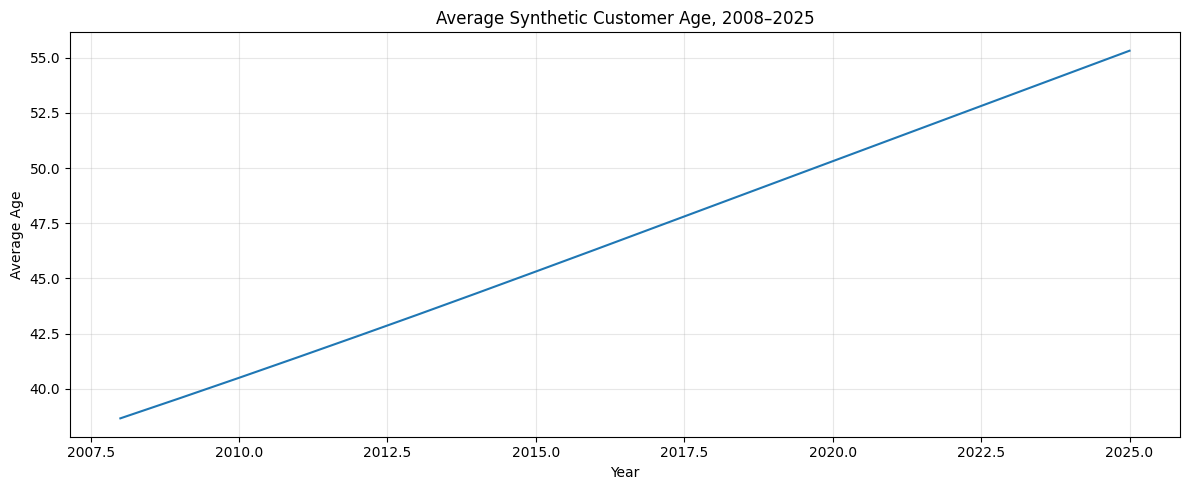

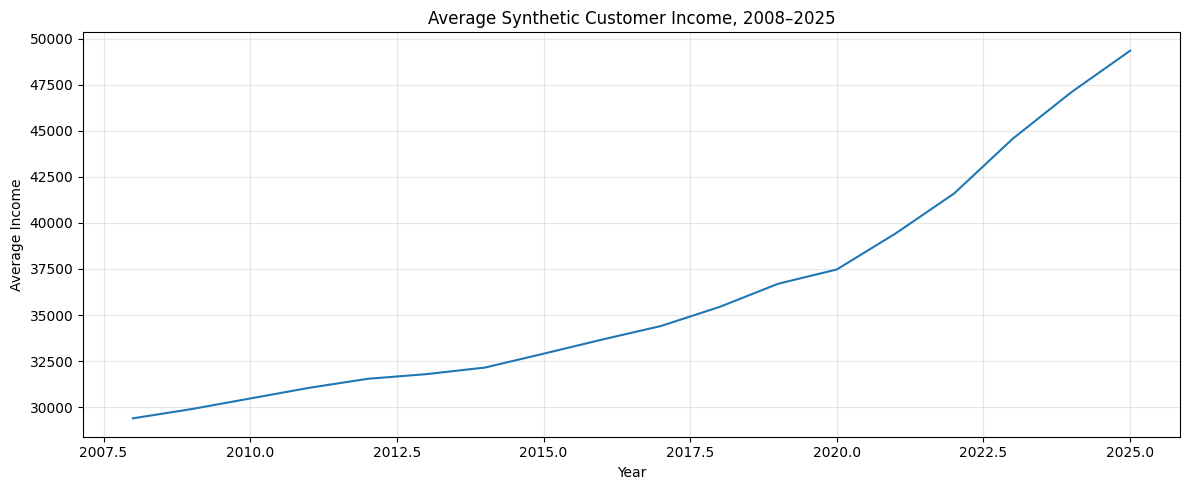

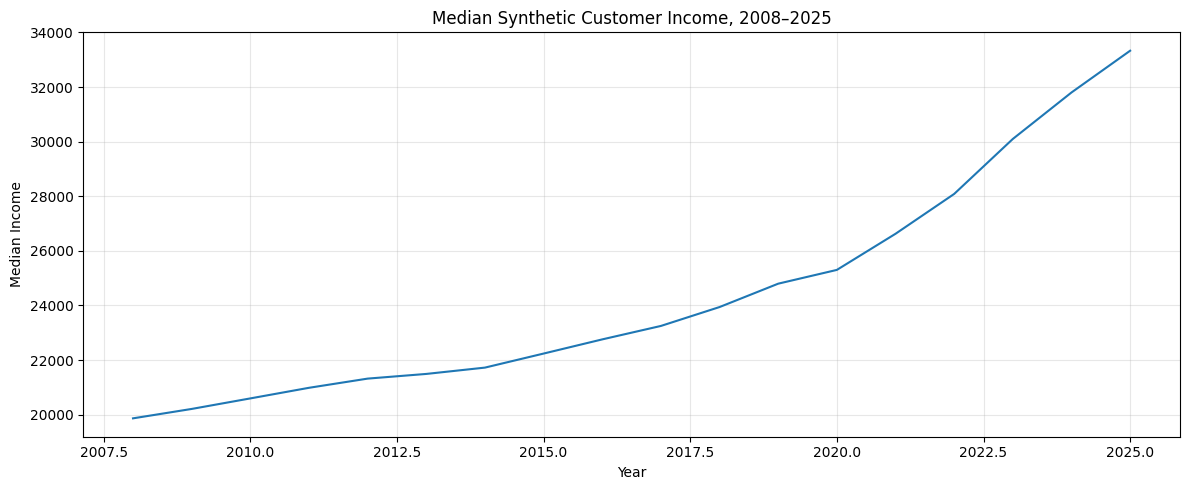

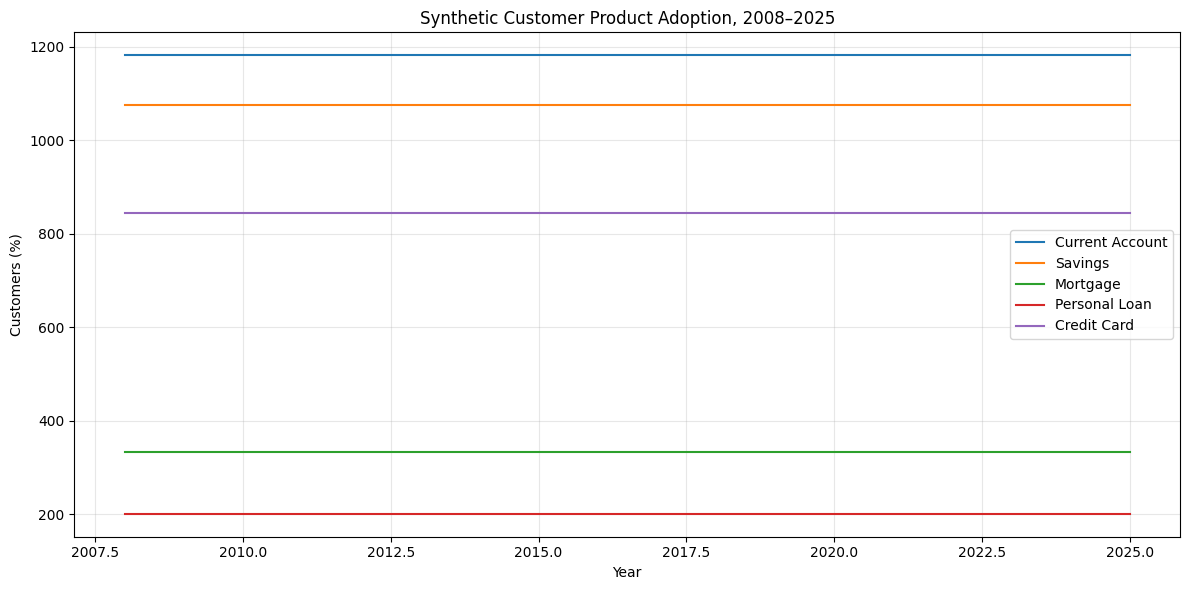

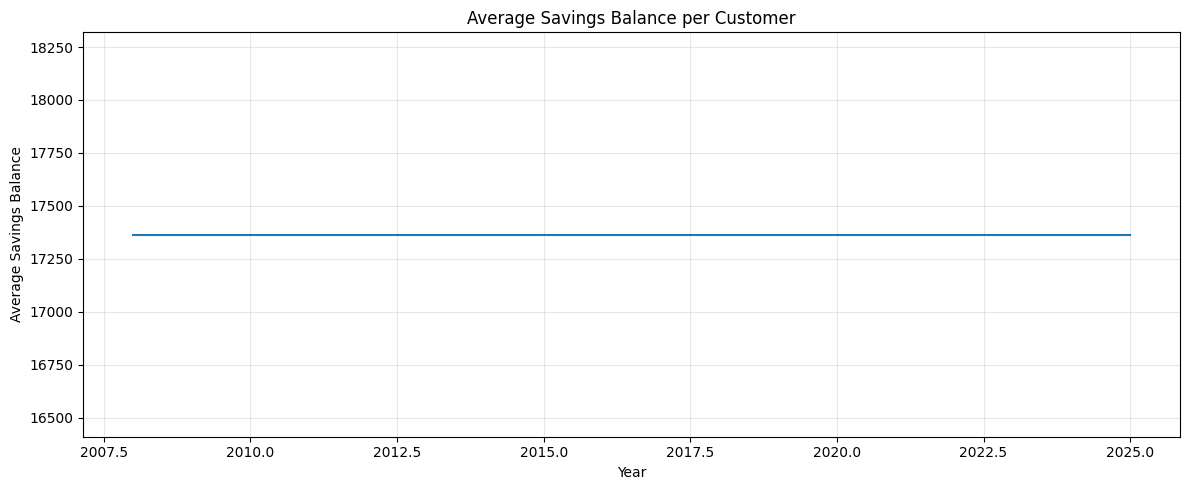

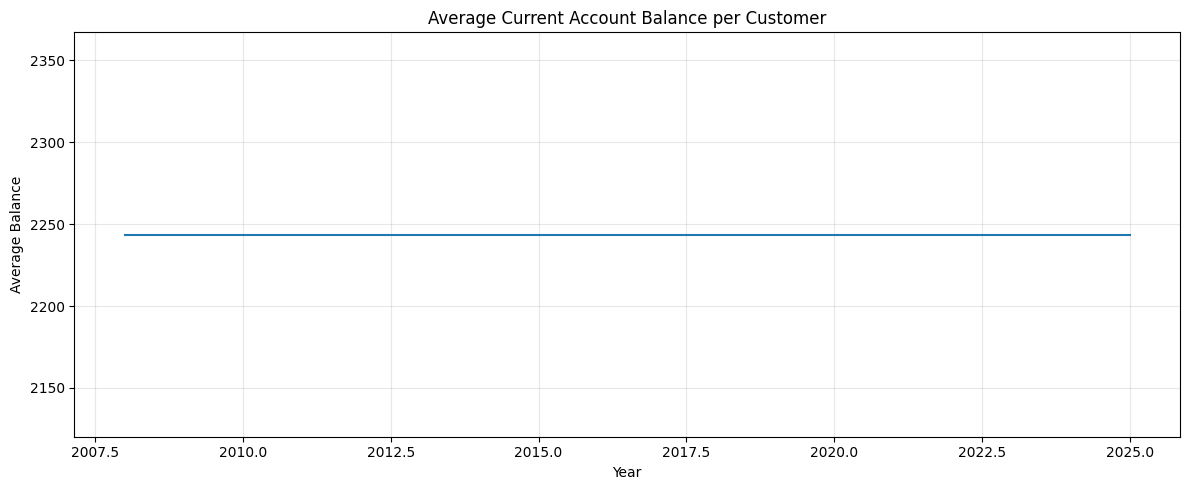

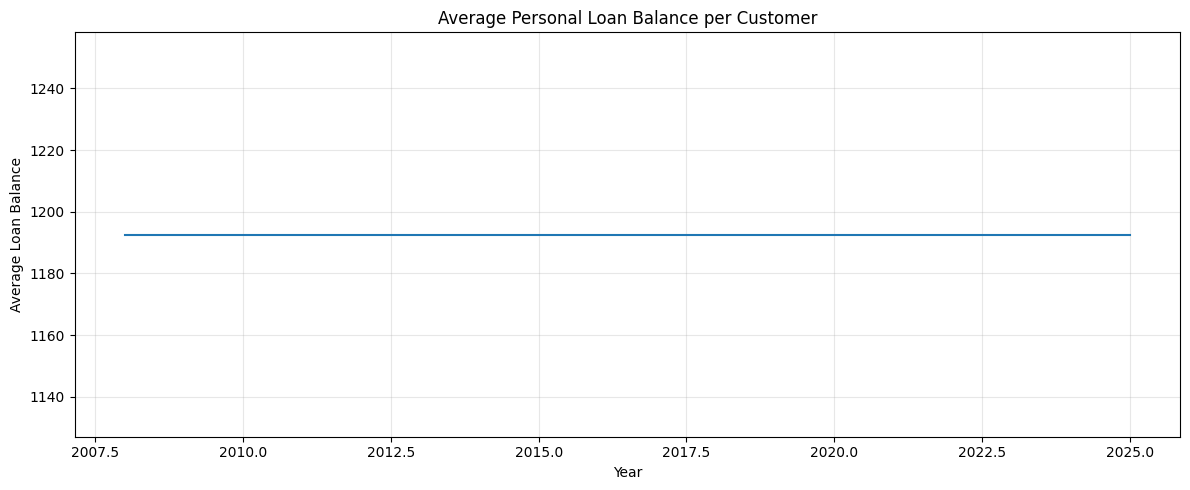

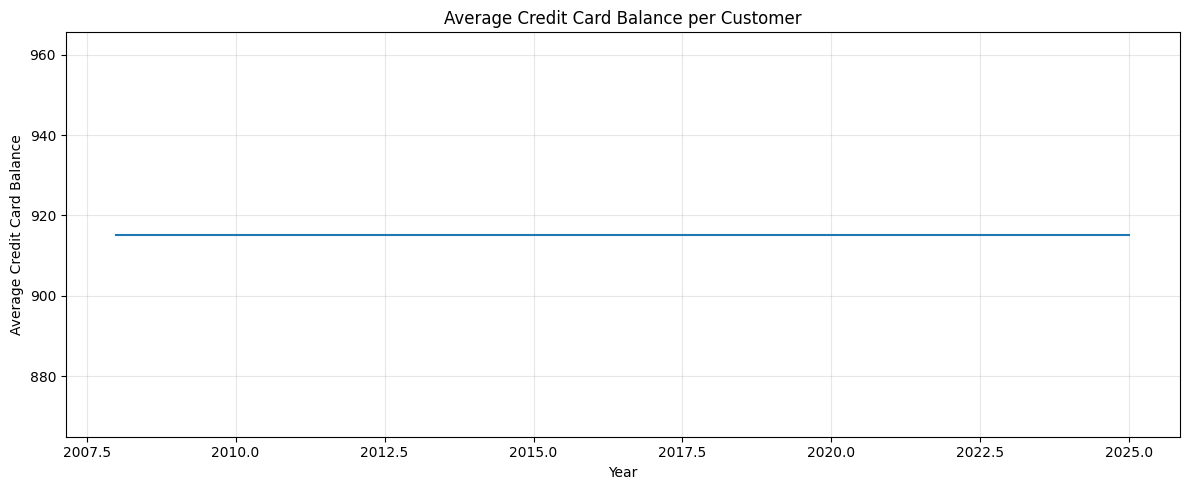

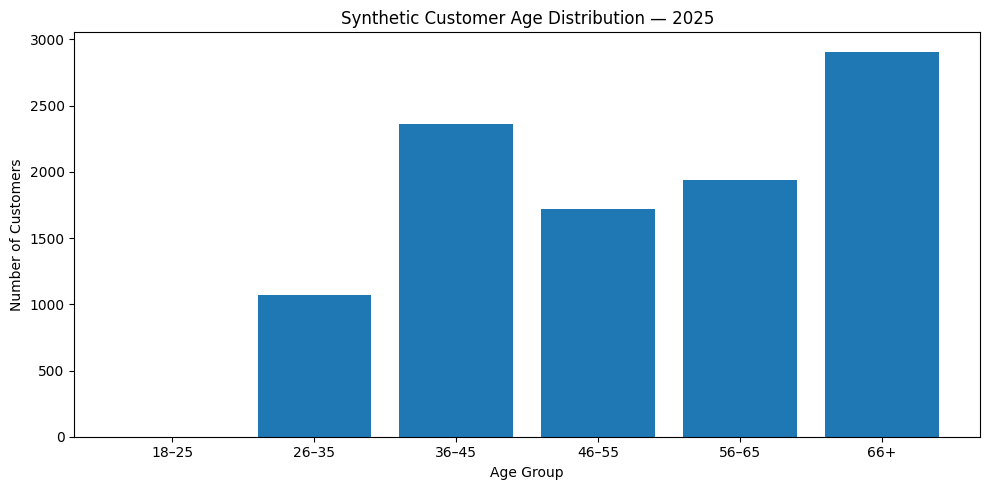

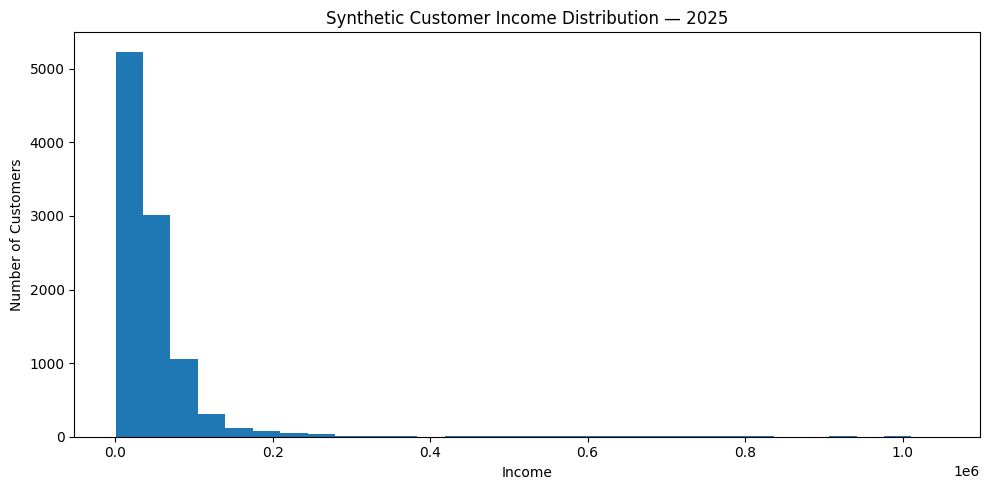


CUSTOMER EVOLUTION VISUALISATIONS COMPLETE

Dashboard data saved:
c:\Users\Charlie\Downloads\DS_prject\msc-dsr-projects-group-12\synthetic_bank\synthetic_bank_outputs\CUSTOMER_EVOLUTION_DASHBOARD_DATA.csv


In [237]:
# ============================================================
# CELL 120 — CUSTOMER EVOLUTION VISUALISATIONS
# ============================================================

import matplotlib.pyplot as plt

print("=" * 70)
print("CELL 120 — CUSTOMER EVOLUTION VISUALISATIONS")
print("=" * 70)

# ============================================================
# 1. AVERAGE AGE OVER TIME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution["Average_Age"]
)

plt.title(
    "Average Synthetic Customer Age, 2008–2025"
)

plt.xlabel("Year")
plt.ylabel("Average Age")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 2. AVERAGE INCOME OVER TIME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution["Average_Income"]
)

plt.title(
    "Average Synthetic Customer Income, 2008–2025"
)

plt.xlabel("Year")
plt.ylabel("Average Income")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 3. MEDIAN INCOME OVER TIME
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution["Median_Income"]
)

plt.title(
    "Median Synthetic Customer Income, 2008–2025"
)

plt.xlabel("Year")
plt.ylabel("Median Income")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 4. PRODUCT ADOPTION
# ============================================================

plt.figure(figsize=(12, 6))

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Current_Account_Adoption_Pct"
    ],
    label="Current Account"
)

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Savings_Adoption_Pct"
    ],
    label="Savings"
)

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Mortgage_Adoption_Pct"
    ],
    label="Mortgage"
)

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Personal_Loan_Adoption_Pct"
    ],
    label="Personal Loan"
)

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Credit_Card_Adoption_Pct"
    ],
    label="Credit Card"
)

plt.title(
    "Synthetic Customer Product Adoption, 2008–2025"
)

plt.xlabel("Year")
plt.ylabel("Customers (%)")

plt.legend()

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 5. AVERAGE SAVINGS BALANCE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Average_Savings_Balance"
    ]
)

plt.title(
    "Average Savings Balance per Customer"
)

plt.xlabel("Year")
plt.ylabel("Average Savings Balance")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 6. AVERAGE CURRENT ACCOUNT BALANCE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Average_Current_Account_Balance"
    ]
)

plt.title(
    "Average Current Account Balance per Customer"
)

plt.xlabel("Year")
plt.ylabel("Average Balance")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 7. AVERAGE PERSONAL LOAN BALANCE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Average_Personal_Loan_Balance"
    ]
)

plt.title(
    "Average Personal Loan Balance per Customer"
)

plt.xlabel("Year")
plt.ylabel("Average Loan Balance")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 8. AVERAGE CREDIT CARD BALANCE
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    annual_customer_evolution["Year"],
    annual_customer_evolution[
        "Average_Credit_Card_Balance"
    ]
)

plt.title(
    "Average Credit Card Balance per Customer"
)

plt.xlabel("Year")
plt.ylabel("Average Credit Card Balance")

plt.grid(True, alpha=0.3)

plt.tight_layout()

plt.show()


# ============================================================
# 9. AGE GROUP DISTRIBUTION — 2025
# ============================================================

age_2025 = customer_evolution[
    customer_evolution["Date"]
    == customer_evolution["Date"].max()
].copy()

age_distribution = (
    age_2025[
        "Age_Group"
    ]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

plt.bar(
    age_distribution.index.astype(str),
    age_distribution.values
)

plt.title(
    "Synthetic Customer Age Distribution — 2025"
)

plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()


# ============================================================
# 10. INCOME DISTRIBUTION — 2025
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(
    age_2025["Income"],
    bins=30
)

plt.title(
    "Synthetic Customer Income Distribution — 2025"
)

plt.xlabel("Income")
plt.ylabel("Number of Customers")

plt.tight_layout()

plt.show()


# ============================================================
# 11. SAVE CHART DATA
# ============================================================

annual_customer_evolution.to_csv(
    OUTPUT_DIR /
    "CUSTOMER_EVOLUTION_DASHBOARD_DATA.csv",
    index=False
)

print("\n" + "=" * 70)
print("CUSTOMER EVOLUTION VISUALISATIONS COMPLETE")
print("=" * 70)

print(
    "\nDashboard data saved:"
)

print(
    OUTPUT_DIR /
    "CUSTOMER_EVOLUTION_DASHBOARD_DATA.csv"
)